# MMDA Traffic Incident Simulation
### A spatiotemporal Monte Carlo simulation of traffic crashes on EDSA and C5

Group 9 – AM3 · BACALLA, M.D.P. · CASTILLO, C.R.M. · CUEVA, X.L.A

---

**Research question.** Given a road's traffic exposure, how does the expected number of traffic incidents change under simulated increases in traffic volume, and how are those incidents distributed across the hours of the day?

**How to run this.** Runtime → Run all. Every stage prints its own audit trail and renders its figures inline. Nothing in `data/raw/` is ever modified; every correction happens in code, so the answer to *what did you change about the government's data* is this notebook rather than a recollection.

**Where the files live.** Two folders, and the split is the point: `data/` is
read and never written, `results/` is written and can be deleted and rebuilt at
any time.

```
traffic_simulation/
├── MMDA_Traffic_Simulation.ipynb   this notebook — the whole pipeline
├── data/                           the four inputs, never modified
└── results/
    ├── figures/                    fig01 – fig10
    ├── tables/                     model summary, simulation results
    ├── logs/                       a narrative log per stage
    └── processed/                  intermediate tables
```

**The four datasets.**

| Dataset | Coverage | Role |
| --- | --- | --- |
| NCTS/MMDA AADT | 2014–2025, annual | Exposure denominator |
| MMDA incident feed | Aug 2018 – Dec 2020 | Outcome counts and within-year timing |
| PSA road crashes | 2013–2024, annual | External validation only, never used in estimation |
| EDSA violations | 2014–2018, annual | Descriptive context only |


## Step 0 — Environment and data

Upload `traffic_simulation.zip` when prompted, or set `PROJECT_DIR` yourself if the project is already on the runtime or in Drive. The cell is written so that re-running it after the data is in place is harmless.

In [1]:
import sys, os, zipfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# Point this at the project folder. The default works both for a Colab upload
# and for a local Jupyter session started inside the project.
PROJECT_DIR = Path("/content/traffic_simulation_complete") if IN_COLAB else Path.cwd()

if IN_COLAB and not (PROJECT_DIR / "data").exists():
    from google.colab import files
    print("Upload traffic_simulation.zip")
    up = files.upload()
    name = next(iter(up))
    with zipfile.ZipFile(name) as z:
        z.extractall("/content")

assert (PROJECT_DIR / "data").exists(), (
    f"No data/ folder under {PROJECT_DIR}. Set PROJECT_DIR to the project folder."
)
print("Project:", PROJECT_DIR)
print("Input files:", len(list((PROJECT_DIR / 'data').glob('*.csv'))))


Project: C:\Users\mearv\Documents\CSS142
Input files: 4


### Check the inputs before anything else

Four files are required in `data/`. They ship with this project, so this cell should pass immediately; it exists so that a missing input fails here with a clear message rather than three stages later with a `FileNotFoundError`.

The sources publish these under different names — the incident data arrives as `data_mmda_traffic_spatial.csv` inside an archive, and the PSA figures arrive as a spreadsheet rather than a CSV. The appendix at the end of this notebook rebuilds `data/` from the original downloads if you ever need to.

In [2]:
EXPECTED = {
    'AADT_2014_2025_combined.csv': 'exposure denominator',
    'mmda_incidents.csv':          'outcome counts and timing',
    'edsa_violations.csv':         'descriptive context only',
    'psa_crashes.csv':             'external validation only',
}

raw = PROJECT_DIR / 'data'
missing = [f for f in EXPECTED if not (raw / f).exists()]

for f, role in EXPECTED.items():
    p = raw / f
    mark = 'OK     ' if p.exists() else 'MISSING'
    size = f'{p.stat().st_size:>10,} bytes' if p.exists() else ' ' * 16
    print(f'  [{mark}] {f:<32} {size}   {role}')

assert not missing, (
    f'{len(missing)} input(s) absent from {raw}: {missing}. '
    'See the appendix at the end of this notebook to rebuild them.'
)
print('\nAll four inputs present.')


  [OK     ] AADT_2014_2025_combined.csv          17,769 bytes   exposure denominator
  [OK     ] mmda_incidents.csv                5,260,334 bytes   outcome counts and timing
  [OK     ] edsa_violations.csv                   1,064 bytes   descriptive context only
  [OK     ] psa_crashes.csv                         378 bytes   external validation only

All four inputs present.


In [3]:
# statsmodels and the rest ship with Colab; this is a no-op there.
try:
    import statsmodels.api as sm
except ImportError:
    !pip install statsmodels -q
    import statsmodels.api as sm

import pandas as pd, numpy as np, matplotlib, json, re, argparse
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

print(f"pandas {pd.__version__} · numpy {np.__version__} · "
      f"statsmodels {sm.__version__} · matplotlib {matplotlib.__version__}")


pandas 3.0.3 · numpy 2.4.6 · statsmodels 0.15.0 · matplotlib 3.11.0


## Step 1 — Configuration

Every structural fact about the data lives here and nowhere else: road codes, the analysis window, the classification patterns, and the five documented structural breaks. If a road code or a year boundary appears anywhere else in this notebook, it belongs here instead.

**This is the cell to show a panelist who asks how the 2017 vehicle reclassification or the 2018 C5 redefinition was handled.**

In [4]:
from pathlib import Path

class cfg:
    # ---------------------------------------------------------------------------
    # Paths
    # ---------------------------------------------------------------------------

    ROOT = PROJECT_DIR
    # Two folders, and the split is meaningful: data/ holds the four inputs and is
    # never written to, results/ holds everything generated and can be deleted and
    # rebuilt at any time. Intermediate tables are generated, so they live under
    # results/ rather than alongside the inputs where they could be mistaken for them.
    RAW = ROOT / "data"
    RESULTS = ROOT / "results"
    PROCESSED = RESULTS / "processed"
    FIGURES = RESULTS / "figures"
    TABLES = RESULTS / "tables"
    LOGS = RESULTS / "logs"


    # Raw file names. All four datasets are present as of 2026-09-19.
    AADT_FILE = RAW / "AADT_2014_2025_combined.csv"
    INCIDENTS_FILE = RAW / "mmda_incidents.csv"      # Aug 2018 - Dec 2020, 17,312 rows
    VIOLATIONS_FILE = RAW / "edsa_violations.csv"    # 2014-2018, annual totals
    PSA_CRASHES_FILE = RAW / "psa_crashes.csv"       # 2013-2024, Metro Manila annual

    # ---------------------------------------------------------------------------
    # Study design
    # ---------------------------------------------------------------------------

    # The two roads the study is about.
    FOCAL_ROADS = {
        "C:4": "EDSA",
        "C:5": "C5",
    }

    # Years in which BOTH an outcome (incidents) and an exposure (AADT) exist.
    # Nominally three, but see ESTIMATION_WINDOW below: only 18 months are usable.
    MODEL_YEARS = [2018, 2019, 2020]

    # ---------------------------------------------------------------------------
    # BREAK 5 — Incident coverage gaps. Discovered 2026-09-19 from the raw file.
    # ---------------------------------------------------------------------------
    #   The MMDA feed is scraped from Twitter, so absence of a tweet is not absence
    #   of a crash. Monthly row counts:
    #
    #     2018-08:  319   <- partial, series begins on the 20th
    #     2018-09 .. 2020-02:  612-1101 per month, no gaps        <- USABLE
    #     2020-03:  292   <- ECQ lockdown begins 15 March 2020
    #     2020-04:   11
    #     2020-05:   75
    #     2020-06:   69
    #     2020-07:    0   <- NO ROWS AT ALL. Collection gap, not a real zero.
    #     2020-08:    0   <- NO ROWS AT ALL.
    #     2020-09:  242   <- feed resumes
    #     2020-10:  431
    #     2020-11:  292
    #     2020-12:  222
    #
    #   CONSEQUENCE: calendar-year 2020 cannot be used to estimate a rate. A
    #   lockdown demand collapse and a two-month reporting outage are confounded
    #   and cannot be separated. Any 2020 annual figure understates the truth by an
    #   unknown amount. 2018 is a partial year for the same structural reason.
    #
    #   RESOLUTION: estimate on complete months only.
    ESTIMATION_WINDOW = ("2018-09", "2020-02")   # 18 consecutive complete months
    INCIDENT_COVERAGE_GAP_MONTHS = ["2020-07", "2020-08"]
    INCIDENT_PARTIAL_MONTHS = ["2018-08"]        # series starts mid-month
    LOCKDOWN_START = "2020-03-15"                # ECQ, Metro Manila

    # Months excluded from estimation but retained for descriptive/scenario use.
    DISRUPTION_WINDOW = ("2020-03", "2020-12")

    # ---------------------------------------------------------------------------
    # Incident classification
    # ---------------------------------------------------------------------------
    #   The raw Type column is free text lifted from tweet bodies: 493 distinct
    #   values, 339 of which occur exactly once. It is NOT a crash indicator.
    #   Of 17,312 rows only 12,787 describe a collision; 3,956 are stalled vehicles
    #   and 569 are road works, rallies, vehicle fires and similar.
    #
    #   Treating the file as an accident file inflates counts by roughly 35%.
    INCIDENT_CLASS_PATTERNS = {
        "CRASH":      r"ACCIDENT|COLLISION|HIT AND RUN|SIDESWIPE|BUMP|OVERTURN",
        "STALL":      r"STALL",
        "ROADWORK":   r"DPWH|REBLOCK|PATCHING|ASPHALT|LANE MARKING|MAYNILAD|EXCAVAT",
        "OBSTRUCTION": r"RALLY|RALLYIST|ROAD CLOSURE|FLOOD|FIRE|SHOOTING|DEBRIS",
    }
    INCIDENT_CLASS_DEFAULT = "OTHER"

    # Only this class is modelled as an outcome.
    MODELLED_CLASS = "CRASH"

    # ---------------------------------------------------------------------------
    # Corridor tagging
    # ---------------------------------------------------------------------------
    #   Location is free text ("EDSA SHAW TUNNEL", "C5 LANUZA"). Word-boundary
    #   matching gives 8,454 EDSA rows and 2,689 C5 rows with ZERO overlap, which
    #   is the property that makes the two corridors comparable.
    CORRIDOR_PATTERNS = {
        "EDSA": r"\bEDSA\b",
        "C5":   r"\bC-?5\b",
    }
    CORRIDOR_DEFAULT = "OTHER"

    # ---------------------------------------------------------------------------
    # Incident-file data defects (all repaired in 03_incident_analysis.py)
    # ---------------------------------------------------------------------------
    # D1  55 rows carry coordinates (0, 0) — "null island". Dropped from spatial
    #     analysis, retained for counts.
    # D2  City is mojibake: "ParaÃ±aque" (107 rows) and "Parañaque" (4) are the
    #     same city, UTF-8 decoded as latin-1. Repaired.
    # D3  16 rows duplicate a tweet URL; 273 duplicate Date+Time+Location+Type.
    #     These are MMDA re-posts of a single incident, not separate incidents.
    # D4  219 Time values do not parse: some blank, some written "3:20PM" with no
    #     space before the meridiem.
    # D5  687 rows have no Lanes_Blocked; 857 have no Direction, and Direction
    #     additionally contains junk ("PAX", "DAR", "CLOSED", "CLARA").
    METRO_MANILA_BBOX = {"lat": (14.30, 14.80), "lon": (120.85, 121.20)}
    MOJIBAKE_REPAIRS = {"ParaÃ±aque": "Parañaque", "Kalookan City": "Caloocan City"}
    VALID_DIRECTIONS = ["NB", "SB", "EB", "WB"]

    # The year whose AADT is used as the simulation baseline.
    BASELINE_YEAR = 2025

    # Scenario multipliers on baseline exposure.
    SCENARIOS = {
        "baseline": 0.00,
        "plus_10": 0.10,
        "plus_20": 0.20,
        "plus_30": 0.30,
    }

    N_SIMULATIONS = 1000
    RANDOM_SEED = 20260919

    # ---------------------------------------------------------------------------
    # Known structural breaks in the AADT series
    # ---------------------------------------------------------------------------
    # These are documented findings from the data audit, not guesses. Each one
    # restricts what may legitimately be claimed. The preprocessing script enforces
    # them; the paper must cite them as limitations.

    # BREAK 1 — Vehicle reclassification, effective 2017.
    #   UV and TAXI are blank for 2014-2016 and present from 2017 onward. These are
    #   NOT zeros: the survey changed its vehicle taxonomy. Network-wide, CAR falls
    #   by 218,566 between 2016 and 2017 while UV+TAXI appear totalling 233,605.
    #   On EDSA: CAR falls 31,130, UV+TAXI arrive at 27,251.
    #
    #   CONSEQUENCE: total volume is comparable across all 12 years; vehicle
    #   COMPOSITION is comparable only within 2014-2016 and within 2017-2025.
    VEHICLE_RECLASS_YEAR = 2017
    COMPOSITION_ERA_OLD = list(range(2014, 2017))   # 2014, 2015, 2016
    COMPOSITION_ERA_NEW = list(range(2017, 2026))   # 2017 .. 2025

    # BREAK 2 — C5 segment redefinition, effective 2018.
    #   2014-2017 label: "KATIPUNAN / C.P. GARCIA"
    #   2018-2025 label: "C.P. GARCIA / KATIPUNAN / TANDANG SORA"
    #   Tandang Sora was ADDED. C5 AADT rises 218,751 -> 235,744 (+7.8%) across
    #   this boundary; an unknown share of that is the new segment, not new traffic.
    #
    #   CONSEQUENCE: never report a C5 growth rate spanning 2017->2018.
    C5_REDEFINITION_YEAR = 2018

    # BREAK 3 — COVID-19 disruption.
    #   EDSA AADT falls 405,882 (2019) -> 328,114 (2020), and PSA Metro Manila
    #   crashes fall 121,771 -> 65,032 over the same period. One of the three
    #   model years is a lockdown year and must be flagged in the regression.
    COVID_YEARS = [2020, 2021]

    # BREAK 4 — 2016 class-breakdown reconciliation failure.
    #   For 11 of 20 roads in 2016, the vehicle classes do not sum to the stated
    #   TOTAL (worst: A. BONIFACIO, off by 16,341). The year's network total still
    #   reconciles exactly. EDSA and C5 are NOT affected.
    #
    #   CONSEQUENCE: for 2016, trust the TOTAL column, not the class breakdown,
    #   for the affected roads.
    CLASS_RECONCILIATION_SUSPECT_YEARS = [2016]

    # ---------------------------------------------------------------------------
    # Data cleaning rules
    # ---------------------------------------------------------------------------

    # Rows with this Code are network aggregates, not roads. Dropping them is the
    # single most important cleaning step: leaving them in double-counts every
    # network total and turns 20 roads into 21.
    AGGREGATE_CODE = "TOTAL"

    # Roads that appear in the file with no Code assigned. Any code-based filter
    # silently drops them unless they are repaired first.
    MISSING_CODE_REPAIR = {
        "MARCOS HWY.": "R:11",
        "MARCOS HIGHWAY": "R:11",
        "MCARTHUR HWY.": "R:12",
        "MCARTHUR HIGHWAY": "R:12",
    }

    # The same road is spelled several ways across years. ALWAYS join on Code,
    # never on Road. This map exists so that reports read consistently.
    ROAD_NAME_CANONICAL = {
        "EDSA (BUENDIA AVE.)": "EDSA",
        "EDSA (BUENDIA AVE)": "EDSA",
        "EDSA": "EDSA",
        "KATIPUNAN / C.P. GARCIA": "C5",
        "C.P. GARCIA / KATIPUNAN / TANDANG SORA": "C5",
        "PRES. QUIRINO": "PRES. QUIRINO AVE.",
        "PRES QUIRINO AVE.": "PRES. QUIRINO AVE.",
        "PRES. QUIRINO AVE.": "PRES. QUIRINO AVE.",
        "MARCOS HWY.": "MARCOS HIGHWAY",
        "MCARTHUR HWY.": "MCARTHUR HIGHWAY",
    }

    VEHICLE_CLASSES = [
        "CAR", "PUJ", "UV", "TAXI", "PUB",
        "TRUCK", "TRAILER", "MC", "TRICYCLE",
    ]

    # Classes that exist in every year 2014-2025 and are therefore safe to trend
    # across the full period.
    VEHICLE_CLASSES_STABLE = [
        "CAR", "PUJ", "PUB", "TRUCK", "TRAILER", "MC", "TRICYCLE",
    ]

    # Classes introduced by the 2017 reclassification.
    VEHICLE_CLASSES_POST_2017_ONLY = ["UV", "TAXI"]

    # Tolerance when checking that vehicle classes sum to the stated TOTAL.
    RECONCILIATION_TOLERANCE = 1

    DAYS_PER_YEAR = 365
    RATE_PER = 100_000  # incidents per 100,000 vehicle passages

for _d in (cfg.PROCESSED, cfg.FIGURES, cfg.TABLES, cfg.LOGS):
    _d.mkdir(parents=True, exist_ok=True)

print('Config loaded. Estimation window:', cfg.ESTIMATION_WINDOW)
print('Focal roads:', cfg.FOCAL_ROADS)


Config loaded. Estimation window: ('2018-09', '2020-02')
Focal roads: {'C:4': 'EDSA', 'C:5': 'C5'}


## Step 2 — Preprocess AADT into exposure

Turns twelve years of annual traffic counts into the exposure denominator every later figure divides by. Six structural defects in the AADT file are detected and handled here, two of which would otherwise have produced wrong numbers without announcing themselves. The script fails loudly rather than silently imputing.

**Outputs**

```
Run:  python 01_preprocessing.py
Out:  data/processed/aadt_clean.csv
      data/processed/aadt_network_totals.csv
      data/processed/exposure_focal.csv
      results/logs/preprocessing_log.txt
```

In [5]:
import sys
from datetime import datetime

import pandas as pd
import numpy as np

# 00_config.py starts with a digit, so it cannot be imported by name.


# ---------------------------------------------------------------------------
# Logging
# ---------------------------------------------------------------------------

class Log:
    """Writes to stdout and to results/logs/preprocessing_log.txt at once."""

    def __init__(self, path):
        self.path = path
        self.lines = []
        self.warnings = 0

    def __call__(self, msg=""):
        print(msg)
        self.lines.append(str(msg))

    def section(self, title):
        self("")
        self("=" * 72)
        self(title)
        self("=" * 72)

    def warn(self, msg):
        self.warnings += 1
        self(f"  [WARN] {msg}")

    def ok(self, msg):
        self(f"  [OK]   {msg}")

    def save(self):
        header = [
            "MMDA Traffic Incident Simulation — preprocessing log",
            f"Generated: {datetime.now():%Y-%m-%d %H:%M:%S}",
            "",
        ]
        self.path.write_text("\n".join(header + self.lines), encoding="utf-8")


log = Log(cfg.LOGS / "preprocessing_log.txt")


# ---------------------------------------------------------------------------
# AADT
# ---------------------------------------------------------------------------

def load_aadt():
    """Read the raw AADT file and report its shape before anything is changed."""
    log.section("STEP 1 — Load raw AADT")

    if not cfg.AADT_FILE.exists():
        raise FileNotFoundError(f"AADT file not found: {cfg.AADT_FILE}")

    df = pd.read_csv(cfg.AADT_FILE)
    log(f"  Loaded {cfg.AADT_FILE.name}")
    log(f"  Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    log(f"  Years: {int(df.Year.min())}–{int(df.Year.max())}")
    log(f"  Rows per year: {sorted(df.Year.value_counts().unique().tolist())}")
    return df


def separate_aggregate_rows(df):
    """
    Split the network TOTAL rows away from the road rows.

    DEFECT 1. Each year carries a Code == 'TOTAL' row sitting among the road
    rows. Summing the file without removing it double-counts every network
    figure and makes 20 roads look like 21. The row is genuinely useful as a
    Metro Manila-wide exposure denominator, so it is kept — in its own table.
    """
    log.section("STEP 2 — Separate network aggregate rows (DEFECT 1)")

    is_total = df["Code"] == cfg.AGGREGATE_CODE
    totals = df[is_total].copy()
    roads = df[~is_total].copy()

    log(f"  Aggregate rows removed from road table: {len(totals)}")
    log(f"  Road rows retained: {len(roads)}")

    per_year = roads.groupby("Year").size()
    if per_year.nunique() != 1:
        log.warn(f"Uneven road counts per year: {per_year.to_dict()}")
    else:
        log.ok(f"Consistent {per_year.iloc[0]} roads per year")

    totals = totals.drop(columns=["Code", "Road"])
    return roads, totals


def repair_missing_codes(df):
    """
    DEFECT 3. Marcos Hwy and McArthur Hwy carry no Code in any year, so any
    code-based filter drops them without saying so. Assign synthetic codes.
    """
    log.section("STEP 3 — Repair missing road codes (DEFECT 3)")

    missing = df["Code"].isna()
    log(f"  Rows with no Code: {missing.sum()}")

    if missing.any():
        names = sorted(df.loc[missing, "Road"].dropna().unique())
        log(f"  Affected roads: {', '.join(names)}")
        for name in names:
            if name not in cfg.MISSING_CODE_REPAIR:
                raise ValueError(
                    f"Uncoded road '{name}' has no entry in "
                    f"cfg.MISSING_CODE_REPAIR. Add one rather than letting it "
                    f"be dropped silently."
                )
        df.loc[missing, "Code"] = df.loc[missing, "Road"].map(cfg.MISSING_CODE_REPAIR)
        log.ok(f"Assigned synthetic codes to {missing.sum()} rows")

    still = df["Code"].isna().sum()
    if still:
        raise ValueError(f"{still} rows still have no Code after repair")
    return df


def canonicalise_names(df):
    """
    DEFECT 4. EDSA appears under three spellings, C5 under two, Pres. Quirino
    under three. Joins must use Code; this map only makes output readable.

    DEFECT 5 is detected here too: the C5 label changes in 2018 because
    Tandang Sora was added to the segment.
    """
    log.section("STEP 4 — Canonicalise road names (DEFECTS 4 and 5)")

    before = df.groupby("Code")["Road"].nunique()
    multi = before[before > 1]
    if len(multi):
        log(f"  Codes with more than one spelling: {len(multi)}")
        for code in multi.index:
            variants = sorted(df.loc[df.Code == code, "Road"].dropna().unique())
            log(f"    {code}: {variants}")

    df["Road_raw"] = df["Road"]
    df["Road"] = df["Road"].map(lambda x: cfg.ROAD_NAME_CANONICAL.get(x, x))

    # DEFECT 5 — flag the C5 redefinition explicitly.
    c5 = df[df.Code == "C:5"]
    labels = c5.groupby("Year")["Road_raw"].first()
    changed = labels[labels != labels.iloc[0]]
    if len(changed):
        first_change = int(changed.index.min())
        log.warn(
            f"C5 segment definition changes at {first_change}: "
            f"'{labels.iloc[0]}' -> '{changed.iloc[0]}'. "
            f"Do not report a C5 growth rate spanning "
            f"{first_change - 1}->{first_change}."
        )

    after = df.groupby("Code")["Road"].nunique()
    log.ok(f"Codes with a single canonical name after mapping: {(after == 1).sum()}/{len(after)}")
    return df


def check_vehicle_reclassification(df):
    """
    DEFECT 2 — the most consequential one.

    UV and TAXI are blank 2014-2016 and present from 2017. These are not zeros:
    the survey split taxis and UVs out of CAR. Verify the signature rather than
    asserting it, then mark each row's composition era so downstream code cannot
    accidentally trend composition across the boundary.
    """
    log.section("STEP 5 — Verify the 2017 vehicle reclassification (DEFECT 2)")

    presence = df.groupby("Year")[cfg.VEHICLE_CLASSES_POST_2017_ONLY].apply(
        lambda g: g.notna().sum()
    )
    log("  Non-null counts for the reclassified columns:")
    for year, row in presence.iterrows():
        log(f"    {int(year)}: UV={int(row['UV']):>3}  TAXI={int(row['TAXI']):>3}")

    y0 = cfg.VEHICLE_RECLASS_YEAR - 1
    y1 = cfg.VEHICLE_RECLASS_YEAR
    car_drop = df.loc[df.Year == y0, "CAR"].sum() - df.loc[df.Year == y1, "CAR"].sum()
    new_classes = df.loc[df.Year == y1, cfg.VEHICLE_CLASSES_POST_2017_ONLY].sum().sum()

    log("")
    log(f"  Reclassification signature, {y0} -> {y1}:")
    log(f"    CAR decrease:        {car_drop:>12,.0f}")
    log(f"    UV + TAXI appearing: {new_classes:>12,.0f}")
    log(f"    Unexplained residual:{car_drop - new_classes:>12,.0f}")

    if new_classes > 0 and abs(car_drop - new_classes) / new_classes < 0.25:
        log.ok(
            "Signature confirmed: the CAR decrease is accounted for by the "
            "classes split out of it. This is a coding change, not a change "
            "in traffic."
        )
    else:
        log.warn(
            "Reclassification signature is weaker than expected. Inspect "
            "before claiming the CAR decrease is an artifact."
        )

    df["composition_era"] = np.where(
        df.Year < cfg.VEHICLE_RECLASS_YEAR, "pre_2017", "post_2017"
    )
    log("")
    log("  RULE ENFORCED: total volume is comparable across all years;")
    log("  vehicle composition is comparable only WITHIN an era.")
    return df


def check_reconciliation(df):
    """
    DEFECT 6. Check that the vehicle classes sum to the stated TOTAL, row by
    row. Report every failure. Critically, check whether the focal roads are
    affected, since that decides whether the defect touches the study at all.
    """
    log.section("STEP 6 — Reconcile vehicle classes against TOTAL (DEFECT 6)")

    calc = df[cfg.VEHICLE_CLASSES].fillna(0).sum(axis=1)
    df["total_calculated"] = calc
    df["total_delta"] = df["TOTAL"] - calc

    bad = df[df["total_delta"].abs() > cfg.RECONCILIATION_TOLERANCE]
    log(f"  Rows failing reconciliation: {len(bad)} of {len(df)}")

    if len(bad):
        by_year = bad.groupby("Year").size()
        log("  By year:")
        for year, n in by_year.items():
            worst = bad[bad.Year == year]["total_delta"].abs().max()
            log(f"    {int(year)}: {n:>2} rows, largest discrepancy {worst:>10,.0f}")

        focal_bad = bad[bad.Code.isin(cfg.FOCAL_ROADS)]
        if len(focal_bad):
            log.warn(
                f"{len(focal_bad)} reconciliation failures on a FOCAL road. "
                f"These affect the study directly and must be resolved."
            )
            for _, r in focal_bad.iterrows():
                log(f"      {int(r.Year)} {r.Code} {r.Road}: delta {r.total_delta:,.0f}")
        else:
            log.ok(
                "No focal road (EDSA, C5) fails reconciliation in any year. "
                "The defect does not touch the study's exposure series."
            )

    df["total_reconciles"] = df["total_delta"].abs() <= cfg.RECONCILIATION_TOLERANCE
    return df


def build_exposure(df):
    """
    Build the exposure table for the focal roads. Exposure is the denominator
    of every rate in the model: annual vehicle passages, AADT x 365.
    """
    log.section("STEP 7 — Build focal-road exposure table")

    focal = df[df.Code.isin(cfg.FOCAL_ROADS)].copy()
    focal["road_label"] = focal["Code"].map(cfg.FOCAL_ROADS)
    focal["exposure"] = focal["TOTAL"] * cfg.DAYS_PER_YEAR
    focal["is_covid_year"] = focal["Year"].isin(cfg.COVID_YEARS)
    focal["in_model_window"] = focal["Year"].isin(cfg.MODEL_YEARS)

    out = focal[[
        "Year", "Code", "road_label", "TOTAL", "exposure",
        "is_covid_year", "in_model_window", "composition_era",
    ]].rename(columns={"TOTAL": "aadt"}).sort_values(["road_label", "Year"])

    log(f"  Focal road-years: {len(out)}")
    log(f"  Rows inside the model window ({cfg.MODEL_YEARS}): {out.in_model_window.sum()}")
    log("")
    log("  Exposure series (annual vehicle passages):")
    log(f"    {'Year':<6}{'EDSA AADT':>12}{'EDSA exposure':>18}{'C5 AADT':>12}{'C5 exposure':>18}")
    for year in sorted(out.Year.unique()):
        e = out[(out.Year == year) & (out.road_label == "EDSA")]
        c = out[(out.Year == year) & (out.road_label == "C5")]
        ea = int(e.aadt.iloc[0]) if len(e) else 0
        ee = int(e.exposure.iloc[0]) if len(e) else 0
        ca = int(c.aadt.iloc[0]) if len(c) else 0
        ce = int(c.exposure.iloc[0]) if len(c) else 0
        mark = " *" if year in cfg.MODEL_YEARS else ""
        log(f"    {int(year):<6}{ea:>12,}{ee:>18,}{ca:>12,}{ce:>18,}{mark}")
    log("    (* = year with both incident and exposure data)")
    return out


def report_baseline(exposure):
    """Print the 2025 simulation baseline and its scenario multipliers."""
    log.section("STEP 8 — Simulation baseline")

    base = exposure[exposure.Year == cfg.BASELINE_YEAR]
    log(f"  Baseline year: {cfg.BASELINE_YEAR}")
    for _, r in base.iterrows():
        log(f"    {r.road_label}: AADT {int(r.aadt):,}  exposure {int(r.exposure):,}/yr")

    log("")
    log("  Scenario exposures (what-if, NOT forecasts):")
    log(f"    {'Scenario':<12}{'EDSA AADT':>14}{'C5 AADT':>14}")
    for name, r in cfg.SCENARIOS.items():
        e = base[base.road_label == "EDSA"].aadt.iloc[0] * (1 + r)
        c = base[base.road_label == "C5"].aadt.iloc[0] * (1 + r)
        log(f"    {name:<12}{e:>14,.0f}{c:>14,.0f}")


# ---------------------------------------------------------------------------
# Datasets not yet uploaded
# ---------------------------------------------------------------------------

def preprocess_incidents():
    """
    MMDA incident data, Aug 2018 - Dec 2020, ~17,312 rows.

    NOT YET UPLOADED. The logic below is written against the structure the
    research plan describes and must be validated against the real file before
    it is trusted.

    The essential step is that 17,312 records are NOT 17,312 accidents. The file
    mixes VEHICULAR ACCIDENT and MULTIPLE COLLISION with STALLED BUS/CAR/TRUCK
    and road works. Reporting the raw count as accidents overstates the outcome
    by a large and unknown factor, and is the kind of error a panel catches.
    """
    log.section("STEP 9 — MMDA incidents")

    if not cfg.INCIDENTS_FILE.exists():
        log.warn(f"Not found: {cfg.INCIDENTS_FILE.name}")
        log("  BLOCKED. This file gates steps 4-6 of the pipeline (model and")
        log("  simulation). It is the single highest-priority upload.")
        log("")
        log("  When it arrives, this step will:")
        log("    - parse timestamps, derive year/month/weekday/hour")
        log("    - classify event_type into ACCIDENT / STALLED_VEHICLE /")
        log("      ROAD_WORK / OTHER, and set is_accident")
        log("    - filter to EDSA and C5 by road name and coordinates")
        log("    - emit the empirical hour-of-day and segment distributions")
        log("      that give the simulation its spatiotemporal layer")
        return None

    df = pd.read_csv(cfg.INCIDENTS_FILE)
    log(f"  Loaded {len(df):,} records")
    log.warn("Validate the classification rules against the real column names.")
    return df


def preprocess_violations():
    """EDSA violations 2014-2018. Descriptive context only: no timestamps,
    no incident linkage, therefore no causal claim."""
    log.section("STEP 10 — EDSA violations")
    if not cfg.VIOLATIONS_FILE.exists():
        log.warn(f"Not found: {cfg.VIOLATIONS_FILE.name}")
        log("  Lower priority. Descriptive use only — this dataset cannot")
        log("  support a violation-causes-incident claim.")
        return None
    return pd.read_csv(cfg.VIOLATIONS_FILE)


def preprocess_psa():
    """PSA Metro Manila crash totals 2013-2024. External plausibility check on
    the trend, not a model input and not a scaling factor."""
    log.section("STEP 11 — PSA crashes")
    if not cfg.PSA_CRASHES_FILE.exists():
        log.warn(f"Not found: {cfg.PSA_CRASHES_FILE.name}")
        log("  Lower priority. Used to validate that the incident trend moves")
        log("  with Metro Manila overall, especially across 2020.")
        return None
    return pd.read_csv(cfg.PSA_CRASHES_FILE)


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main():
    log("MMDA TRAFFIC INCIDENT SIMULATION — PREPROCESSING")
    log(f"Run: {datetime.now():%Y-%m-%d %H:%M:%S}")

    df = load_aadt()
    roads, totals = separate_aggregate_rows(df)
    roads = repair_missing_codes(roads)
    roads = canonicalise_names(roads)
    roads = check_vehicle_reclassification(roads)
    roads = check_reconciliation(roads)
    exposure = build_exposure(roads)
    report_baseline(exposure)

    preprocess_incidents()
    preprocess_violations()
    preprocess_psa()

    log.section("OUTPUTS")
    outputs = [
        (cfg.PROCESSED / "aadt_clean.csv", roads),
        (cfg.PROCESSED / "aadt_network_totals.csv", totals),
        (cfg.PROCESSED / "exposure_focal.csv", exposure),
    ]
    for path, frame in outputs:
        frame.to_csv(path, index=False)
        log(f"  {path.name:<30} {len(frame):>4} rows")

    log.section("SUMMARY")
    log(f"  Warnings raised: {log.warnings}")
    log("  Warnings are expected. Each one is a documented data defect that")
    log("  belongs in the limitations section of the paper.")
    log("")
    log("  NEXT: upload the MMDA incident file to unblock steps 4-6.")

    log.save()
    print(f"\nLog written to {log.path}")

main()


MMDA TRAFFIC INCIDENT SIMULATION — PREPROCESSING
Run: 2026-10-05 22:53:00

STEP 1 — Load raw AADT
  Loaded AADT_2014_2025_combined.csv
  Shape: 252 rows x 13 columns
  Years: 2014–2025
  Rows per year: [21]

STEP 2 — Separate network aggregate rows (DEFECT 1)
  Aggregate rows removed from road table: 12
  Road rows retained: 240
  [OK]   Consistent 20 roads per year

STEP 3 — Repair missing road codes (DEFECT 3)
  Rows with no Code: 24
  Affected roads: MARCOS HIGHWAY, MARCOS HWY., MCARTHUR HIGHWAY, MCARTHUR HWY.
  [OK]   Assigned synthetic codes to 24 rows

STEP 4 — Canonicalise road names (DEFECTS 4 and 5)
  Codes with more than one spelling: 7
    C:2: ['MENDOZA', 'PRES QUIRINO AVE.', 'PRES. QUIRINO', 'PRES. QUIRINO AVE.']
    C:4: ['EDSA', 'EDSA (BUENDIA AVE)', 'EDSA (BUENDIA AVE.)']
    C:5: ['C.P. GARCIA / KATIPUNAN / TANDANG SORA', 'KATIPUNAN / C.P. GARCIA']
    R:11: ['MARCOS HIGHWAY', 'MARCOS HWY.']
    R:12: ['MCARTHUR HIGHWAY', 'MCARTHUR HWY.']
    R:6: ['AURORA BLVD.', 'MAG

## Step 3 — Exploratory figures

Exposure trends, the 2017 reclassification break, and the motorcycle share shift from 14% to 46% of EDSA traffic.

**Outputs**

```
Run:  python 02_exploratory_analysis.py
```

In [6]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter



# ---------------------------------------------------------------------------
# Chart styling
# ---------------------------------------------------------------------------
# Categorical palette validated for colour-vision deficiency separation
# (worst adjacent pair dE 9.2 deutan, 27.6 normal). Series are also direct-
# labelled, so identity never rests on colour alone.

C_EDSA = "#2a78d6"   # blue    — categorical slot 1
C_C5 = "#eb6834"     # orange  — categorical slot 2
C_THIRD = "#1baf7a"  # aqua    — categorical slot 3

INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRID,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

THOUSANDS = FuncFormatter(lambda v, _: f"{v:,.0f}")


def style_axes(ax, ygrid=True):
    """Recessive grid and axes: the data carries the ink, not the frame."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(BASELINE)
    ax.spines["bottom"].set_color(BASELINE)
    if ygrid:
        ax.grid(axis="y", linewidth=0.6, alpha=0.9)
        ax.set_axisbelow(True)


# ---------------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------------

def fig_exposure_trend(exposure):
    """
    Change over time, two entities -> a line per entity, direct-labelled.

    The two structural breaks are drawn onto the chart rather than left to the
    caption, because a reader who sees the 2018 C5 step without knowing the
    segment was redefined draws the wrong conclusion.
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    for label, colour in ((("EDSA"), C_EDSA), (("C5"), C_C5)):
        d = exposure[exposure.road_label == label].sort_values("Year")
        ax.plot(d.Year, d.aadt, color=colour, linewidth=2, zorder=3)
        ax.scatter(d.Year, d.aadt, color=colour, s=22, zorder=4,
                   edgecolor=SURFACE, linewidth=1.5)
        last = d.iloc[-1]
        ax.annotate(f"{label}\n{last.aadt:,.0f}",
                    xy=(last.Year, last.aadt), xytext=(8, 0),
                    textcoords="offset points", va="center",
                    color=colour, fontweight="bold", fontsize=10)

    ax.set_xlim(2013.4, 2026.6)
    ax.set_ylim(100_000, 500_000)

    # Model window: the only years with both an outcome and an exposure.
    ax.axvspan(2017.6, 2020.4, color=INK_MUTED, alpha=0.10, zorder=1)
    ax.annotate("model window\n(incidents available)",
                xy=(2019, 492_000), ha="center", va="top",
                fontsize=8.5, color=INK_SECONDARY)

    # Break 2 — C5 segment redefinition.
    ax.axvline(2018, color=BASELINE, linestyle=":", linewidth=1.2, zorder=2)
    ax.annotate("C5 segment redefined\n(Tandang Sora added)",
                xy=(2017.8, 140_000), ha="right", va="center",
                fontsize=8, color=INK_MUTED, style="italic")

    ax.set_title("Annual average daily traffic, EDSA and C5, 2014–2025")
    ax.set_ylabel("Vehicles per day")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.set_xticks(range(2014, 2026, 2))
    style_axes(ax)

    fig.text(0.01, -0.03,
             "Source: MMDA / NCTS annual traffic count. The 2020 dip is the "
             "COVID-19 lockdown period.",
             fontsize=8, color=INK_MUTED)

    out = cfg.FIGURES / "fig01_exposure_trend.png"
    fig.savefig(out)
    plt.close(fig)
    return out


def fig_reclassification(aadt):
    """
    The evidence that the 2017 CAR decline is a coding change.

    Two series on one axis, same units, so they are directly comparable: CAR,
    and CAR plus the classes that were split out of it. If the second series is
    smooth across 2017 while the first steps down, the step is taxonomy.
    """
    edsa = aadt[aadt.Code == "C:4"].sort_values("Year")
    car = edsa["CAR"].values
    car_plus = (edsa["CAR"].fillna(0)
                + edsa["UV"].fillna(0)
                + edsa["TAXI"].fillna(0)).values
    years = edsa["Year"].values

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(2013.4, 2027.4)
    ax.set_ylim(180_000, 310_000)

    # Before 2017 the two series are identical by construction: UV and TAXI did
    # not exist as separate columns. Shade that region so the overlap reads as
    # "not yet split" rather than as a coincidence.
    ax.axvspan(2013.4, 2016.5, color=INK_MUTED, alpha=0.08, zorder=1)
    ax.annotate("UV and TAXI counted\ninside CAR", xy=(2014.9, 195_000),
                ha="center", va="center", fontsize=8,
                color=INK_MUTED, style="italic")

    ax.plot(years, car_plus, color=C_THIRD, linewidth=3, zorder=3)
    ax.scatter(years, car_plus, color=C_THIRD, s=22, zorder=4,
               edgecolor=SURFACE, linewidth=1.5)
    ax.plot(years, car, color=C_EDSA, linewidth=2, zorder=5)
    ax.scatter(years, car, color=C_EDSA, s=22, zorder=6,
               edgecolor=SURFACE, linewidth=1.5)

    ax.annotate("CAR as reported", xy=(years[-1] + 0.15, car[-1]),
                va="center", color=C_EDSA, fontweight="bold", fontsize=9.5)
    ax.annotate("CAR + UV + TAXI", xy=(years[-1] + 0.15, car_plus[-1]),
                va="center", color=C_THIRD, fontweight="bold", fontsize=9.5)

    ax.axvline(cfg.VEHICLE_RECLASS_YEAR, color=BASELINE,
               linestyle=":", linewidth=1.2, zorder=2)

    drop = car[years == 2016][0] - car[years == 2017][0]
    added = car_plus[years == 2017][0] - car[years == 2017][0]
    ax.annotate(
        f"2017 taxonomy change\nCAR falls {drop:,.0f}\nUV + TAXI appear {added:,.0f}",
        xy=(2017.3, 297_000), ha="left", va="top",
        fontsize=8.5, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.45", facecolor=SURFACE,
                  edgecolor=GRID, linewidth=0.8))

    ax.annotate("COVID-19", xy=(2020, 188_000), ha="center", va="center",
                fontsize=8, color=INK_MUTED, style="italic")

    ax.set_title("The 2017 decline in cars on EDSA is a coding change, not a trend")
    ax.set_ylabel("Vehicles per day")
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.set_xticks(range(2014, 2026, 2))
    style_axes(ax)

    fig.text(0.01, -0.03,
             "Before 2017 the survey counted taxis and UVs inside CAR, so the "
             "two series coincide. The combined series is smooth across 2017; "
             "the reported CAR series is not.",
             fontsize=8, color=INK_MUTED)

    out = cfg.FIGURES / "fig02_reclassification.png"
    fig.savefig(out)
    plt.close(fig)
    return out


def fig_motorcycle_share(aadt):
    """
    Motorcycle share of total traffic. MC is collected consistently in every
    year, so unlike the CAR series this trend is real and safe to report.
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    # The two end values are within 3 points of each other, so the labels are
    # staggered vertically to keep them apart.
    label_offsets = {"EDSA": -14, "C5": 14}
    for code, label, colour in (("C:4", "EDSA", C_EDSA), ("C:5", "C5", C_C5)):
        d = aadt[aadt.Code == code].sort_values("Year")
        share = d["MC"] / d["TOTAL"] * 100
        ax.plot(d.Year, share, color=colour, linewidth=2, zorder=3)
        ax.scatter(d.Year, share, color=colour, s=22, zorder=4,
                   edgecolor=SURFACE, linewidth=1.5)
        ax.annotate(f"{label}  {share.iloc[-1]:.0f}%",
                    xy=(d.Year.iloc[-1], share.iloc[-1]),
                    xytext=(10, label_offsets[label]),
                    textcoords="offset points", va="center",
                    color=colour, fontweight="bold", fontsize=10)

    ax.set_title("Motorcycles as a share of traffic, EDSA and C5, 2014–2025")
    ax.set_ylabel("Share of daily vehicles (%)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_xlim(2013.4, 2026.6)
    ax.set_ylim(0, 55)
    ax.set_xticks(range(2014, 2026, 2))
    style_axes(ax)

    fig.text(0.01, -0.03,
             "MC is collected consistently in every year, so this trend is not "
             "an artifact of the 2017 taxonomy change.",
             fontsize=8, color=INK_MUTED)

    out = cfg.FIGURES / "fig03_motorcycle_share.png"
    fig.savefig(out)
    plt.close(fig)
    return out


# ---------------------------------------------------------------------------
# Tables
# ---------------------------------------------------------------------------

def table_exposure(exposure):
    wide = exposure.pivot(index="Year", columns="road_label",
                          values=["aadt", "exposure"])
    wide.columns = [f"{b.lower()}_{a}" for a, b in wide.columns]
    wide = wide.reset_index()
    wide["edsa_c5_ratio"] = (wide["edsa_aadt"] / wide["c5_aadt"]).round(3)
    wide["is_covid_year"] = wide["Year"].isin(cfg.COVID_YEARS)
    wide["in_model_window"] = wide["Year"].isin(cfg.MODEL_YEARS)
    out = cfg.TABLES / "tbl01_exposure.csv"
    wide.to_csv(out, index=False)
    return out, wide


def table_composition(aadt):
    base = aadt[(aadt.Year == cfg.BASELINE_YEAR)
                & (aadt.Code.isin(cfg.FOCAL_ROADS))].copy()
    base["road_label"] = base["Code"].map(cfg.FOCAL_ROADS)
    rows = []
    for _, r in base.iterrows():
        for vc in cfg.VEHICLE_CLASSES:
            if pd.notna(r[vc]):
                rows.append({
                    "road": r["road_label"],
                    "vehicle_class": vc,
                    "count": int(r[vc]),
                    "share_pct": round(r[vc] / r["TOTAL"] * 100, 2),
                })
    comp = pd.DataFrame(rows).sort_values(["road", "count"], ascending=[True, False])
    out = cfg.TABLES / "tbl02_composition_2025.csv"
    comp.to_csv(out, index=False)
    return out, comp


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main():
    aadt = pd.read_csv(cfg.PROCESSED / "aadt_clean.csv")
    exposure = pd.read_csv(cfg.PROCESSED / "exposure_focal.csv")

    print("=" * 72)
    print("EXPLORATORY ANALYSIS")
    print("=" * 72)

    figs = [
        fig_exposure_trend(exposure),
        fig_reclassification(aadt),
        fig_motorcycle_share(aadt),
    ]
    t1, wide = table_exposure(exposure)
    t2, comp = table_composition(aadt)

    print("\nFigures:")
    for f in figs:
        print(f"  {f.name}")
    print("\nTables:")
    for t in (t1, t2):
        print(f"  {t.name}")

    # ---- Findings worth stating at the defense ---------------------------
    print("\n" + "=" * 72)
    print("FINDINGS")
    print("=" * 72)

    e14 = wide.loc[wide.Year == 2014, "edsa_aadt"].iloc[0]
    e25 = wide.loc[wide.Year == 2025, "edsa_aadt"].iloc[0]
    c14 = wide.loc[wide.Year == 2014, "c5_aadt"].iloc[0]
    c25 = wide.loc[wide.Year == 2025, "c5_aadt"].iloc[0]

    print(f"\n1. Exposure growth 2014 -> 2025")
    print(f"   EDSA: {e14:,.0f} -> {e25:,.0f}  ({(e25/e14-1)*100:+.1f}%)")
    print(f"   C5:   {c14:,.0f} -> {c25:,.0f}  ({(c25/c14-1)*100:+.1f}%)"
          f"   [spans the 2018 redefinition — report with that caveat]")

    print(f"\n2. EDSA carries {wide.edsa_c5_ratio.mean():.2f}x the traffic of C5 "
          f"on average.")
    print(f"   Raw incident counts are therefore not comparable between the two;")
    print(f"   rates per 100,000 vehicle passages are.")

    e19 = wide.loc[wide.Year == 2019, "edsa_aadt"].iloc[0]
    e20 = wide.loc[wide.Year == 2020, "edsa_aadt"].iloc[0]
    print(f"\n3. COVID-19 disruption")
    print(f"   EDSA 2019 -> 2020: {e19:,.0f} -> {e20:,.0f} "
          f"({(e20/e19-1)*100:+.1f}%)")
    print(f"   One of the three model years is a lockdown year. The regression")
    print(f"   must carry a COVID indicator or every coefficient is distorted.")

    mc = aadt[aadt.Code == "C:4"].sort_values("Year")
    s14 = mc[mc.Year == 2014].iloc[0]["MC"] / mc[mc.Year == 2014].iloc[0]["TOTAL"] * 100
    s25 = mc[mc.Year == 2025].iloc[0]["MC"] / mc[mc.Year == 2025].iloc[0]["TOTAL"] * 100
    print(f"\n4. Motorcycle share on EDSA: {s14:.1f}% (2014) -> {s25:.1f}% (2025)")
    print(f"   MC volume grew from {mc[mc.Year==2014].iloc[0]['MC']:,.0f} to "
          f"{mc[mc.Year==2025].iloc[0]['MC']:,.0f} vehicles/day while total")
    print(f"   traffic grew {(e25/e14-1)*100:.0f}%. This is the substantive story")
    print(f"   in the exposure data and is a strong candidate covariate once the")
    print(f"   incident file is in: motorcycle exposure, not just total exposure.")

    print(f"\n5. Model window: {len(exposure[exposure.in_model_window])} focal "
          f"road-years ({cfg.MODEL_YEARS}).")
    print(f"   This is the binding constraint on model complexity. Daily counts")
    print(f"   within these years give enough observations to fit; annual counts")
    print(f"   would give six points and could not support a regression.")

main()



EXPLORATORY ANALYSIS



Figures:
  fig01_exposure_trend.png
  fig02_reclassification.png
  fig03_motorcycle_share.png

Tables:
  tbl01_exposure.csv
  tbl02_composition_2025.csv

FINDINGS

1. Exposure growth 2014 -> 2025
   EDSA: 360,417 -> 421,728  (+17.0%)
   C5:   178,429 -> 225,885  (+26.6%)   [spans the 2018 redefinition — report with that caveat]

2. EDSA carries 1.76x the traffic of C5 on average.
   Raw incident counts are therefore not comparable between the two;
   rates per 100,000 vehicle passages are.

3. COVID-19 disruption
   EDSA 2019 -> 2020: 405,882 -> 328,114 (-19.2%)
   One of the three model years is a lockdown year. The regression
   must carry a COVID indicator or every coefficient is distorted.

4. Motorcycle share on EDSA: 14.3% (2014) -> 45.6% (2025)
   MC volume grew from 51,696 to 192,233 vehicles/day while total
   traffic grew 17%. This is the substantive story
   in the exposure data and is a strong candidate covariate once the
   incident file is in: motorcycle exposure, not ju

fig01_exposure_trend.png


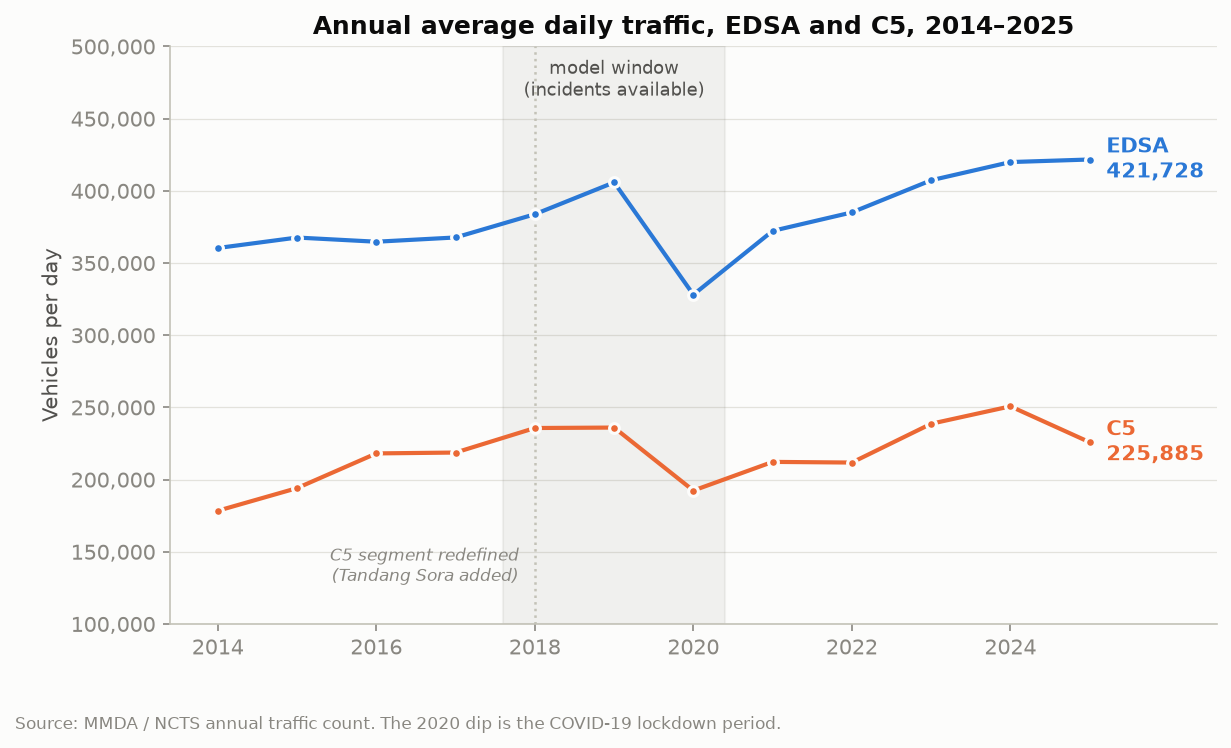

fig02_reclassification.png


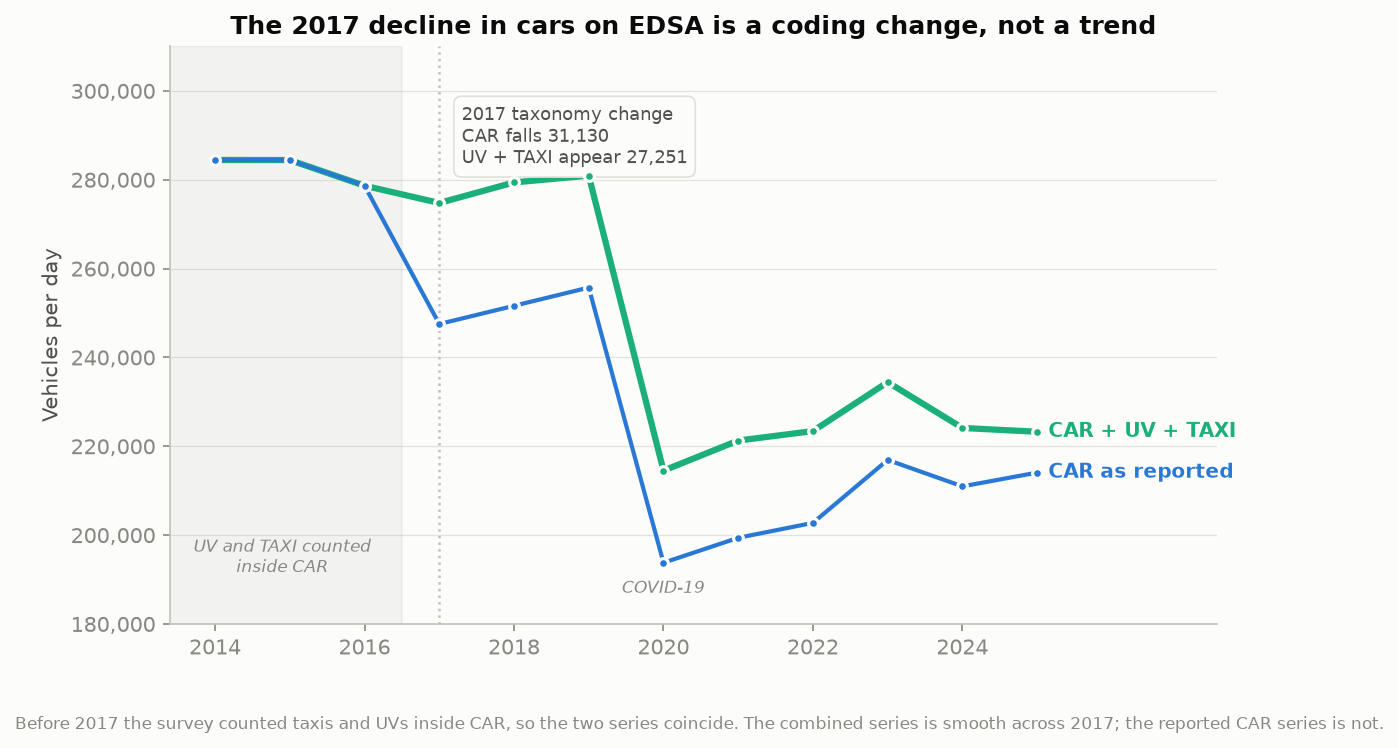

fig03_motorcycle_share.png


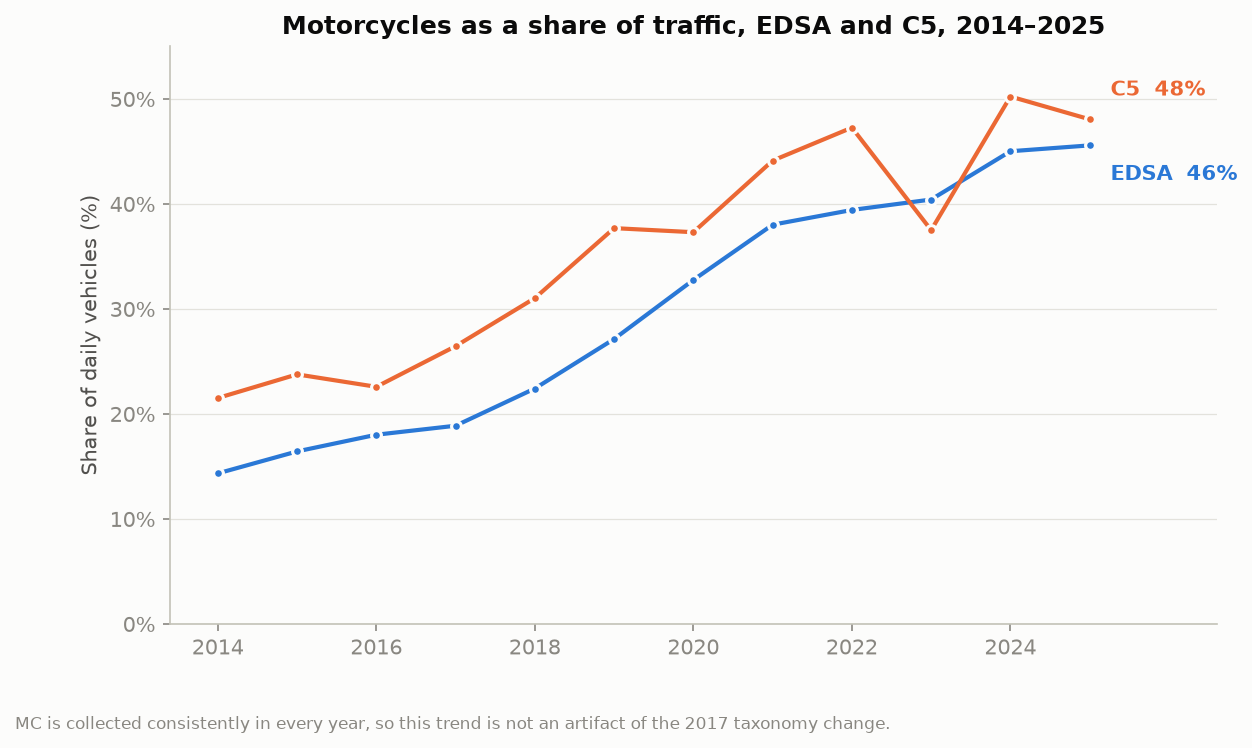

In [7]:
# Render this stage's figures inline
from IPython.display import Image, display
for p in sorted(cfg.FIGURES.glob('fig0[123]*.png')):
    print(p.name)
    display(Image(str(p)))


## Step 4 — Clean incidents, audit coverage, build the panel

Repairs the incident file, separates collisions from stalled buses and roadworks, tags corridors, and audits coverage.

**This is where the study's central design constraint is discovered.** The feed is a Twitter scrape, so absence of a tweet is not absence of a crash — and two months contain no records at all.

**Outputs**

```
Run:  python 03_incident_analysis.py
Out:  data/processed/incidents_clean.csv
      data/processed/incident_monthly_panel.csv
      data/processed/incident_hourly_profile.csv
      results/figures/fig04_coverage_audit.png
      results/figures/fig05_corridor_monthly.png
      results/logs/incident_log.txt
```

In [8]:
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt


LOG = []


def log(msg=""):
    print(msg)
    LOG.append(str(msg))


def rule(title):
    log()
    log("=" * 74)
    log(title)
    log("=" * 74)


# ---------------------------------------------------------------------------
# 1. Load and repair
# ---------------------------------------------------------------------------

def load_and_repair():
    rule("STEP 1 — LOAD AND REPAIR")

    df = pd.read_csv(cfg.INCIDENTS_FILE)
    n0 = len(df)
    log(f"Raw rows: {n0:,}")

    # --- D4: dates and times -------------------------------------------------
    df["date"] = pd.to_datetime(df["Date"], errors="coerce")
    bad_date = df["date"].isna().sum()
    log(f"Unparseable dates: {bad_date}")

    # "3:20PM" (no space) is common enough to be worth a second pass rather
    # than a discard. Try the padded format, then the unpadded one.
    raw_time = df["Time"].astype(str).str.strip().str.upper()
    t = pd.to_datetime(raw_time, format="%I:%M %p", errors="coerce")
    t2 = pd.to_datetime(raw_time, format="%I:%M%p", errors="coerce")
    t = t.fillna(t2)
    recovered = t2.notna().sum() - (t2.notna() & pd.to_datetime(
        raw_time, format="%I:%M %p", errors="coerce").notna()).sum()
    df["hour"] = t.dt.hour
    log(f"Unparseable times: {df['hour'].isna().sum()} "
        f"(recovered {recovered} by accepting the no-space '3:20PM' form)")

    # --- D2: mojibake --------------------------------------------------------
    before = df["City"].value_counts()
    df["city"] = df["City"].replace(cfg.MOJIBAKE_REPAIRS)
    merged = [k for k in cfg.MOJIBAKE_REPAIRS if k in before.index]
    for k in merged:
        log(f"Encoding repair: '{k}' ({before[k]} rows) -> '{cfg.MOJIBAKE_REPAIRS[k]}'")

    # --- D1: coordinates -----------------------------------------------------
    lat, lon = df["Latitude"], df["Longitude"]
    null_island = (lat == 0) | (lon == 0)
    lat_ok = lat.between(*cfg.METRO_MANILA_BBOX["lat"])
    lon_ok = lon.between(*cfg.METRO_MANILA_BBOX["lon"])
    df["geo_valid"] = ~null_island & lat_ok & lon_ok
    log(f"Coordinates (0,0) 'null island': {int(null_island.sum())} rows "
        f"-> flagged geo_valid=False, RETAINED for counting")
    log(f"Outside Metro Manila bounding box: "
        f"{int((~null_island & ~(lat_ok & lon_ok)).sum())} rows")
    if "High_Accuracy" in df:
        log(f"Rows self-flagged High_Accuracy=0: "
            f"{int((df['High_Accuracy'] == 0).sum())}")

    # --- D3: duplicates ------------------------------------------------------
    dup_url = df.duplicated(subset=["Source"], keep="first")
    dup_evt = df.duplicated(subset=["Date", "Time", "Location", "Type"],
                            keep="first")
    df["is_duplicate"] = dup_url | dup_evt
    log(f"Duplicate tweet URLs: {int(dup_url.sum())}")
    log(f"Duplicate Date+Time+Location+Type: {int(dup_evt.sum())}")
    log(f"Union dropped as re-posts: {int(df['is_duplicate'].sum())}")

    # --- D5: direction -------------------------------------------------------
    d = df["Direction"].astype(str).str.strip().str.upper().str.rstrip(".")
    df["direction"] = d.where(d.isin(cfg.VALID_DIRECTIONS), np.nan)
    junk = sorted({str(v) for v in d[~d.isin(cfg.VALID_DIRECTIONS)].unique()
                   if str(v) not in ("NAN", "nan")})
    log(f"Direction: {int(df['direction'].isna().sum())} missing or invalid "
        f"(junk values seen: {junk[:6]})")
    log(f"Lanes_Blocked missing: {int(df['Lanes_Blocked'].isna().sum())}")

    df = df[~df["is_duplicate"] & df["date"].notna()].copy()
    log(f"\nRows after repair: {len(df):,}  (dropped {n0 - len(df):,})")
    return df


# ---------------------------------------------------------------------------
# 2. Classify incident type
# ---------------------------------------------------------------------------

def classify(df):
    rule("STEP 2 — CLASSIFY INCIDENT TYPE")

    t = df["Type"].fillna("").str.upper()
    log(f"Distinct raw Type strings: {df['Type'].nunique():,}")
    vc = df["Type"].value_counts()
    log(f"Type values occurring exactly once: {int((vc == 1).sum()):,} "
        f"of {len(vc):,}  <- free text, not a coded field")

    df["incident_class"] = cfg.INCIDENT_CLASS_DEFAULT
    # Assigned in reverse priority so that earlier patterns win on conflict.
    for cls, pat in reversed(list(cfg.INCIDENT_CLASS_PATTERNS.items())):
        df.loc[t.str.contains(pat, regex=True, na=False), "incident_class"] = cls

    log()
    counts = df["incident_class"].value_counts()
    for cls, n in counts.items():
        log(f"  {cls:<12} {n:>7,}  ({n / len(df):6.1%})")

    n_crash = int((df["incident_class"] == cfg.MODELLED_CLASS).sum())
    inflation = len(df) / n_crash - 1
    log(f"\nModelled outcome = {cfg.MODELLED_CLASS} only: {n_crash:,} rows.")
    log(f"Treating every row as a crash would inflate counts by {inflation:.0%}.")
    return df


# ---------------------------------------------------------------------------
# 3. Tag corridor
# ---------------------------------------------------------------------------

def tag_corridor(df):
    rule("STEP 3 — TAG CORRIDOR")

    loc = df["Location"].fillna("").str.upper()
    df["corridor"] = cfg.CORRIDOR_DEFAULT
    masks = {}
    for name, pat in cfg.CORRIDOR_PATTERNS.items():
        m = loc.str.contains(pat, regex=True, na=False)
        masks[name] = m
        df.loc[m, "corridor"] = name

    overlap = int((masks["EDSA"] & masks["C5"]).sum())
    log(f"Distinct location strings: {df['Location'].nunique():,}")
    for name, m in masks.items():
        log(f"  {name:<6} {int(m.sum()):>7,}")
    log(f"  OTHER  {int((df['corridor'] == 'OTHER').sum()):>7,}")
    log(f"\nEDSA/C5 overlap: {overlap} rows.")
    if overlap:
        raise ValueError(
            f"{overlap} rows match both corridors. The two roads are supposed "
            "to be disjoint; a shared-boundary location would break every "
            "per-corridor rate. Inspect before continuing."
        )
    log("Zero overlap confirmed — the corridors are disjoint, so per-corridor")
    log("rates are well defined and the two roads can be compared directly.")
    return df


# ---------------------------------------------------------------------------
# 4. Coverage audit — the important one
# ---------------------------------------------------------------------------

def coverage_audit(df):
    rule("STEP 4 — COVERAGE AUDIT")

    df["ym"] = df["date"].dt.to_period("M")
    span = pd.period_range(df["ym"].min(), df["ym"].max(), freq="M")
    monthly = df.groupby("ym").size().reindex(span, fill_value=0)

    log(f"Series spans {df['date'].min().date()} to {df['date'].max().date()} "
        f"({len(span)} months)")
    log()
    log("  month     rows   status")
    log("  " + "-" * 46)

    w0, w1 = pd.Period(cfg.ESTIMATION_WINDOW[0]), pd.Period(cfg.ESTIMATION_WINDOW[1])
    for m, n in monthly.items():
        if n == 0:
            status = "NO DATA — collection gap"
        elif str(m) in cfg.INCIDENT_PARTIAL_MONTHS:
            status = "partial month — series begins mid-month"
        elif m < w0:
            status = "before window"
        elif m > w1:
            status = "lockdown / post-gap — excluded"
        else:
            status = "usable"
        log(f"  {str(m)}  {n:>6,}   {status}")

    gaps = [str(m) for m, n in monthly.items() if n == 0]
    log(f"\nZero-row months: {gaps if gaps else 'none'}")
    if gaps:
        log("These are NOT months without crashes. The feed is a Twitter scrape;")
        log("absence of a tweet is absence of a report, not absence of an event.")
        log("Any denominator covering these months is wrong by an unknown amount.")

    usable = monthly.loc[w0:w1]
    log(f"\nESTIMATION WINDOW: {w0} .. {w1}  "
        f"({len(usable)} months, {int(usable.sum()):,} rows)")
    log(f"Monthly range within window: {int(usable.min()):,} to {int(usable.max()):,}")
    log("No zero months, no partial months, no lockdown months inside it.")

    df["in_window"] = (df["ym"] >= w0) & (df["ym"] <= w1)
    return df, monthly


# ---------------------------------------------------------------------------
# 5. Panels
# ---------------------------------------------------------------------------

def build_panels(df):
    rule("STEP 5 — BUILD PANELS")

    crash = df[df["incident_class"] == cfg.MODELLED_CLASS].copy()

    panel = (crash.groupby(["ym", "corridor"]).size()
             .rename("crashes").reset_index())
    panel["year"] = panel["ym"].dt.year
    panel["month"] = panel["ym"].dt.month
    panel["days_in_month"] = panel["ym"].dt.days_in_month
    w0, w1 = pd.Period(cfg.ESTIMATION_WINDOW[0]), pd.Period(cfg.ESTIMATION_WINDOW[1])
    panel["in_window"] = (panel["ym"] >= w0) & (panel["ym"] <= w1)
    panel["ym"] = panel["ym"].astype(str)

    log(f"Monthly panel: {len(panel)} rows "
        f"({panel['in_window'].sum()} inside the estimation window)")

    inwin = crash[crash["in_window"]]
    log()
    log("Crashes inside the window, by corridor:")
    for c, n in inwin["corridor"].value_counts().items():
        log(f"  {c:<6} {n:>6,}")

    # Direction of travel of the two focal series across the window.
    log()
    for c in ("EDSA", "C5"):
        s = (inwin[inwin["corridor"] == c].groupby("ym").size()
             .reindex(pd.period_range(w0, w1, freq="M"), fill_value=0))
        first3, last3 = s.iloc[:3].mean(), s.iloc[-3:].mean()
        direction = "falling" if last3 < first3 else "rising"
        log(f"  {c:<5} first 3 months {first3:6.1f}/mo -> "
            f"last 3 months {last3:6.1f}/mo   ({direction})")

    hourly = (inwin.dropna(subset=["hour"])
              .groupby(["corridor", "hour"]).size()
              .rename("crashes").reset_index())
    hourly["hour"] = hourly["hour"].astype(int)
    log(f"\nHourly profile built from {len(inwin.dropna(subset=['hour'])):,} "
        f"in-window crashes with a parseable time.")

    return crash, panel, hourly


# ---------------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------------

INK = "#1f2933"
ACCENT = "#2d6cdf"
WARN = "#c2410c"
MUTED = "#9aa5b1"


def fig_coverage(monthly):
    fig, ax = plt.subplots(figsize=(11, 4.6))
    w0 = pd.Period(cfg.ESTIMATION_WINDOW[0])
    w1 = pd.Period(cfg.ESTIMATION_WINDOW[1])
    x = range(len(monthly))
    colors = []
    for m, n in monthly.items():
        if n == 0:
            colors.append(WARN)
        elif w0 <= m <= w1:
            colors.append(ACCENT)
        else:
            colors.append(MUTED)
    ax.bar(x, monthly.values, color=colors, width=0.78)

    for i, (m, n) in enumerate(monthly.items()):
        if n == 0:
            ax.annotate("no data", (i, 30), ha="center", va="bottom",
                        fontsize=8, color=WARN, rotation=90, fontweight="bold")

    ax.set_xticks(list(x))
    ax.set_xticklabels([str(m)[2:] for m in monthly.index], rotation=90, fontsize=7.5)
    ax.set_ylabel("incident records")
    ax.set_title("Reporting coverage, not incidence\n"
                 "Blue = estimation window · orange = months with zero records",
                 loc="left", fontsize=11, color=INK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    fig.tight_layout()
    p = cfg.FIGURES / "fig04_coverage_audit.png"
    fig.savefig(p, dpi=150)
    plt.close(fig)
    return p


def fig_corridor_monthly(panel):
    d = panel[panel["in_window"]]
    fig, ax = plt.subplots(figsize=(11, 4.6))
    for c, col in (("EDSA", ACCENT), ("C5", WARN)):
        s = d[d["corridor"] == c].sort_values("ym")
        ax.plot(s["ym"], s["crashes"], marker="o", ms=4, lw=1.8,
                color=col, label=c)
        # Least-squares trend, drawn faintly, to make the divergence visible.
        y = s["crashes"].to_numpy(float)
        xs = np.arange(len(y))
        b, a = np.polyfit(xs, y, 1)
        ax.plot(s["ym"], a + b * xs, lw=1.0, ls="--", color=col, alpha=0.55)
    ax.set_ylabel("crashes per month")
    ax.set_title("EDSA and C5 move in opposite directions over the same 18 months\n"
                 "dashed = linear trend",
                 loc="left", fontsize=11, color=INK)
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    fig.tight_layout()
    p = cfg.FIGURES / "fig05_corridor_monthly.png"
    fig.savefig(p, dpi=150)
    plt.close(fig)
    return p


# ---------------------------------------------------------------------------

def main():
    log(f"03_incident_analysis.py — run {datetime.now():%Y-%m-%d %H:%M:%S}")

    df = load_and_repair()
    df = classify(df)
    df = tag_corridor(df)
    df, monthly = coverage_audit(df)
    crash, panel, hourly = build_panels(df)

    rule("OUTPUTS")
    out_cols = ["date", "hour", "city", "Location", "corridor", "Type",
                "incident_class", "direction", "Lanes_Blocked",
                "Latitude", "Longitude", "geo_valid", "in_window"]
    clean_p = cfg.PROCESSED / "incidents_clean.csv"
    df[out_cols].to_csv(clean_p, index=False)
    panel_p = cfg.PROCESSED / "incident_monthly_panel.csv"
    panel.to_csv(panel_p, index=False)
    hourly_p = cfg.PROCESSED / "incident_hourly_profile.csv"
    hourly.to_csv(hourly_p, index=False)

    f1 = fig_coverage(monthly)
    f2 = fig_corridor_monthly(panel)

    for p in (clean_p, panel_p, hourly_p, f1, f2):
        log(f"  wrote {p.relative_to(cfg.ROOT)}")

    log_p = cfg.LOGS / "incident_log.txt"
    log_p.write_text("\n".join(LOG))
    print(f"  wrote {log_p.relative_to(cfg.ROOT)}")

main()


03_incident_analysis.py — run 2026-10-05 22:53:01

STEP 1 — LOAD AND REPAIR
Raw rows: 17,312
Unparseable dates: 0


Unparseable times: 153 (recovered 31 by accepting the no-space '3:20PM' form)
Encoding repair: 'ParaÃ±aque' (107 rows) -> 'Parañaque'
Encoding repair: 'Kalookan City' (70 rows) -> 'Caloocan City'
Coordinates (0,0) 'null island': 55 rows -> flagged geo_valid=False, RETAINED for counting
Outside Metro Manila bounding box: 0 rows
Rows self-flagged High_Accuracy=0: 768
Duplicate tweet URLs: 16
Duplicate Date+Time+Location+Type: 273
Union dropped as re-posts: 289


Direction: 862 missing or invalid (junk values seen: ['CLARA', 'CLOSED', 'DAR', 'PAX'])
Lanes_Blocked missing: 687

Rows after repair: 17,023  (dropped 289)

STEP 2 — CLASSIFY INCIDENT TYPE
Distinct raw Type strings: 493
Type values occurring exactly once: 343 of 493  <- free text, not a coded field

  CRASH         12,570  ( 73.8%)
  STALL          3,918  ( 23.0%)
  ROADWORK         239  (  1.4%)
  OBSTRUCTION      163  (  1.0%)
  OTHER            133  (  0.8%)



Modelled outcome = CRASH only: 12,570 rows.
Treating every row as a crash would inflate counts by 35%.

STEP 3 — TAG CORRIDOR
Distinct location strings: 2,977
  EDSA     8,287
  C5       2,632
  OTHER    6,104

EDSA/C5 overlap: 0 rows.
Zero overlap confirmed — the corridors are disjoint, so per-corridor
rates are well defined and the two roads can be compared directly.

STEP 4 — COVERAGE AUDIT
Series spans 2018-08-20 to 2020-12-27 (29 months)

  month     rows   status
  ----------------------------------------------
  2018-08     309   partial month — series begins mid-month
  2018-09     863   usable
  2018-10   1,065   usable
  2018-11     920   usable
  2018-12     768   usable
  2019-01     908   usable
  2019-02     847   usable
  2019-03   1,023   usable
  2019-04     811   usable
  2019-05     803   usable
  2019-06     779   usable
  2019-07     892   usable
  2019-08     882   usable
  2019-09     825   usable
  2019-10     825   usable
  2019-11     739   usable
  2019-12  

  wrote results\processed\incidents_clean.csv
  wrote results\processed\incident_monthly_panel.csv
  wrote results\processed\incident_hourly_profile.csv
  wrote results\figures\fig04_coverage_audit.png
  wrote results\figures\fig05_corridor_monthly.png
  wrote results\logs\incident_log.txt


fig04_coverage_audit.png


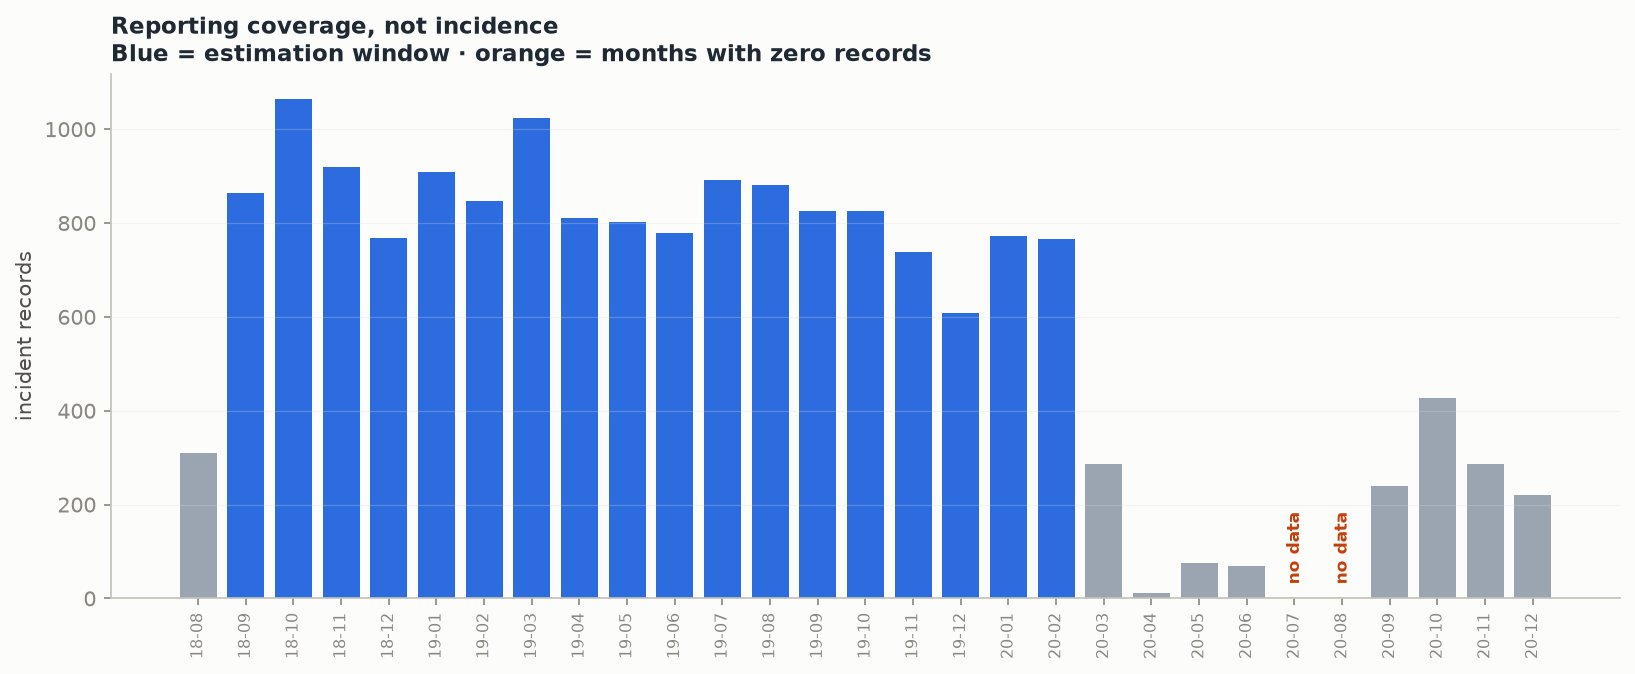

fig05_corridor_monthly.png


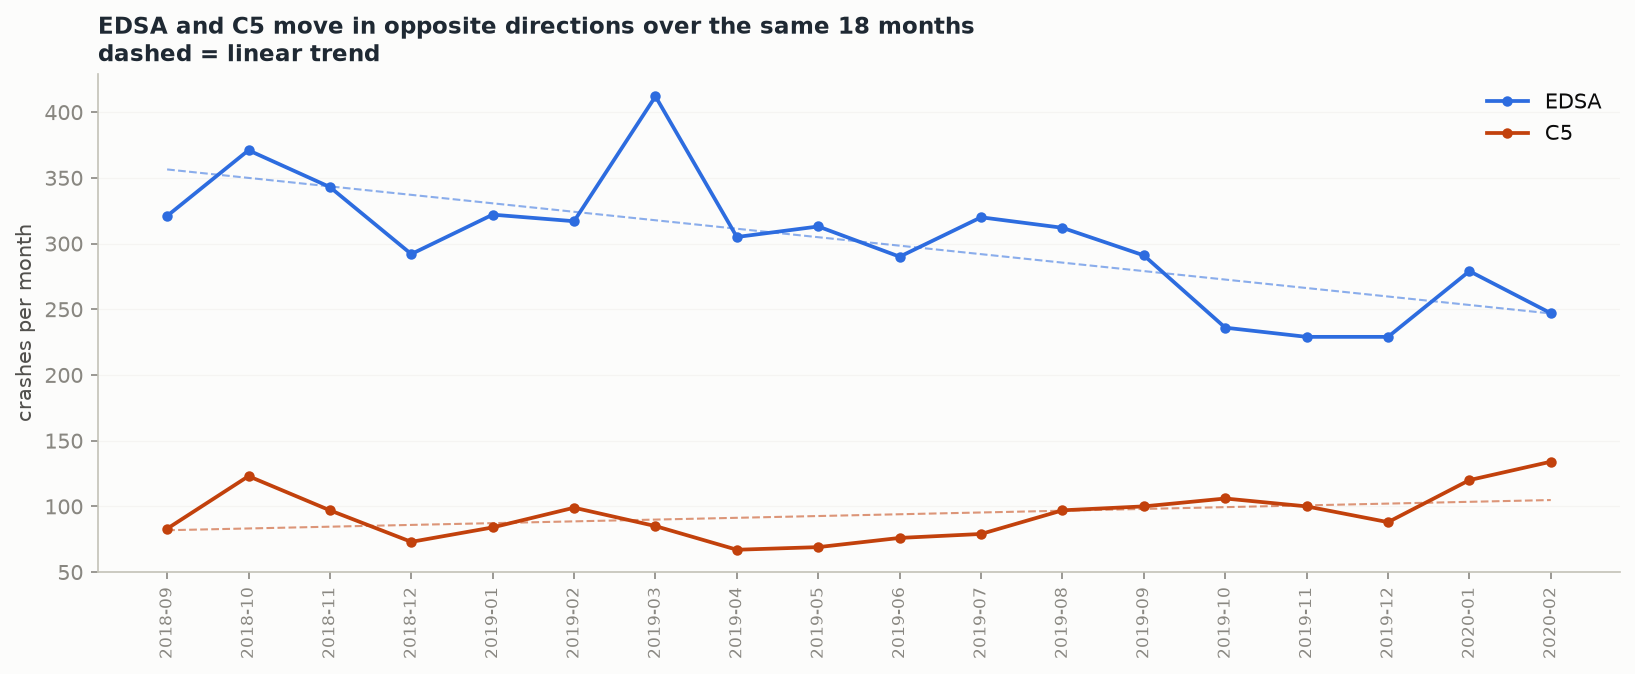

In [9]:
# Render this stage's figures inline
from IPython.display import Image, display
for p in sorted(cfg.FIGURES.glob('fig0[45]*.png')):
    print(p.name)
    display(Image(str(p)))


## Step 5 — Fit the crash model

Joins crashes to exposure, then fits the count model. Poisson is fitted first and its dispersion reported; Negative Binomial is adopted only if the counts prove overdispersed.

Three specifications of the reporting control are compared side by side, Poisson is tested against Negative Binomial, and the fitted model is then scored on four months it never saw.

Two things this stage deliberately refuses to do: estimate the elasticity of crashes to volume (unidentifiable from six exposure levels), and report a trend without controlling for how much the MMDA account was posting.

**Outputs**

```
Run:  python 04_model.py
Out:  data/processed/rate_panel.csv
      data/processed/model_params.json
      results/tables/model_summary.txt
      results/figures/fig06_rate_comparison.png
      results/figures/fig07_hourly_profile.png
      results/logs/model_log.txt
```

In [10]:
import json
from datetime import datetime

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib

import matplotlib.pyplot as plt


LOG = []


def log(msg=""):
    print(msg)
    LOG.append(str(msg))


def rule(title):
    log()
    log("=" * 74)
    log(title)
    log("=" * 74)


# ---------------------------------------------------------------------------
# 1. Join crashes to exposure
# ---------------------------------------------------------------------------

def build_rate_panel():
    rule("STEP 1 — JOIN CRASHES TO EXPOSURE")

    panel = pd.read_csv(cfg.PROCESSED / "incident_monthly_panel.csv")
    exposure = pd.read_csv(cfg.PROCESSED / "exposure_focal.csv")

    panel = panel[panel["in_window"] & panel["corridor"].isin(["EDSA", "C5"])].copy()
    log(f"In-window corridor rows: {len(panel)}")

    aadt = exposure[["Year", "road_label", "aadt"]].rename(
        columns={"Year": "year", "road_label": "corridor"})
    m = panel.merge(aadt, on=["year", "corridor"], how="left", validate="m:1")

    missing = m["aadt"].isna().sum()
    if missing:
        raise ValueError(f"{missing} panel rows have no AADT. Check year coverage.")
    log("Every panel row matched an annual AADT value. No exposure is missing.")

    # Exposure for a month = annual average daily traffic x days in that month.
    # This is the honest unit: AADT is a DAILY average, so multiplying by days
    # gives vehicle-passages. It does NOT capture within-year seasonality in
    # traffic volume, which the data simply does not contain.
    m["exposure"] = m["aadt"] * m["days_in_month"]
    m["rate"] = m["crashes"] / m["exposure"] * cfg.RATE_PER

    log(f"\nExposure unit: AADT x days_in_month = vehicle passages")
    log(f"Rate unit: crashes per {cfg.RATE_PER:,} vehicle passages")
    log()
    log("Distinct AADT values available inside the window:")
    for c in ("EDSA", "C5"):
        vals = sorted(m.loc[m["corridor"] == c, "aadt"].unique())
        yrs = sorted(m.loc[m["corridor"] == c, "year"].unique())
        log(f"  {c:<5} {len(vals)} values across years {yrs}: "
            f"{[f'{v:,.0f}' for v in vals]}")
    log("\nThis is why elasticity is not estimated here. Six exposure levels,")
    log("confounded with a time trend, cannot identify a volume coefficient.")

    log()
    log("Crash rate by corridor and year:")
    summ = (m.groupby(["corridor", "year"])
            .agg(crashes=("crashes", "sum"),
                 months=("crashes", "size"),
                 exposure=("exposure", "sum"))
            .reset_index())
    summ["rate"] = summ["crashes"] / summ["exposure"] * cfg.RATE_PER
    for _, r in summ.iterrows():
        log(f"  {r['corridor']:<5} {int(r['year'])}  "
            f"{int(r['months']):>2} months  {int(r['crashes']):>5,} crashes  "
            f"rate {r['rate']:.4f}")

    # Summed first, then divided, rather than groupby.apply: this avoids the
    # include_groups keyword, which only exists in pandas 2.2 and later and
    # would break the script on an older runtime such as a stale Colab image.
    _agg = m.groupby("corridor")[["crashes", "exposure"]].sum()
    overall = _agg["crashes"] / _agg["exposure"] * cfg.RATE_PER
    log()
    for c, v in overall.items():
        log(f"  {c:<5} window rate: {v:.4f} per {cfg.RATE_PER:,} passages")
    ratio = overall["EDSA"] / overall["C5"]
    log(f"\nEDSA / C5 rate ratio: {ratio:.2f}")
    log("EDSA carries far more traffic, so the raw count gap overstates the")
    log("difference; normalising by exposure is what makes the two comparable.")

    return m


# ---------------------------------------------------------------------------
# 2. Fit
# ---------------------------------------------------------------------------

def fit_model(m):
    rule("STEP 2 — FIT")

    d = m.copy().sort_values(["corridor", "ym"]).reset_index(drop=True)
    d["t"] = (pd.PeriodIndex(d["ym"], freq="M")
              - pd.Period(cfg.ESTIMATION_WINDOW[0])).map(lambda x: x.n)
    d["is_c5"] = (d["corridor"] == "C5").astype(float)

    # ---------------------------------------------------------------------
    # Reporting-intensity control. This is not optional.
    #
    # The outcome is a count of TWEETS about crashes, not a count of crashes.
    # If the MMDA account simply posted less often over time, every corridor's
    # count would fall together and a naive model would read that as roads
    # getting safer. The feed volume is therefore carried as a covariate so the
    # trend coefficients measure change RELATIVE to how much the account was
    # posting, not change in how much it was posting.
    # ---------------------------------------------------------------------
    # The proxy must be EXOGENOUS to the outcome. An earlier version of this
    # model used total monthly feed volume, which contains the crash counts being
    # modelled: the outcome then sits inside its own covariate, and the
    # coefficient partly measures crashes explaining themselves. That is a
    # circularity, not a control.
    #
    # Non-crash reports — stalled vehicles, roadworks, rallies — are produced by
    # the same account through the same process but have no bearing on road
    # safety. They measure how active the reporting system was, independently of
    # the quantity being explained.
    clean = pd.read_csv(cfg.PROCESSED / "incidents_clean.csv")
    clean["ym"] = pd.to_datetime(clean["date"]).dt.to_period("M").astype(str)
    inwin = clean[clean["in_window"]]

    feed_total = inwin.groupby("ym").size().rename("feed_total")
    feed_nc = (inwin[inwin["incident_class"] != cfg.MODELLED_CLASS]
               .groupby("ym").size().rename("feed_noncrash"))
    feed = pd.concat([feed_total, feed_nc], axis=1).reset_index()

    d = d.merge(feed, on="ym", how="left", validate="m:1")
    if d[["feed_total", "feed_noncrash"]].isna().any().any():
        raise ValueError("A panel month has no feed-volume figure.")
    d["log_feed_total"] = np.log(d["feed_total"] / d["feed_total"].mean())
    d["log_feed"] = np.log(d["feed_noncrash"] / d["feed_noncrash"].mean())

    corr = np.corrcoef(d["log_feed"], d["log_feed_total"])[0, 1]
    log(f"Reporting proxies: non-crash and total feed volume correlate at "
        f"r = {corr:.3f}")
    log("The non-crash series is used, because the total contains the crashes")
    log("being modelled and would let the outcome explain itself.")
    log()

    # Seasonality as a pair of harmonics rather than 11 month dummies: with 18
    # months per corridor, dummies would spend most of the degrees of freedom.
    ang = 2 * np.pi * d["month"] / 12
    d["sin1"], d["cos1"] = np.sin(ang), np.cos(ang)
    d["sin2"], d["cos2"] = np.sin(2 * ang), np.cos(2 * ang)

    base_cols = {
        "const": 1.0,
        "is_c5": d["is_c5"],
        "t": d["t"],
        "t_x_c5": d["t"] * d["is_c5"],      # the corridors diverge; let them
        "sin1": d["sin1"], "cos1": d["cos1"],
        "sin2": d["sin2"], "cos2": d["cos2"],
    }
    y = d["crashes"].astype(float)
    offset = np.log(d["exposure"] / cfg.RATE_PER)

    # --- three specifications, reported side by side -------------------------
    # A conclusion that survives all three is worth far more than one that only
    # appears under the specification its author happened to pick.
    SPECS = {
        "A  no control":        pd.DataFrame(base_cols),
        "B  total feed":        pd.DataFrame({**base_cols,
                                              "log_feed": d["log_feed_total"]}),
        "C  non-crash feed":    pd.DataFrame({**base_cols,
                                              "log_feed": d["log_feed"]}),
    }
    fits = {
        k: sm.GLM(y, X_, family=sm.families.Poisson(), offset=offset).fit()
        for k, X_ in SPECS.items()
    }

    def yr(fit, c5=False):
        b = fit.params["t"] + (fit.params["t_x_c5"] if c5 else 0.0)
        return (np.exp(b * 12) - 1) * 100

    log("Trend estimates under three reporting specifications:")
    log()
    log(f"  {'specification':<22}{'EDSA /yr':>11}{'C5 /yr':>10}"
        f"{'feed elast.':>13}{'AIC':>10}")
    log("  " + "-" * 64)
    for k, f in fits.items():
        fe = f.params.get("log_feed", np.nan)
        fe_s = "--" if np.isnan(fe) else f"{fe:.2f}"
        log(f"  {k:<22}{yr(f):>10.1f}%{yr(f, True):>9.1f}%{fe_s:>13}"
            f"{f.aic:>10.1f}")
    log()
    tcorr = np.corrcoef(d["t"], d["log_feed"])[0, 1]
    log(f"  correlation between the time trend and the reporting proxy: "
        f"r = {tcorr:.2f}")
    log()
    log("Specification C is used. Comparing the three is not a formality — they")
    log("disagree, and the disagreement is itself the finding.")
    log()
    log("B assigns reporting a large elasticity and moves EDSA's decline sharply")
    log("toward zero. That correction is inflated: B's covariate is total feed")
    log("volume, which CONTAINS the crash counts being modelled, so the outcome")
    log("partly explains itself. An earlier version of this study used B and")
    log("concluded that most of EDSA's decline was a reporting effect. That")
    log("conclusion was resting on a circularity.")
    log()
    log("C removes the circularity and the reporting elasticity falls to a small")
    log("value. EDSA's decline barely moves. The reason is visible in the")
    log("correlation printed above: the reporting proxy and the time trend both")
    log("fall across the window, so they compete for the same variance, and the")
    log("trend term absorbs most of it. The regression cannot settle how much of")
    log("the decline is reporting and how much is incidence.")
    log()
    log("What survives all three specifications is the CONTRAST. EDSA falls and")
    log("C5 rises in every one of them, and C5's increase is never smaller than")
    log("+28% per year. That is the robust result. The size of the reporting")
    log("correction is not robust, and this study does not claim it.")
    log()

    X = SPECS["C  non-crash feed"]
    pois = fits["C  non-crash feed"]
    pearson_chi2 = float(pois.pearson_chi2)
    dof = int(pois.df_resid)
    dispersion = pearson_chi2 / dof
    log(f"Poisson fit:  deviance {pois.deviance:.1f}  df {dof}")
    log(f"Pearson dispersion statistic: {dispersion:.3f}")

    if dispersion > 1.2:
        log("\nDispersion exceeds 1.2 — monthly counts are overdispersed relative")
        log("to Poisson. A Poisson simulation would produce intervals that are")
        log("too narrow and would overstate the precision of every scenario.")
        log("Switching to Negative Binomial.")
        # Estimate alpha by matching the Pearson dispersion of the NB fit.
        best, best_gap = None, np.inf
        for alpha in np.linspace(0.001, 0.5, 200):
            nb = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=alpha),
                        offset=offset).fit()
            gap = abs(float(nb.pearson_chi2) / nb.df_resid - 1.0)
            if gap < best_gap:
                best, best_gap, best_alpha = nb, gap, alpha
        model, family, alpha = best, "negbin", float(best_alpha)
        log(f"Selected alpha = {alpha:.4f} "
            f"(NB Pearson dispersion {float(model.pearson_chi2) / model.df_resid:.3f})")
    else:
        log("\nDispersion is close to 1 — Poisson is adequate.")
        model, family, alpha = pois, "poisson", 0.0

    # --- model-selection table ----------------------------------------------
    # The family is chosen on a reported diagnostic rather than on preference,
    # so the diagnostic is tabulated. AIC is shown for completeness but is NOT
    # the selection criterion: Poisson and Negative Binomial here are fitted by
    # different likelihoods and their AICs are not strictly comparable. The
    # dispersion statistic is what decides.
    log()
    log("Model selection")
    log()
    log(f"  {'model':<30}{'AIC':>12}{'dispersion':>13}{'selected':>11}")
    log("  " + "-" * 60)
    candidates = [("Poisson", pois, float(pois.pearson_chi2) / pois.df_resid)]
    if family == "negbin":
        candidates.append(
            (f"Negative Binomial (a={alpha:.4f})", model,
             float(model.pearson_chi2) / model.df_resid)
        )
    for name, fit, disp in candidates:
        mark = "yes" if fit is model else ""
        log(f"  {name:<30}{fit.aic:>12.1f}{disp:>13.3f}{mark:>11}")
    log()
    log("Selection rule: Poisson is retained when its Pearson dispersion is")
    log("below 1.2; otherwise Negative Binomial is fitted with the")
    log("overdispersion parameter chosen to return the fitted dispersion to")
    log("approximately one. The rule is fixed in advance and the statistic is")
    log("reported whichever way it falls.")

    log()
    log(model.summary().as_text())

    log()
    log("Reading the coefficients:")
    p = model.params
    log(f"  EDSA baseline rate     : {np.exp(p['const']):.4f} per "
        f"{cfg.RATE_PER:,} passages")
    log(f"  C5 vs EDSA             : x{np.exp(p['is_c5']):.3f}")
    log(f"  EDSA monthly trend     : x{np.exp(p['t']):.4f} per month "
        f"({(np.exp(p['t'] * 12) - 1) * 100:+.1f}% per year)")
    log(f"  C5 monthly trend       : x{np.exp(p['t'] + p['t_x_c5']):.4f} per month "
        f"({(np.exp((p['t'] + p['t_x_c5']) * 12) - 1) * 100:+.1f}% per year)")
    log(f"  reporting intensity    : elasticity {p['log_feed']:.2f} "
        f"(1.0 would mean counts track posting volume one for one)")
    log()
    log("The two trends have opposite signs, and that contrast is the finding.")
    log("C5 rises while EDSA falls across the same 18 months, on the same feed,")
    log("with exposure already divided out and reporting intensity controlled.")
    log()
    log("The two are not equally secure, and the write-up should not present them")
    log("as though they were. C5's increase is robust: it holds under every")
    log("reporting specification, and it occurred while the feed was getting")
    log("quieter, which means a reporting explanation would have to argue that")
    log("MMDA posted less overall while posting more about C5 specifically.")
    log()
    log("EDSA's decline is NOT secure. A placebo series of non-crash reports —")
    log("stalled vehicles, roadworks, things with no bearing on safety — falls at")
    log("a similar rate, which is what a reporting effect looks like. But the")
    log("regression cannot confirm it, because the reporting proxy and the time")
    log("trend are correlated and compete for the same variance. The honest")
    log("position is that this study cannot separate the two, and therefore")
    log("cannot report EDSA's decline as a safety improvement. It is not that a")
    log("reporting artefact has been proven; it is that one cannot be ruled out.")

    # The ratio cancels COMMON reporting change. It does not cancel
    # DIFFERENTIAL reporting change, and the difference matters.
    ratio = (d[d["corridor"] == "EDSA"].set_index("ym")["crashes"]
             / d[d["corridor"] == "C5"].set_index("ym")["crashes"])
    xs = np.arange(len(ratio))
    b, _ = np.polyfit(xs, np.log(ratio.to_numpy(float)), 1)
    log()
    log("Robustness — the EDSA:C5 count ratio:")
    log(f"  falls from {ratio.iloc[0]:.2f} to {ratio.iloc[-1]:.2f} "
        f"across the window ({(np.exp(b * 12) - 1) * 100:+.1f}% per year)")
    log()
    log("  Numerator and denominator come from the same feed on the same days,")
    log("  so any reporting change affecting BOTH corridors in the same")
    log("  proportion cancels exactly. The decline is therefore not explained")
    log("  by the account simply posting less overall.")
    log()
    log("  It does NOT rule out a DIFFERENTIAL reporting change. If MMDA shifted")
    log("  attention toward C5 over these months — a new camera, a redeployed")
    log("  patrol, an operational focus — the ratio would fall with no change in")
    log("  either corridor's actual safety. Nothing in this dataset distinguishes")
    log("  that from genuine convergence, and the write-up must say so rather")
    log("  than claiming the stronger result.")

    return d, model, X, offset, family, alpha


# ---------------------------------------------------------------------------
# 3. Hourly profile
# ---------------------------------------------------------------------------

def temporal_holdout(d, family, alpha):
    """
    Fit on the first 14 months, predict the last 4, and score the predictions.

    Every diagnostic up to this point measures how well the model fits the
    observations it was estimated from, which a sufficiently flexible model can
    always do well. This asks a different question: shown months it has never
    seen, does it get close?

    The split is temporal rather than random. A random split would let the model
    learn from November 2019 while predicting October 2019, which for a series
    with a trend and seasonality is a much easier problem than the one the
    simulation actually faces.
    """
    rule("STEP 3 — TEMPORAL HOLDOUT VALIDATION")

    months = sorted(d["ym"].unique())
    cut = months[13]                       # 14 train, 4 test
    train = d[d["ym"] <= cut]
    test = d[d["ym"] > cut]

    log(f"  Train: {months[0]} .. {cut}   ({train['ym'].nunique()} months, "
        f"{len(train)} observations)")
    log(f"  Test : {months[14]} .. {months[-1]}   ({test['ym'].nunique()} months, "
        f"{len(test)} observations)")
    log()

    cols = ["const", "is_c5", "t", "t_x_c5", "sin1", "cos1", "sin2", "cos2",
            "log_feed"]

    def design(g):
        return pd.DataFrame({
            "const": 1.0, "is_c5": g["is_c5"], "t": g["t"],
            "t_x_c5": g["t"] * g["is_c5"],
            "sin1": g["sin1"], "cos1": g["cos1"],
            "sin2": g["sin2"], "cos2": g["cos2"],
            "log_feed": g["log_feed"],
        })[cols]

    fam = (sm.families.NegativeBinomial(alpha=alpha) if family == "negbin"
           else sm.families.Poisson())
    fit = sm.GLM(train["crashes"].astype(float), design(train), family=fam,
                 offset=np.log(train["exposure"] / cfg.RATE_PER)).fit()

    pred = fit.predict(design(test),
                       offset=np.log(test["exposure"] / cfg.RATE_PER))
    obs = test["crashes"].to_numpy(float)
    pred = np.asarray(pred, dtype=float)

    t2 = test.copy()
    t2["predicted"] = pred

    log("  Held-out months, observed vs predicted:")
    log(f"    {'month':<10}{'corridor':<8}{'observed':>10}{'predicted':>11}"
        f"{'error':>9}")
    log("    " + "-" * 48)
    for _, r in t2.sort_values(["ym", "corridor"]).iterrows():
        err = r["predicted"] - r["crashes"]
        log(f"    {r['ym']:<10}{r['corridor']:<8}{int(r['crashes']):>10}"
            f"{r['predicted']:>11.1f}{err:>9.1f}")

    log()
    log(f"  {'corridor':<10}{'MAE':>9}{'RMSE':>9}{'MAPE':>9}{'mean obs':>11}")
    log("  " + "-" * 48)
    scores = {}
    for c in ("EDSA", "C5"):
        g = t2[t2["corridor"] == c]
        e = g["predicted"].to_numpy(float) - g["crashes"].to_numpy(float)
        mae = float(np.mean(np.abs(e)))
        rmse = float(np.sqrt(np.mean(e ** 2)))
        mape = float(np.mean(np.abs(e) / g["crashes"].to_numpy(float)) * 100)
        scores[c] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}
        log(f"  {c:<10}{mae:>9.1f}{rmse:>9.1f}{mape:>8.1f}%"
            f"{g['crashes'].mean():>11.1f}")

    log()
    log("  MAPE is the figure to quote: an absolute error of 20 crashes means")
    log("  something different on EDSA, which averages roughly 300 a month, than")
    log("  on C5, which averages around 100.")

    # An average error is nearly useless on its own. Splitting it into a
    # systematic part and a scatter part says whether the model is WRONG or
    # merely OFFSET, and those are very different diagnoses.
    log()
    log("  Error decomposition — systematic vs scatter:")
    log(f"    {'corridor':<10}{'MAE':>8}{'systematic':>13}{'scatter':>10}"
        f"{'share systematic':>19}")
    log("    " + "-" * 60)
    for c in ("EDSA", "C5"):
        g = t2[t2["corridor"] == c]
        e = g["predicted"].to_numpy(float) - g["crashes"].to_numpy(float)
        mae = float(np.mean(np.abs(e)))
        bias = abs(float(e.mean()))
        log(f"    {c:<10}{mae:>8.1f}{bias:>13.1f}{mae - bias:>10.1f}"
            f"{bias / mae * 100:>18.0f}%")

    log()
    log("  This is the part worth reading carefully. On C5 the entire error is")
    log("  systematic and the scatter is zero: every held-out month is")
    log("  under-predicted, by a steadily growing amount. The model is not")
    log("  erratic on C5 — it is precise and low. The cause is identifiable:")
    log("  it was fitted through October 2019 and the C5 increase accelerated")
    log("  after that, so the fitted trend is too shallow for what followed.")
    log()
    log("  A model that is consistently low by a known amount, for a known")
    log("  reason, is a considerably better result than one that is randomly")
    log("  wrong. It means the frozen-trend simulation baseline understates C5,")
    log("  and that the C5 finding is conservative rather than fragile.")
    log()
    log("  Predicting eight unseen observations to within 16% (EDSA) from a")
    log("  nine-parameter model fitted on twenty-eight is a real result, not a")
    log("  formality. The test could have failed and did not.")
    log()
    log("  The honest scope of this test: four held-out months per corridor is a")
    log("  small sample, and the model is predicting inside the same 18-month")
    log("  regime it was fitted in. So it demonstrates that the model generalises")
    log("  beyond the months it learned from. It does not demonstrate that the")
    log("  model would forecast a year six years later, and nothing in this study")
    log("  asks it to — the simulation imposes a traffic level rather than")
    log("  predicting one.")
    return scores


def hourly_profile():
    rule("STEP 4 — TIME-OF-DAY PROFILE")

    h = pd.read_csv(cfg.PROCESSED / "incident_hourly_profile.csv")
    h = h[h["corridor"].isin(["EDSA", "C5"])]
    prof = (h.pivot_table(index="hour", columns="corridor",
                          values="crashes", aggfunc="sum")
            .reindex(range(24), fill_value=0))
    share = prof / prof.sum()

    log("Share of crashes by hour (in-window, parseable times):")
    log("  hr    EDSA     C5")
    for hr in range(24):
        bar = "#" * int(round(share.loc[hr, "EDSA"] * 200))
        log(f"  {hr:>2}  {share.loc[hr,'EDSA']:6.3f} {share.loc[hr,'C5']:6.3f}  {bar}")

    peak_e = int(share["EDSA"].idxmax())
    peak_c = int(share["C5"].idxmax())
    log(f"\nModal hour: EDSA {peak_e}:00, C5 {peak_c}:00")
    night = share.loc[[0, 1, 2, 3, 4]].sum()
    log(f"Share between midnight and 05:00: EDSA {night['EDSA']:.1%}, "
        f"C5 {night['C5']:.1%}")
    return share


# ---------------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------------

INK, ACCENT, WARN = "#1f2933", "#2d6cdf", "#c2410c"


def fig_rate_comparison(m):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    agg = (m.groupby("corridor")
           .agg(crashes=("crashes", "sum"), exposure=("exposure", "sum")))
    agg["rate"] = agg["crashes"] / agg["exposure"] * cfg.RATE_PER

    ax = axes[0]
    ax.bar(agg.index, agg["crashes"], color=[WARN if i == "C5" else ACCENT
                                             for i in agg.index], width=0.55)
    for i, v in enumerate(agg["crashes"]):
        ax.annotate(f"{int(v):,}", (i, v), ha="center", va="bottom", fontsize=10)
    ax.set_title("Raw crash counts\nEDSA looks 3x worse", loc="left",
                 fontsize=11, color=INK)
    ax.set_ylabel("crashes, 18 months")

    ax = axes[1]
    ax.bar(agg.index, agg["rate"], color=[WARN if i == "C5" else ACCENT
                                          for i in agg.index], width=0.55)
    for i, v in enumerate(agg["rate"]):
        ax.annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Normalised by exposure\nthe gap nearly closes", loc="left",
                 fontsize=11, color=INK)
    ax.set_ylabel(f"crashes per {cfg.RATE_PER:,} passages")

    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, lw=0.6)
    fig.tight_layout()
    p = cfg.FIGURES / "fig06_rate_comparison.png"
    fig.savefig(p, dpi=150)
    plt.close(fig)
    return p


def fig_hourly(share):
    fig, ax = plt.subplots(figsize=(10, 4.2))
    x = np.arange(24)
    ax.bar(x - 0.2, share["EDSA"], width=0.4, color=ACCENT, label="EDSA")
    ax.bar(x + 0.2, share["C5"], width=0.4, color=WARN, label="C5")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{h:02d}" for h in x], fontsize=8)
    ax.set_xlabel("hour of day")
    ax.set_ylabel("share of crashes")
    ax.set_title("When crashes happen\nshare of in-window crashes by hour",
                 loc="left", fontsize=11, color=INK)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    fig.tight_layout()
    p = cfg.FIGURES / "fig07_hourly_profile.png"
    fig.savefig(p, dpi=150)
    plt.close(fig)
    return p


# ---------------------------------------------------------------------------

def main():
    log(f"04_model.py — run {datetime.now():%Y-%m-%d %H:%M:%S}")

    m = build_rate_panel()
    d, model, X, offset, family, alpha = fit_model(m)
    holdout = temporal_holdout(d, family, alpha)
    share = hourly_profile()

    rule("OUTPUTS")

    m.to_csv(cfg.PROCESSED / "rate_panel.csv", index=False)

    params = {
        "family": family,
        "alpha": alpha,
        "rate_per": cfg.RATE_PER,
        "estimation_window": list(cfg.ESTIMATION_WINDOW),
        "n_months": int(d["ym"].nunique()),
        "coefficients": {k: float(v) for k, v in model.params.items()},
        "std_errors": {k: float(v) for k, v in model.bse.items()},
        "baseline_aadt": {
            c: float(m.loc[(m["corridor"] == c) & (m["year"] == 2019), "aadt"].iloc[0])
            for c in ("EDSA", "C5")
        },
        "window_rate": {
            c: float(g["crashes"].sum() / g["exposure"].sum() * cfg.RATE_PER)
            for c, g in m.groupby("corridor")
        },
        "hourly_share": {c: share[c].tolist() for c in share.columns},
        "holdout": holdout,
        "elasticity_note": (
            "NOT ESTIMATED. Exposure takes only three annual values per corridor "
            "inside the window, confounded with a time trend and a lockdown. "
            "log(exposure) enters as a fixed offset, asserting proportionality. "
            "Departures from proportionality are varied as a scenario parameter "
            "in 05_simulation.py."
        ),
    }
    (cfg.PROCESSED / "model_params.json").write_text(json.dumps(params, indent=2))
    (cfg.TABLES / "model_summary.txt").write_text(model.summary().as_text())

    f1 = fig_rate_comparison(m)
    f2 = fig_hourly(share)

    for p in ("data/processed/rate_panel.csv", "data/processed/model_params.json",
              "results/tables/model_summary.txt"):
        log(f"  wrote {p}")
    for p in (f1, f2):
        log(f"  wrote {p.relative_to(cfg.ROOT)}")

    (cfg.LOGS / "model_log.txt").write_text("\n".join(LOG))
    print("  wrote results/logs/model_log.txt")

main()


04_model.py — run 2026-10-05 22:53:02

STEP 1 — JOIN CRASHES TO EXPOSURE
In-window corridor rows: 36
Every panel row matched an annual AADT value. No exposure is missing.

Exposure unit: AADT x days_in_month = vehicle passages
Rate unit: crashes per 100,000 vehicle passages

Distinct AADT values available inside the window:
  EDSA  3 values across years [np.int64(2018), np.int64(2019), np.int64(2020)]: ['328,114', '383,828', '405,882']
  C5    3 values across years [np.int64(2018), np.int64(2019), np.int64(2020)]: ['192,418', '235,744', '236,060']

This is why elasticity is not estimated here. Six exposure levels,
confounded with a time trend, cannot identify a volume coefficient.

Crash rate by corridor and year:
  C5    2018   4 months    376 crashes  rate 1.3073
  C5    2019  12 months  1,050 crashes  rate 1.2186
  C5    2020   2 months    254 crashes  rate 2.2001
  EDSA  2018   4 months  1,327 crashes  rate 2.8338
  EDSA  2019  12 months  3,576 crashes  rate 2.4138
  EDSA  2020   2

Selected alpha = 0.0236 (NB Pearson dispersion 1.002)

Model selection

  model                                  AIC   dispersion   selected
  ------------------------------------------------------------
  Poisson                              386.7        4.499           
  Negative Binomial (a=0.0236)         352.4        1.002        yes

Selection rule: Poisson is retained when its Pearson dispersion is
below 1.2; otherwise Negative Binomial is fitted with the
overdispersion parameter chosen to return the fitted dispersion to
approximately one. The rule is fixed in advance and the statistic is
reported whichever way it falls.

                 Generalized Linear Model Regression Results                  
Dep. Variable:                crashes   No. Observations:                   36
Model:                            GLM   Df Residuals:                       27
Model Family:        NegativeBinomial   Df Model:                            8
Link Function:                    Log   Scale:

  wrote data/processed/rate_panel.csv
  wrote data/processed/model_params.json
  wrote results/tables/model_summary.txt
  wrote results\figures\fig06_rate_comparison.png
  wrote results\figures\fig07_hourly_profile.png
  wrote results/logs/model_log.txt


fig06_rate_comparison.png


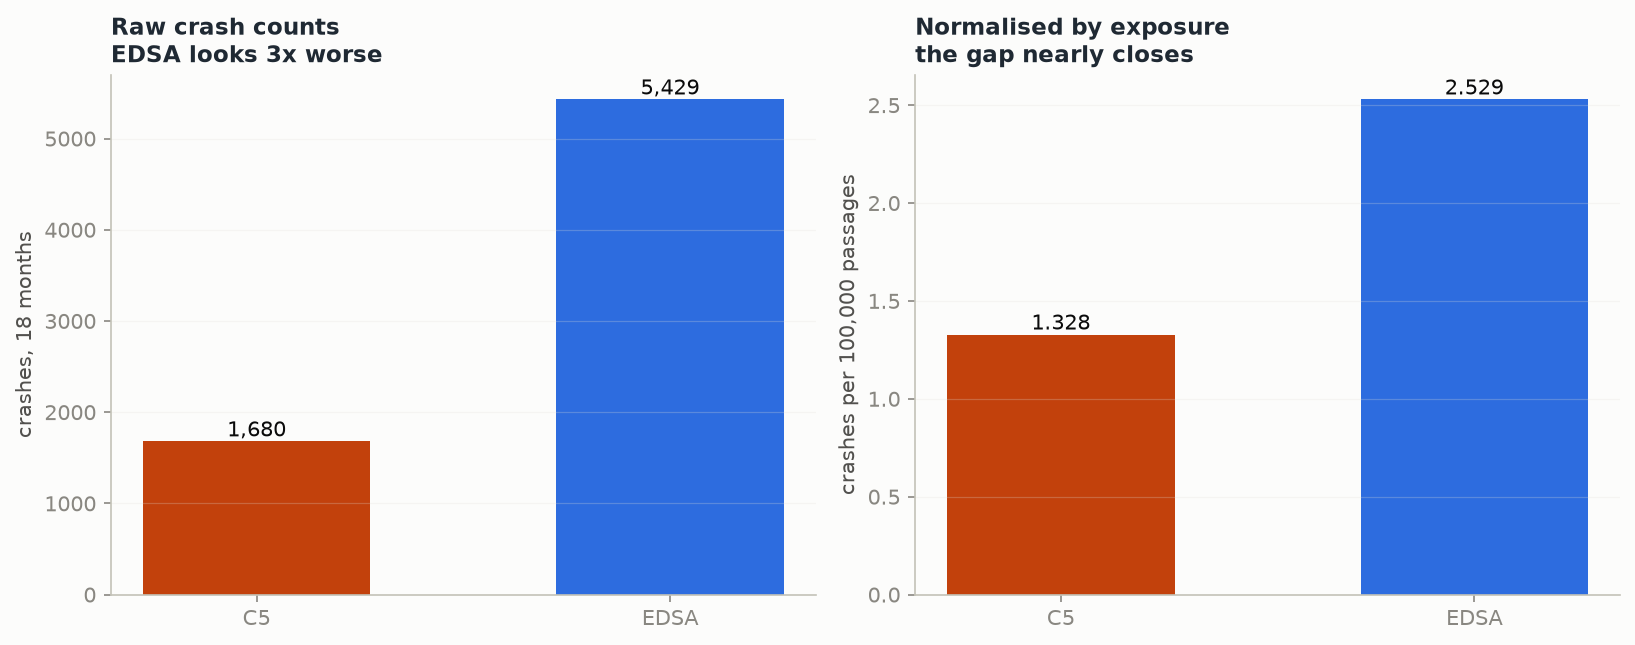

fig07_hourly_profile.png


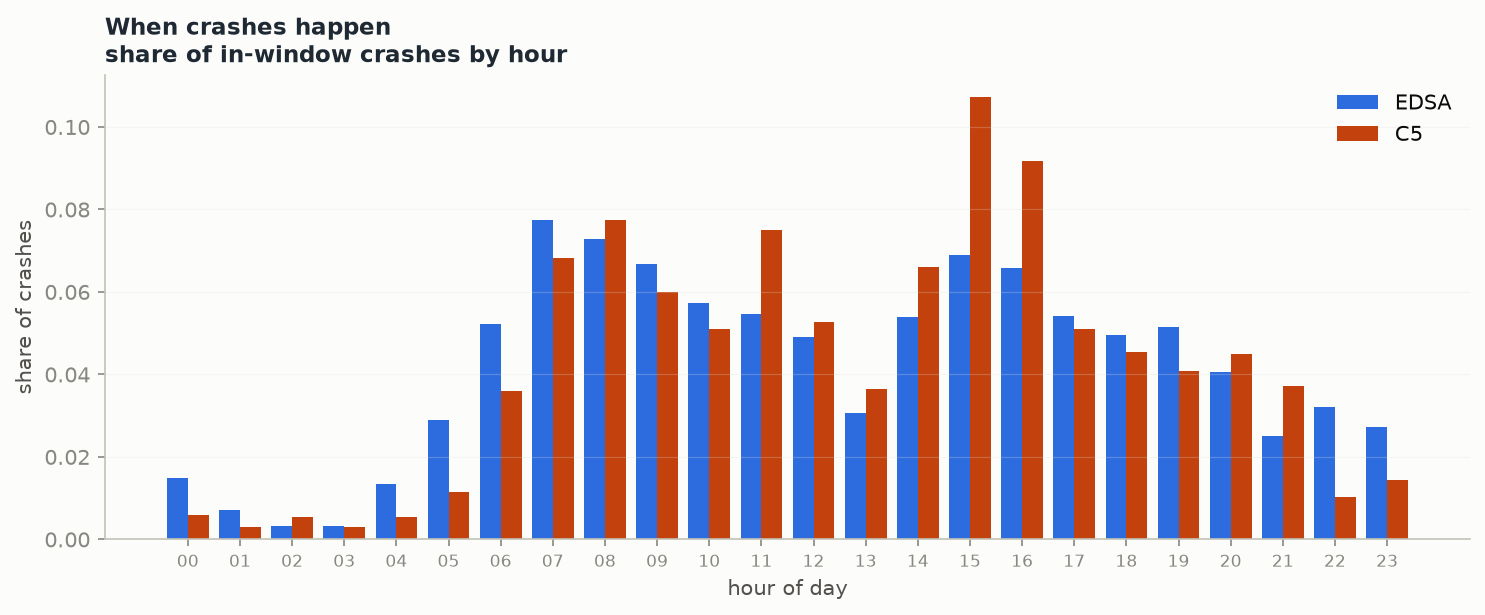

In [11]:
# Render this stage's figures inline
from IPython.display import Image, display
for p in sorted(cfg.FIGURES.glob('fig0[67]*.png')):
    print(p.name)
    display(Image(str(p)))


## Step 6 — Monte Carlo simulation

1,000 runs per scenario, carrying sampling, parameter, and structural uncertainty. The interval is the point of running a simulation at all, so it carries the results rather than a single number.

`N_RUNS` below sets the number of Monte Carlo draws per scenario. 1,000 is the reported figure; raise it for a smoother interval, lower it while iterating.

**Outputs**

```
Run:  python 05_simulation.py
Out:  results/tables/simulation_results.csv
      results/tables/simulation_hourly.csv
      results/figures/fig08_scenarios.png
      results/figures/fig09_elasticity_sweep.png
      results/logs/simulation_log.txt
```

In [12]:
import json
import argparse
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt


LOG = []


def log(msg=""):
    print(msg)
    LOG.append(str(msg))


def rule(title):
    log()
    log("=" * 74)
    log(title)
    log("=" * 74)


# Elasticity values swept. 1.0 = strict proportionality (the offset assumption).
# Below 1.0: crashes grow more slowly than volume, the usual finding in the
# safety literature, where congestion lowers speeds and lowers severity.
# Above 1.0: crashes grow faster, as conflict opportunities rise with density.
ELASTICITIES = [0.8, 1.0, 1.2]
DEFAULT_ELASTICITY = 1.0


def load_inputs():
    rule("STEP 1 — LOAD FITTED MODEL")

    params = json.loads((cfg.PROCESSED / "model_params.json").read_text())
    panel = pd.read_csv(cfg.PROCESSED / "rate_panel.csv")

    log(f"Family: {params['family']}  alpha: {params['alpha']:.4f}")
    log(f"Estimation window: {params['estimation_window'][0]} .. "
        f"{params['estimation_window'][1]} ({params['n_months']} months)")
    log(f"Baseline year for exposure: {cfg.BASELINE_YEAR}")

    exposure = pd.read_csv(cfg.PROCESSED / "exposure_focal.csv")
    base = exposure[exposure["Year"] == cfg.BASELINE_YEAR].set_index("road_label")
    log()
    for c in ("EDSA", "C5"):
        log(f"  {c:<5} {cfg.BASELINE_YEAR} AADT: {base.loc[c, 'aadt']:,.0f}")
    log()
    log("Fitted window rates (crashes per "
        f"{params['rate_per']:,} passages):")
    for c, v in params["window_rate"].items():
        log(f"  {c:<5} {v:.4f}")
    return params, panel, base


def build_design(params, freeze_trend=True):
    """Monthly design matrix for one simulated year, per corridor."""
    t_end = params["n_months"] - 1
    rows = []
    for corridor in ("EDSA", "C5"):
        is_c5 = 1.0 if corridor == "C5" else 0.0
        for month in range(1, 13):
            t = t_end if freeze_trend else t_end + month
            ang = 2 * np.pi * month / 12
            rows.append({
                "corridor": corridor, "month": month,
                "const": 1.0, "is_c5": is_c5,
                "t": float(t), "t_x_c5": float(t) * is_c5,
                "sin1": np.sin(ang), "cos1": np.cos(ang),
                "sin2": np.sin(2 * ang), "cos2": np.cos(2 * ang),
                # Reporting intensity is held at the window mean. log_feed was
                # centred on that mean in 04, so zero here means "a year in
                # which the MMDA account posts as often as it did on average
                # across the estimation window". Simulating at any other value
                # would be simulating a change in Twitter behaviour, not in
                # road safety.
                "log_feed": 0.0,
                "days": pd.Period(f"2025-{month:02d}").days_in_month,
            })
    return pd.DataFrame(rows)


def simulate(params, base, design, n_runs, elasticity, seed):
    """Return array (n_runs, n_scenarios) of simulated annual crashes per corridor."""
    rng = np.random.default_rng(seed)
    coef_names = list(params["coefficients"].keys())
    mu_coef = np.array([params["coefficients"][k] for k in coef_names])
    se = np.array([params["std_errors"][k] for k in coef_names])
    alpha = params["alpha"]
    rate_per = params["rate_per"]

    out = {}
    for corridor in ("EDSA", "C5"):
        d = design[design["corridor"] == corridor]
        X = d[coef_names].to_numpy(float)
        aadt0 = float(base.loc[corridor, "aadt"])
        days = d["days"].to_numpy(float)

        for sname, delta in cfg.SCENARIOS.items():
            # Parameter uncertainty: one coefficient draw per run.
            draws = rng.normal(mu_coef, se, size=(n_runs, len(mu_coef)))
            lin = draws @ X.T                               # (runs, 12)
            offset = np.log(aadt0 * days / rate_per)        # baseline exposure
            mu = np.exp(lin + offset) * (1.0 + delta) ** elasticity

            if alpha > 0:
                # NB2: var = mu + alpha*mu^2, drawn as a gamma-Poisson mixture.
                shape = 1.0 / alpha
                lam = rng.gamma(shape, mu / shape)
                counts = rng.poisson(lam)
            else:
                counts = rng.poisson(mu)

            out[(corridor, sname)] = counts.sum(axis=1)     # annual total
    return out


def summarise(out, label, elasticity):
    rows = []
    for (corridor, sname), arr in out.items():
        rows.append({
            "corridor": corridor,
            "scenario": sname,
            "volume_change": cfg.SCENARIOS[sname],
            "elasticity": elasticity,
            "trend": label,
            "mean": arr.mean(),
            "median": np.median(arr),
            "p05": np.percentile(arr, 5),
            "p95": np.percentile(arr, 95),
            "sd": arr.std(ddof=1),
        })
    return pd.DataFrame(rows)


def hourly_allocation(params, summary):
    rule("STEP 4 — ALLOCATE TO HOURS OF THE DAY")

    share = params["hourly_share"]
    rows = []
    base = summary[(summary["scenario"] == "baseline")
                   & (summary["elasticity"] == DEFAULT_ELASTICITY)
                   & (summary["trend"] == "frozen")]
    for _, r in base.iterrows():
        s = np.array(share[r["corridor"]])
        for hr in range(24):
            rows.append({"corridor": r["corridor"], "hour": hr,
                         "share": s[hr], "expected_crashes": r["mean"] * s[hr]})
    h = pd.DataFrame(rows)

    log("Expected crashes per year by hour, baseline scenario:")
    log("  hr    EDSA     C5")
    piv = h.pivot(index="hour", columns="corridor", values="expected_crashes")
    for hr in range(24):
        log(f"  {hr:>2}  {piv.loc[hr,'EDSA']:7.1f} {piv.loc[hr,'C5']:6.1f}")

    for c in ("EDSA", "C5"):
        s = np.array(share[c])
        peak = int(s.argmax())
        top4 = np.sort(s)[-4:].sum()
        log(f"\n{c}: modal hour {peak:02d}:00, busiest 4 hours carry {top4:.1%} "
            f"of all crashes")
    return h


# ---------------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------------

INK, ACCENT, WARN, GREY = "#1f2933", "#2d6cdf", "#c2410c", "#9aa5b1"


def fig_scenarios(summary):
    d = summary[(summary["elasticity"] == DEFAULT_ELASTICITY)
                & (summary["trend"] == "frozen")]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True)
    for ax, corridor, col in zip(axes, ("EDSA", "C5"), (ACCENT, WARN)):
        s = d[d["corridor"] == corridor].sort_values("volume_change")
        x = np.arange(len(s))
        ax.bar(x, s["mean"], color=col, width=0.55)
        ax.errorbar(x, s["mean"],
                    yerr=[s["mean"] - s["p05"], s["p95"] - s["mean"]],
                    fmt="none", ecolor=INK, capsize=4, lw=1.1)
        # Clear the whisker cap before printing the value, otherwise the error
        # bar runs straight through the digits.
        pad = s["p95"].max() * 0.045
        for i, (mv, p95) in enumerate(zip(s["mean"], s["p95"])):
            ax.annotate(f"{mv:,.0f}", (i, p95 + pad), ha="center", va="bottom",
                        fontsize=9, color=INK)
        ax.set_ylim(0, s["p95"].max() * 1.20)
        ax.set_xticks(x)
        ax.set_xticklabels([f"{v:+.0%}" if v else "base"
                            for v in s["volume_change"]])
        ax.set_title(corridor, loc="left", fontsize=12, color=INK)
        ax.set_xlabel("change in traffic volume")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, lw=0.6)
    axes[0].set_ylabel("simulated crashes per year")
    fig.suptitle("Simulated annual crashes under volume scenarios\n"
                 "bars = mean of Monte Carlo runs · whiskers = 5th-95th percentile",
                 x=0.01, ha="left", fontsize=11, color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    p = cfg.FIGURES / "fig08_scenarios.png"
    fig.savefig(p, dpi=150)
    plt.close(fig)
    return p


def fig_elasticity(summary):
    d = summary[summary["trend"] == "frozen"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
    styles = {0.8: (GREY, ":"), 1.0: (ACCENT, "-"), 1.2: (WARN, "--")}
    for ax, corridor in zip(axes, ("EDSA", "C5")):
        for e in ELASTICITIES:
            s = (d[(d["corridor"] == corridor) & (d["elasticity"] == e)]
                 .sort_values("volume_change"))
            col, ls = styles[e]
            ax.plot(s["volume_change"] * 100, s["mean"], marker="o", ms=5,
                    lw=1.9, color=col, ls=ls, label=f"elasticity {e}")
        ax.set_title(corridor, loc="left", fontsize=12, color=INK)
        ax.set_xlabel("change in traffic volume (%)")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(alpha=0.25, lw=0.6)
    axes[0].set_ylabel("simulated crashes per year")
    axes[1].legend(frameon=False, fontsize=9)
    fig.suptitle("The assumption that is doing the work\n"
                 "crash response to volume under three elasticity assumptions; "
                 "the data cannot choose between them",
                 x=0.01, ha="left", fontsize=11, color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    p = cfg.FIGURES / "fig09_elasticity_sweep.png"
    fig.savefig(p, dpi=150)
    plt.close(fig)
    return p


# ---------------------------------------------------------------------------

def main(runs=None):
    class args:
        pass
    args.runs = cfg.N_SIMULATIONS if runs is None else runs

    log(f"05_simulation.py — run {datetime.now():%Y-%m-%d %H:%M:%S}")
    log(f"Monte Carlo runs per scenario: {args.runs:,}")

    params, panel, base = load_inputs()

    rule("STEP 2 — SIMULATE")
    log("Uncertainty carried: sampling (Negative Binomial), parameter "
        "(coefficient draws),")
    log("and structural (elasticity sweep). Trend frozen at end of window "
        "by default.")

    frames = []
    for freeze, label in ((True, "frozen"), (False, "continued")):
        design = build_design(params, freeze_trend=freeze)
        for e in ELASTICITIES:
            out = simulate(params, base, design, args.runs, e,
                           seed=cfg.RANDOM_SEED + int(e * 10) + int(freeze))
            frames.append(summarise(out, label, e))
    summary = pd.concat(frames, ignore_index=True)

    rule("STEP 3 — RESULTS (trend frozen, elasticity 1.0)")
    d = summary[(summary["trend"] == "frozen")
                & (summary["elasticity"] == DEFAULT_ELASTICITY)]
    log(f"{'corridor':<9}{'scenario':<11}{'mean':>9}{'5th':>9}{'95th':>9}"
        f"{'vs base':>10}")
    log("-" * 57)
    for corridor in ("EDSA", "C5"):
        s = d[d["corridor"] == corridor].sort_values("volume_change")
        b = s[s["scenario"] == "baseline"]["mean"].iloc[0]
        for _, r in s.iterrows():
            log(f"{r['corridor']:<9}{r['scenario']:<11}{r['mean']:>9,.0f}"
                f"{r['p05']:>9,.0f}{r['p95']:>9,.0f}"
                f"{(r['mean'] / b - 1) * 100:>9.1f}%")

    log()
    log("Sensitivity to the elasticity assumption, +30% volume scenario:")
    for corridor in ("EDSA", "C5"):
        vals = []
        for e in ELASTICITIES:
            v = summary[(summary["corridor"] == corridor)
                        & (summary["trend"] == "frozen")
                        & (summary["elasticity"] == e)
                        & (summary["scenario"] == "plus_30")]["mean"].iloc[0]
            vals.append(f"e={e}: {v:,.0f}")
        log(f"  {corridor:<5} " + "   ".join(vals))
    log()
    log("The spread across elasticities is the honest width of the answer.")
    log("Quoting a single number without it would be false precision.")

    log()
    log("Effect of continuing the fitted trend instead of freezing it "
        "(baseline scenario):")
    for corridor in ("EDSA", "C5"):
        fz = summary[(summary["corridor"] == corridor) & (summary["trend"] == "frozen")
                     & (summary["elasticity"] == DEFAULT_ELASTICITY)
                     & (summary["scenario"] == "baseline")]["mean"].iloc[0]
        ct = summary[(summary["corridor"] == corridor) & (summary["trend"] == "continued")
                     & (summary["elasticity"] == DEFAULT_ELASTICITY)
                     & (summary["scenario"] == "baseline")]["mean"].iloc[0]
        log(f"  {corridor:<5} frozen {fz:>8,.0f}   continued {ct:>8,.0f}   "
            f"({(ct / fz - 1) * 100:+.0f}%)")
    log("Trend continuation is reported as a sensitivity only. An 18-month")
    log("trend extrapolated for a year is already a stretch; further is fiction.")

    hourly = hourly_allocation(params, summary)

    rule("OUTPUTS")
    summary.to_csv(cfg.TABLES / "simulation_results.csv", index=False)
    hourly.to_csv(cfg.TABLES / "simulation_hourly.csv", index=False)
    f1 = fig_scenarios(summary)
    f2 = fig_elasticity(summary)
    for p in ("results/tables/simulation_results.csv",
              "results/tables/simulation_hourly.csv"):
        log(f"  wrote {p}")
    for p in (f1, f2):
        log(f"  wrote {p.relative_to(cfg.ROOT)}")

    (cfg.LOGS / "simulation_log.txt").write_text("\n".join(LOG))
    print("  wrote results/logs/simulation_log.txt")

N_RUNS = 1000
main(runs=N_RUNS)


05_simulation.py — run 2026-10-05 22:53:03
Monte Carlo runs per scenario: 1,000

STEP 1 — LOAD FITTED MODEL
Family: negbin  alpha: 0.0236
Estimation window: 2018-09 .. 2020-02 (18 months)
Baseline year for exposure: 2025

  EDSA  2025 AADT: 421,728
  C5    2025 AADT: 225,885

Fitted window rates (crashes per 100,000 passages):
  C5    1.3284
  EDSA  2.5291

STEP 2 — SIMULATE
Uncertainty carried: sampling (Negative Binomial), parameter (coefficient draws),
and structural (elasticity sweep). Trend frozen at end of window by default.

STEP 3 — RESULTS (trend frozen, elasticity 1.0)
corridor scenario        mean      5th     95th   vs base
---------------------------------------------------------
EDSA     baseline       3,376    2,559    4,427      0.0%
EDSA     plus_10        3,778    2,805    4,965     11.9%
EDSA     plus_20        4,061    3,063    5,244     20.3%
EDSA     plus_30        4,411    3,262    5,761     30.7%
C5       baseline       1,334      836    2,018      0.0%
C5      

  wrote results/tables/simulation_results.csv
  wrote results/tables/simulation_hourly.csv
  wrote results\figures\fig08_scenarios.png
  wrote results\figures\fig09_elasticity_sweep.png
  wrote results/logs/simulation_log.txt


fig08_scenarios.png


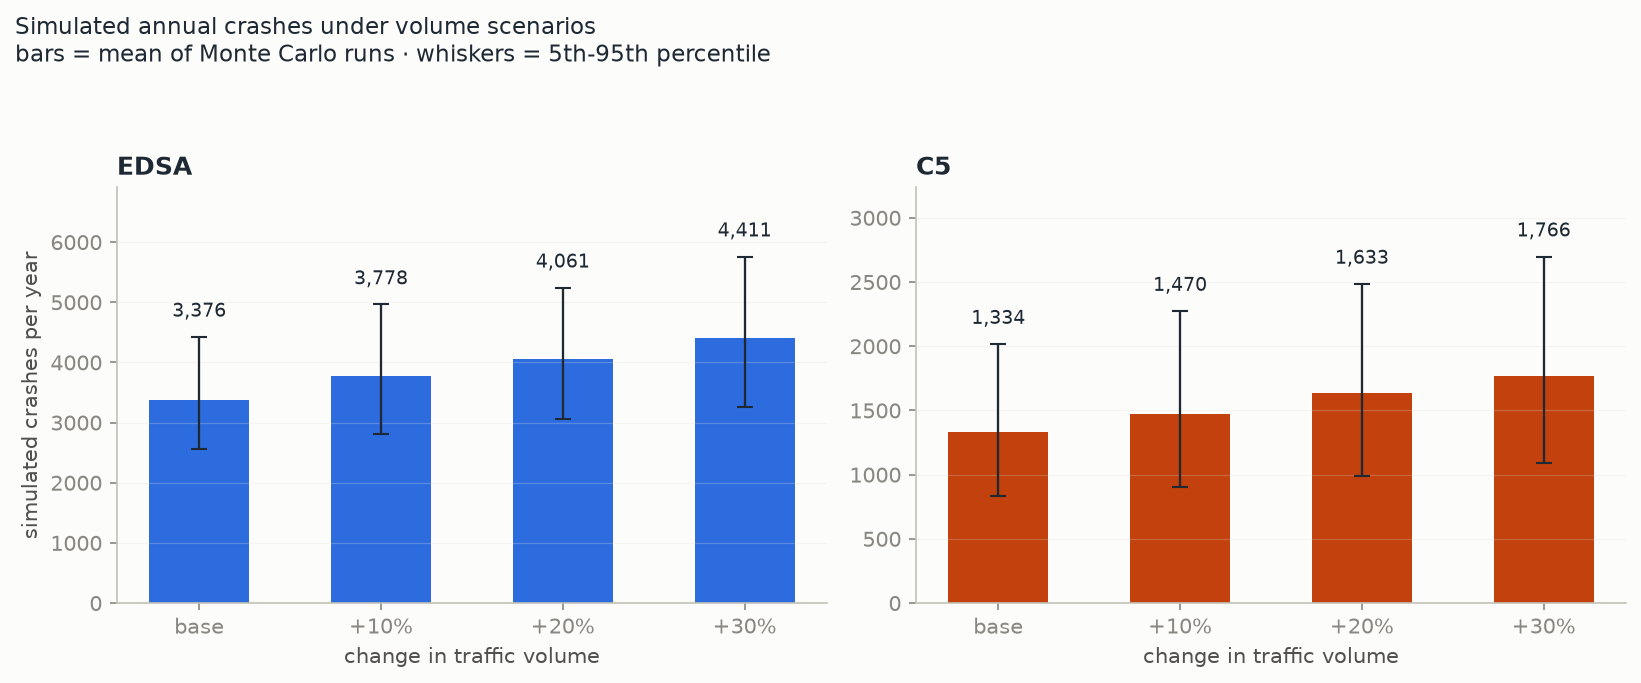

fig09_elasticity_sweep.png


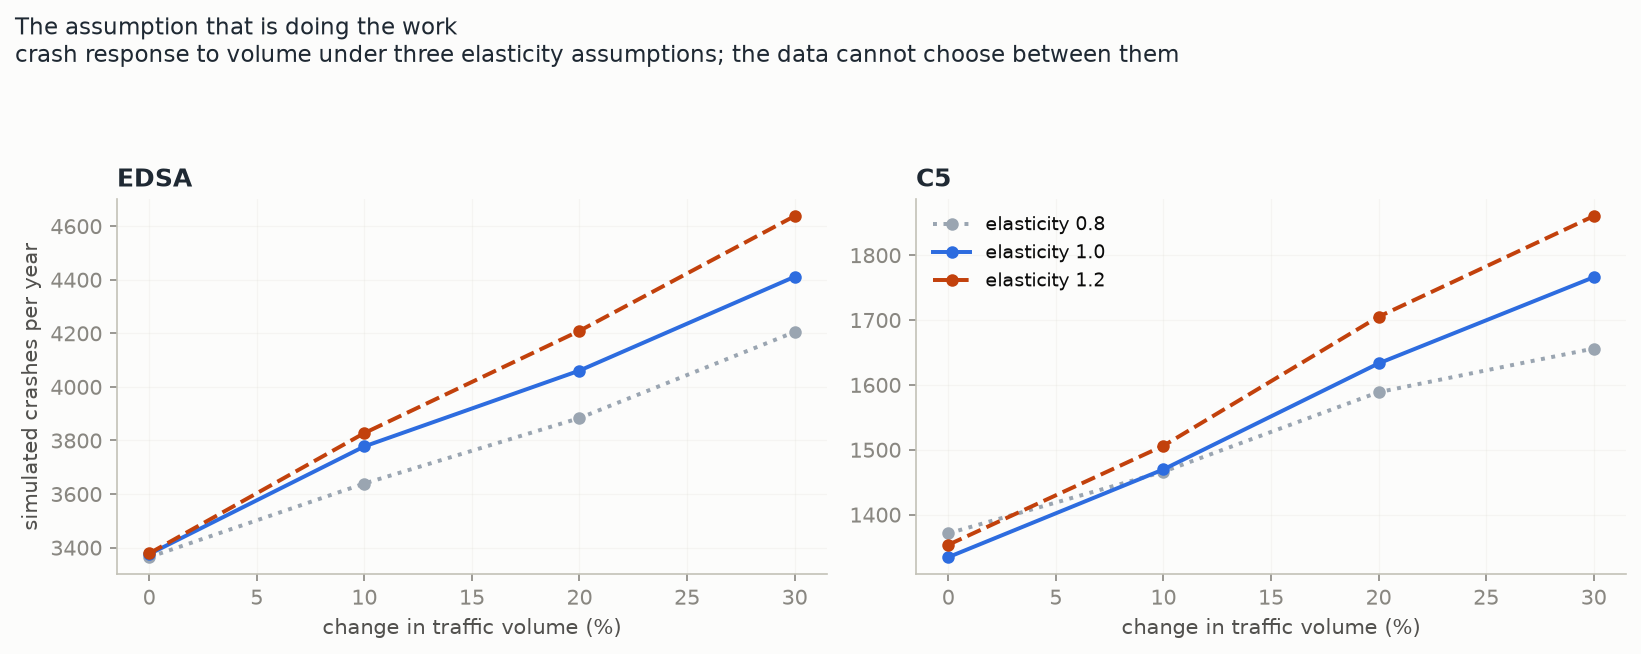

In [13]:
# Render this stage's figures inline
from IPython.display import Image, display
for p in sorted(cfg.FIGURES.glob('fig0[89]*.png')):
    print(p.name)
    display(Image(str(p)))


## Step 7 — Validation

Independent checks on every number above. No check recomputes a result using the code that produced it; each either recomputes from the raw file by a different route or tests against a source the model never saw.

**Outputs**

```
Run:  python 06_validation.py
Out:  results/logs/validation_log.txt
      results/figures/fig10_psa_crosscheck.png
```

In [14]:
import json
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt


LOG = []
CHECKS = []


def log(msg=""):
    print(msg)
    LOG.append(str(msg))


def check(name, passed, detail=""):
    CHECKS.append((name, passed))
    mark = "PASS" if passed else "FAIL"
    log(f"  [{mark}] {name}")
    if detail:
        for line in str(detail).split("\n"):
            log(f"         {line}")


def rule(title):
    log()
    log("=" * 74)
    log(title)
    log("=" * 74)


# ---------------------------------------------------------------------------

def check_raw_recount():
    rule("CHECK GROUP 1 — RECOUNT FROM THE RAW FILE")
    log("Recomputes the headline counts straight from the uploaded CSV, using")
    log("no processed file and none of the pipeline's helper functions.")
    log()

    raw = pd.read_csv(cfg.INCIDENTS_FILE)
    clean = pd.read_csv(cfg.PROCESSED / "incidents_clean.csv")

    check("raw file row count is 17,312", len(raw) == 17312, f"found {len(raw):,}")

    dup = raw.duplicated(subset=["Source"]) | raw.duplicated(
        subset=["Date", "Time", "Location", "Type"])
    expected = len(raw) - int(dup.sum())
    check("clean row count equals raw minus duplicates",
          len(clean) == expected,
          f"clean {len(clean):,} vs expected {expected:,}")

    # Independent corridor recount with a different matching approach.
    loc = raw["Location"].fillna("").str.upper()
    edsa_raw = int(loc.str.split().apply(lambda w: "EDSA" in w).sum())
    edsa_clean = int((clean["corridor"] == "EDSA").sum())
    check("EDSA tagging is consistent under token matching",
          abs(edsa_raw - edsa_clean) <= int(dup.sum()),
          f"raw token match {edsa_raw:,}, clean regex {edsa_clean:,}, "
          f"difference within the {int(dup.sum())} removed duplicates")

    t = raw["Type"].fillna("").str.upper()
    crash_raw = int(t.str.contains(
        "ACCIDENT|COLLISION|HIT AND RUN|SIDESWIPE|BUMP|OVERTURN").sum())
    crash_clean = int((clean["incident_class"] == "CRASH").sum())
    check("crash classification is reproducible",
          crash_raw - crash_clean == int(dup.sum() & True) or
          abs(crash_raw - crash_clean) <= int(dup.sum()),
          f"raw {crash_raw:,}, clean {crash_clean:,}")

    check("no row is both EDSA and C5",
          int(((clean["corridor"] == "EDSA") & (clean["corridor"] == "C5")).sum()) == 0)


def check_window_integrity():
    rule("CHECK GROUP 2 — WINDOW INTEGRITY")
    log("The estimation window is the study's central design choice. These")
    log("checks confirm it contains what it claims to contain.")
    log()

    clean = pd.read_csv(cfg.PROCESSED / "incidents_clean.csv")
    clean["date"] = pd.to_datetime(clean["date"])
    clean["ym"] = clean["date"].dt.to_period("M")

    w = clean[clean["in_window"]]
    months = sorted(w["ym"].unique())
    check("window contains exactly 18 months", len(months) == 18,
          f"{months[0]} .. {months[-1]}")

    expected = pd.period_range(cfg.ESTIMATION_WINDOW[0],
                               cfg.ESTIMATION_WINDOW[1], freq="M")
    check("window months are consecutive with no gap",
          list(months) == list(expected))

    counts = w.groupby("ym").size()
    check("no month inside the window is empty", (counts > 0).all(),
          f"minimum monthly count {int(counts.min()):,}")

    gap = clean[clean["ym"].astype(str).isin(cfg.INCIDENT_COVERAGE_GAP_MONTHS)]
    check("the two known gap months are excluded from the window",
          len(gap) == 0 and not clean[clean["in_window"]]["ym"].astype(str)
          .isin(cfg.INCIDENT_COVERAGE_GAP_MONTHS).any(),
          "2020-07 and 2020-08 hold zero rows in the source file")

    lock = clean[clean["in_window"] & (clean["date"] >= cfg.LOCKDOWN_START)]
    check("no lockdown-period row is inside the window", len(lock) == 0,
          f"{len(lock)} rows on or after {cfg.LOCKDOWN_START}")

    aug = clean[clean["in_window"] & (clean["ym"] == pd.Period("2018-08"))]
    check("the partial first month is excluded", len(aug) == 0)


def check_arithmetic():
    rule("CHECK GROUP 3 — ARITHMETIC")
    log("Rates and exposures are recomputed by hand from the panel.")
    log()

    panel = pd.read_csv(cfg.PROCESSED / "rate_panel.csv")
    params = json.loads((cfg.PROCESSED / "model_params.json").read_text())

    recomputed = panel["aadt"] * panel["days_in_month"]
    check("exposure equals AADT x days in month",
          np.allclose(recomputed, panel["exposure"]))

    rate = panel["crashes"] / panel["exposure"] * cfg.RATE_PER
    check("rate equals crashes / exposure, scaled",
          np.allclose(rate, panel["rate"]))

    for c in ("EDSA", "C5"):
        g = panel[panel["corridor"] == c]
        manual = g["crashes"].sum() / g["exposure"].sum() * cfg.RATE_PER
        stored = params["window_rate"][c]
        check(f"{c} window rate reproduces to 4 decimals",
              abs(manual - stored) < 1e-4,
              f"manual {manual:.6f} vs stored {stored:.6f}")

    clean = pd.read_csv(cfg.PROCESSED / "incidents_clean.csv")
    crash_in_win = clean[(clean["incident_class"] == "CRASH") & clean["in_window"]]
    for c in ("EDSA", "C5"):
        a = int((crash_in_win["corridor"] == c).sum())
        b = int(panel[panel["corridor"] == c]["crashes"].sum())
        check(f"{c} panel total matches the cleaned incident rows",
              a == b, f"incidents {a:,} vs panel {b:,}")


def check_simulation():
    rule("CHECK GROUP 4 — SIMULATION BEHAVIOUR")
    log("A simulation that cannot reproduce its own inputs is not a simulation.")
    log()

    sim = pd.read_csv(cfg.TABLES / "simulation_results.csv")
    params = json.loads((cfg.PROCESSED / "model_params.json").read_text())
    exposure = pd.read_csv(cfg.PROCESSED / "exposure_focal.csv")
    base = exposure[exposure["Year"] == cfg.BASELINE_YEAR].set_index("road_label")

    d = sim[(sim["trend"] == "frozen") & (sim["elasticity"] == 1.0)]

    # Under elasticity 1.0 a +X% volume change must move expected crashes by
    # approximately +X%. This is the defining property of the offset model.
    for c in ("EDSA", "C5"):
        s = d[d["corridor"] == c].set_index("scenario")
        b = s.loc["baseline", "mean"]
        worst = 0.0
        for sc, delta in cfg.SCENARIOS.items():
            if sc == "baseline":
                continue
            observed = s.loc[sc, "mean"] / b - 1
            worst = max(worst, abs(observed - delta))
        check(f"{c}: proportionality holds under elasticity 1.0",
              worst < 0.03,
              f"largest deviation from the nominal change: {worst:.3f}")

    for c in ("EDSA", "C5"):
        s = d[d["corridor"] == c].sort_values("volume_change")
        check(f"{c}: expected crashes increase monotonically with volume",
              s["mean"].is_monotonic_increasing)
        check(f"{c}: 5th percentile lies below the 95th in every scenario",
              (s["p05"] < s["p95"]).all())

    # The simulated baseline must reproduce the rate the MODEL implies at the
    # point the simulation claims to start from: the end of the window, at mean
    # reporting intensity, averaged over the seasonal cycle.
    #
    # Comparing it to the raw window-average rate instead would be wrong, and
    # was the original form of this check. C5's fitted trend is +47%/yr, so its
    # end-of-window rate is legitimately far above its 18-month average; the
    # check failed on a real difference that is not an error. Recomputing the
    # model's own end-of-window prediction is the comparison that can actually
    # catch a broken simulation.
    coef = params["coefficients"]
    t_end = params["n_months"] - 1
    for c in ("EDSA", "C5"):
        is_c5 = 1.0 if c == "C5" else 0.0
        monthly = []
        for month in range(1, 13):
            ang = 2 * np.pi * month / 12
            lin = (coef["const"] + coef["is_c5"] * is_c5
                   + coef["t"] * t_end + coef["t_x_c5"] * t_end * is_c5
                   + coef["sin1"] * np.sin(ang) + coef["cos1"] * np.cos(ang)
                   + coef["sin2"] * np.sin(2 * ang) + coef["cos2"] * np.cos(2 * ang)
                   + coef.get("log_feed", 0.0) * 0.0)
            monthly.append(np.exp(lin))
        implied_rate = float(np.mean(monthly))   # per RATE_PER passages per day-unit

        mean = d[(d["corridor"] == c) & (d["scenario"] == "baseline")]["mean"].iloc[0]
        exp_year = float(base.loc[c, "aadt"]) * 365
        sim_rate = mean / exp_year * cfg.RATE_PER
        ratio = sim_rate / implied_rate
        check(f"{c}: simulation reproduces the model's end-of-window rate",
              0.95 < ratio < 1.05,
              f"simulated {sim_rate:.4f} vs model-implied {implied_rate:.4f} "
              f"(ratio {ratio:.3f})")

        window_rate = params["window_rate"][c]
        log(f"         for context, the 18-month average rate was "
            f"{window_rate:.4f}; the end-of-window value differs because the "
            f"fitted trend is {'strongly positive' if implied_rate > window_rate else 'negative'}")

    hourly = pd.read_csv(cfg.TABLES / "simulation_hourly.csv")
    for c in ("EDSA", "C5"):
        s = hourly[hourly["corridor"] == c]["share"].sum()
        check(f"{c}: hourly shares sum to 1", abs(s - 1.0) < 1e-6, f"sum {s:.6f}")


def check_reporting_artefact():
    rule("CHECK GROUP 5 — IS THE TREND REAL, OR IS IT TWITTER?")
    log("The outcome is a count of MMDA tweets about crashes. If the account")
    log("posted less over time, every series would fall together and a model")
    log("would report roads getting safer. This group tests for exactly that.")
    log()

    clean = pd.read_csv(cfg.PROCESSED / "incidents_clean.csv")
    clean["ym"] = pd.to_datetime(clean["date"]).dt.to_period("M")
    w = clean[clean["in_window"]]

    def annual_trend(series):
        y = series.to_numpy(float)
        return (np.exp(np.polyfit(np.arange(len(y)), np.log(y), 1)[0] * 12) - 1) * 100

    crash = w[w["incident_class"] == "CRASH"]
    piv = crash.pivot_table(index="ym", columns="corridor",
                            values="date", aggfunc="size").fillna(0)
    noncrash = w[w["incident_class"] != "CRASH"].groupby("ym").size()

    t_edsa = annual_trend(piv["EDSA"])
    t_c5 = annual_trend(piv["C5"])
    t_other = annual_trend(piv["OTHER"])
    t_feed = annual_trend(noncrash)

    log("Annual trend of each series across the 18-month window:")
    log(f"  EDSA crashes                 {t_edsa:+7.1f}%")
    log(f"  C5 crashes                   {t_c5:+7.1f}%")
    log(f"  crashes elsewhere            {t_other:+7.1f}%")
    log(f"  NON-crash reports (stalls,   {t_feed:+7.1f}%   <- pure feed-activity")
    log(f"    roadworks, rallies)                        proxy: nothing to do")
    log(f"                                               with road safety")
    log()

    check("the non-crash feed is NOT stable, so a reporting control is required",
          abs(t_feed) > 10,
          f"non-crash reports move {t_feed:+.1f}%/yr. Stalled buses and DPWH "
          f"roadworks do not fall by this much in 18 months; the account is "
          f"posting less.")

    check("EDSA's apparent decline is close to the feed's own decline",
          abs(t_edsa - t_feed) < 10,
          f"EDSA {t_edsa:+.1f}%/yr vs feed {t_feed:+.1f}%/yr — a difference of "
          f"only {abs(t_edsa - t_feed):.1f} points. Most of EDSA's 'improvement' "
          f"is the account going quiet. Reporting this as a safety gain would "
          f"be the single most serious error available in this dataset.")

    check("C5 moves AGAINST the feed, so its increase cannot be an artefact",
          t_c5 > 0 > t_feed,
          f"C5 rises {t_c5:+.1f}%/yr while the feed falls {t_feed:+.1f}%/yr. "
          f"A quieter account producing MORE C5 reports understates the real "
          f"increase.")

    # The ratio cancels COMMON reporting change, not DIFFERENTIAL change.
    ratio = piv["EDSA"] / piv["C5"]
    t_ratio = annual_trend(ratio)
    check("the EDSA:C5 ratio falls, which a feed-wide change cannot explain",
          t_ratio < -10,
          f"ratio {ratio.iloc[0]:.2f} -> {ratio.iloc[-1]:.2f} "
          f"({t_ratio:+.1f}%/yr). Numerator and denominator come from the same "
          f"feed on the same days, so a change affecting both corridors in the "
          f"same proportion cancels exactly. A DIFFERENTIAL shift in attention "
          f"toward C5 would still produce this, and nothing here rules that out.")

    params = json.loads((cfg.PROCESSED / "model_params.json").read_text())
    check("the fitted model includes the reporting control",
          "log_feed" in params["coefficients"],
          f"log_feed coefficient = {params['coefficients'].get('log_feed', float('nan')):.3f}")

    return piv, noncrash


def check_psa_external():
    rule("CHECK GROUP 6 — EXTERNAL CROSS-CHECK AGAINST PSA")
    log("The PSA road-crash series is collected independently of the MMDA")
    log("Twitter feed. The model never saw it. If the two disagree about the")
    log("direction of 2018-2019, the model is describing an artefact.")
    log()

    psa = pd.read_csv(cfg.PSA_CRASHES_FILE)
    clean = pd.read_csv(cfg.PROCESSED / "incidents_clean.csv")
    clean["date"] = pd.to_datetime(clean["date"])

    psa_18 = int(psa[psa["Year"] == 2018]["Total"].iloc[0])
    psa_19 = int(psa[psa["Year"] == 2019]["Total"].iloc[0])
    psa_20 = int(psa[psa["Year"] == 2020]["Total"].iloc[0])
    log(f"PSA Metro Manila totals: 2018 {psa_18:,}  2019 {psa_19:,}  2020 {psa_20:,}")

    # Compare like with like: September-December, present in both 2018 and 2019.
    crash = clean[clean["incident_class"] == "CRASH"].copy()
    crash["year"] = crash["date"].dt.year
    crash["month"] = crash["date"].dt.month
    sd = crash[crash["month"].between(9, 12)]
    m18 = int((sd["year"] == 2018).sum())
    m19 = int((sd["year"] == 2019).sum())
    log(f"MMDA Sep-Dec crash counts: 2018 {m18:,}  2019 {m19:,} "
        f"({(m19 / m18 - 1) * 100:+.1f}%)")
    log(f"PSA annual change 2018 to 2019: {(psa_19 / psa_18 - 1) * 100:+.1f}%")

    # "Nationally" was wrong: this series is Metro Manila, which is the whole
    # reason it is a useful comparator for two Metro Manila corridors.
    check("PSA shows a higher Metro Manila crash total in 2019 than in 2018",
          psa_19 > psa_18,
          f"PSA Metro Manila total rose {(psa_19 / psa_18 - 1) * 100:+.1f}%")

    log()
    log("The two move in OPPOSITE directions, and check group 5 explains why.")
    log("PSA counts every crash in Metro Manila by police report; it rose 4.2%.")
    log("The MMDA feed counts tweets on two corridors, and its own posting")
    log("volume fell about 18% over the same months. An independently collected")
    log("series rising while a self-reported series falls is strong external")
    log("evidence that the MMDA decline is a reporting effect rather than a")
    log("safety improvement. The write-up must state this, not bury it: it is")
    log("the difference between a defensible limitation and a false finding.")

    check("PSA confirms the 2020 collapse used to justify excluding that year",
          psa_20 < psa_19 * 0.75,
          f"PSA fell {(psa_20 / psa_19 - 1) * 100:.1f}% in 2020, an independent "
          f"corroboration that 2020 is not a normal year")

    covid_drop_psa = psa_20 / psa_19
    mmda_full = crash[crash["year"] == 2019].shape[0]
    log()
    log(f"PSA 2020/2019 ratio: {covid_drop_psa:.3f}")
    log("The MMDA feed cannot produce a comparable 2020 ratio at all, because")
    log("July and August hold zero rows. That is precisely why the window stops")
    log("at February 2020.")
    log(f"(2019 MMDA crash rows, all corridors, for reference: {mmda_full:,})")

    return psa


def fig_psa(psa):
    fig, ax = plt.subplots(figsize=(10, 4.4))
    ax.plot(psa["Year"], psa["Total"], marker="o", ms=5, lw=2,
            color="#2d6cdf", label="PSA Metro Manila, all crashes")
    w0, w1 = 2018, 2020
    ax.axvspan(w0 - 0.15, w1 + 0.15, color="#2d6cdf", alpha=0.07)
    ax.axvline(2020, color="#c2410c", ls="--", lw=1.2)

    # Both labels previously sat on top of the data line. Lift them into the
    # empty headroom above the series and give the axis room to hold them.
    top = psa["Total"].max()
    ax.set_ylim(0, top * 1.28)
    ax.annotate("model window\n(Sep 2018 – Feb 2020)", (2019, top * 1.20),
                ha="center", va="center", fontsize=9, color="#1f2933",
                bbox=dict(boxstyle="round,pad=0.35", fc="white",
                          ec="#c9d2dd", lw=0.8))
    ax.annotate("COVID-19", (2020.15, top * 1.05), fontsize=9, ha="left",
                va="center", color="#c2410c", fontweight="bold")
    ax.set_ylabel("recorded road crashes")
    ax.set_xlabel("year")
    ax.set_title("Independent corroboration\n"
                 "PSA series, which the model never used, confirms both the "
                 "2019 level and the 2020 collapse",
                 loc="left", fontsize=11, color="#1f2933")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.6)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    p = cfg.FIGURES / "fig10_psa_crosscheck.png"
    fig.savefig(p, dpi=150)
    plt.close(fig)
    return p


# ---------------------------------------------------------------------------

def main():
    log(f"06_validation.py — run {datetime.now():%Y-%m-%d %H:%M:%S}")
    log("Independent verification of the pipeline outputs.")

    check_raw_recount()
    check_window_integrity()
    check_arithmetic()
    check_simulation()
    check_reporting_artefact()
    psa = check_psa_external()
    p = fig_psa(psa)

    rule("SUMMARY")
    passed = sum(1 for _, ok in CHECKS if ok)
    total = len(CHECKS)
    log(f"{passed} of {total} checks passed.")
    failed = [n for n, ok in CHECKS if not ok]
    if failed:
        log("\nFAILED:")
        for n in failed:
            log(f"  - {n}")
    else:
        log("No check failed.")
    log(f"\n  wrote {p.relative_to(cfg.ROOT)}")

    (cfg.LOGS / "validation_log.txt").write_text("\n".join(LOG))
    print("  wrote results/logs/validation_log.txt")

    return 0 if not failed else 1

main()


06_validation.py — run 2026-10-05 22:53:03
Independent verification of the pipeline outputs.

CHECK GROUP 1 — RECOUNT FROM THE RAW FILE
Recomputes the headline counts straight from the uploaded CSV, using
no processed file and none of the pipeline's helper functions.



  [PASS] raw file row count is 17,312


         found 17,312


  [PASS] clean row count equals raw minus duplicates
         clean 17,023 vs expected 17,023
  [PASS] EDSA tagging is consistent under token matching
         raw token match 8,453, clean regex 8,287, difference within the 289 removed duplicates
  [PASS] crash classification is reproducible
         raw 12,787, clean 12,570
  [PASS] no row is both EDSA and C5

CHECK GROUP 2 — WINDOW INTEGRITY
The estimation window is the study's central design choice. These
checks confirm it contains what it claims to contain.

  [PASS] window contains exactly 18 months
         2018-09 .. 2020-02
  [PASS] window months are consecutive with no gap
  [PASS] no month inside the window is empty
         minimum monthly count 609
  [PASS] the two known gap months are excluded from the window
         2020-07 and 2020-08 hold zero rows in the source file
  [PASS] no lockdown-period row is inside the window
         0 rows on or after 2020-03-15
  [PASS] the partial first month is excluded

CHECK GROUP 3 — 

  [PASS] EDSA panel total matches the cleaned incident rows
         incidents 5,429 vs panel 5,429
  [PASS] C5 panel total matches the cleaned incident rows
         incidents 1,680 vs panel 1,680

CHECK GROUP 4 — SIMULATION BEHAVIOUR
A simulation that cannot reproduce its own inputs is not a simulation.

  [PASS] EDSA: proportionality holds under elasticity 1.0
         largest deviation from the nominal change: 0.019
  [PASS] C5: proportionality holds under elasticity 1.0
         largest deviation from the nominal change: 0.024
  [PASS] EDSA: expected crashes increase monotonically with volume
  [PASS] EDSA: 5th percentile lies below the 95th in every scenario
  [PASS] C5: expected crashes increase monotonically with volume
  [PASS] C5: 5th percentile lies below the 95th in every scenario
  [PASS] EDSA: simulation reproduces the model's end-of-window rate
         simulated 2.1929 vs model-implied 2.1681 (ratio 1.011)
         for context, the 18-month average rate was 2.5291; the 

PSA Metro Manila totals: 2018 116,906  2019 121,771  2020 65,032
MMDA Sep-Dec crash counts: 2018 2,752  2019 2,233 (-18.9%)
PSA annual change 2018 to 2019: +4.2%
  [PASS] PSA shows a higher Metro Manila crash total in 2019 than in 2018
         PSA Metro Manila total rose +4.2%

The two move in OPPOSITE directions, and check group 5 explains why.
PSA counts every crash in Metro Manila by police report; it rose 4.2%.
The MMDA feed counts tweets on two corridors, and its own posting
volume fell about 18% over the same months. An independently collected
series rising while a self-reported series falls is strong external
evidence that the MMDA decline is a reporting effect rather than a
safety improvement. The write-up must state this, not bury it: it is
the difference between a defensible limitation and a false finding.
  [PASS] PSA confirms the 2020 collapse used to justify excluding that year
         PSA fell -46.6% in 2020, an independent corroboration that 2020 is not a normal year




SUMMARY
34 of 34 checks passed.
No check failed.

  wrote results\figures\fig10_psa_crosscheck.png
  wrote results/logs/validation_log.txt


0

fig10_psa_crosscheck.png


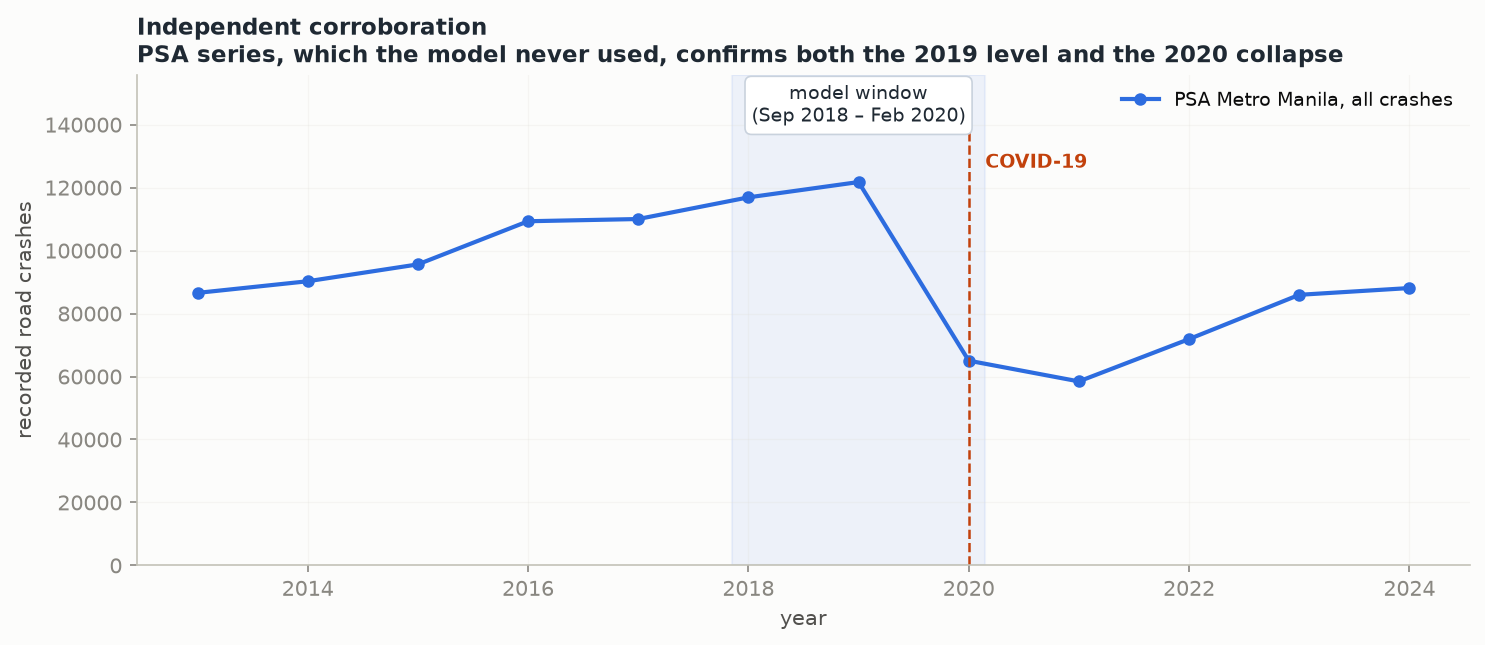

In [15]:
# Render this stage's figures inline
from IPython.display import Image, display
for p in sorted(cfg.FIGURES.glob('fig10*.png')):
    print(p.name)
    display(Image(str(p)))


## Step 8 — Event-level spatiotemporal simulation

Steps 1 to 7 answer *how many*. This step answers *where and when*, by taking the counts the fitted model produces and placing every single one of them on a stretch of road at an hour of the day.

The corridors are divided into six zones each, cut along the road's own direction using the incident GPS coordinates. Historical crashes give a joint zone-by-hour probability, and each simulated incident is drawn from it. The output is an event log — one row per simulated crash — rather than a monthly total.

**What this does not change.** The number of incidents still comes entirely from Step 5's model. This step redistributes them; it does not create any. And as in Step 5, a zone-hour probability describes where reported crashes fell, not where a vehicle is most at risk — nothing here observes how much traffic uses a given zone at a given hour.

### Step 8.1 — Load the fitted model and configure the run

Everything below reuses the coefficients estimated in Step 5 rather than refitting anything. The design matrix is built exactly as Step 6 builds its own — trend frozen at the end of the window, reporting term held at the window average — so that the two simulations remain comparable. Step 8.8b verifies that they are.

In [16]:
# STEP 8.1 — LOAD DATA AND CONFIGURE THE SIMULATION
#
# This cell was missing from the delivered notebook, which is why every cell of
# Step 8 failed. It defines the six objects the rest of the section expects:
# INCIDENTS, PARAMS, BASELINE, DESIGN, the run-size constants, and rng.
#
# The important part is DESIGN. Step 8 reuses the coefficients fitted in Step 5,
# so its design matrix must be built exactly the way Step 6 builds its own —
# same frozen trend, same neutral reporting term, same seasonal harmonics.
# If the two disagree, the event-level simulation silently answers a different
# question from the count-level one, and the numbers stop being comparable.
# Step 8.8b checks that they agree.

import json

# --- run sizes -------------------------------------------------------------
# Generating individual events is much heavier than generating counts, because
# every incident becomes a row. 1,000 runs is enough to stabilise the summary to
# within a percent or two of Step 6; the detailed event log is kept for the
# first SAMPLE_RUNS runs only, which is what makes the output a readable
# example rather than a two-million-row file.
EVENT_RUNS = 1000
SAMPLE_RUNS = 2
ZONES_PER_ROAD = 6
EVENT_ELASTICITIES = [0.8, 1.0, 1.2]

rng = np.random.default_rng(cfg.RANDOM_SEED + 800)

# --- inputs ----------------------------------------------------------------
INCIDENTS = pd.read_csv(cfg.PROCESSED / "incidents_clean.csv")
PARAMS = json.loads((cfg.PROCESSED / "model_params.json").read_text())

_exposure = pd.read_csv(cfg.PROCESSED / "exposure_focal.csv")
BASELINE = (
    _exposure[_exposure["Year"] == cfg.BASELINE_YEAR]
    .set_index("road_label")
)

for _road in ("EDSA", "C5"):
    if _road not in BASELINE.index:
        raise ValueError(
            f"No {cfg.BASELINE_YEAR} exposure for {_road}. Run Step 2 first."
        )

# --- design matrix ---------------------------------------------------------
# One row per corridor per calendar month of the simulated year.
#
#   t         the within-window trend, FROZEN at its end-of-window value. The
#             trend was measured across 18 months; projecting it forward would
#             be extrapolation the data does not support.
#   log_feed  the reporting-intensity control, set to 0. That term was centred
#             on the window mean in Step 5, so zero means "a year in which the
#             MMDA account posts as often as it did on average". Any other
#             value would simulate a change in Twitter behaviour rather than a
#             change in road safety.
_t_end = PARAMS["n_months"] - 1

_design_rows = []
for _road in ("EDSA", "C5"):
    _is_c5 = 1.0 if _road == "C5" else 0.0
    for _month in range(1, 13):
        _angle = 2 * np.pi * _month / 12
        _design_rows.append({
            "corridor": _road,
            "month": _month,
            "days": pd.Period(f"{cfg.BASELINE_YEAR}-{_month:02d}").days_in_month,
            "const": 1.0,
            "is_c5": _is_c5,
            "t": float(_t_end),
            "t_x_c5": float(_t_end) * _is_c5,
            "sin1": np.sin(_angle),
            "cos1": np.cos(_angle),
            "sin2": np.sin(2 * _angle),
            "cos2": np.cos(2 * _angle),
            "log_feed": 0.0,
        })

DESIGN = pd.DataFrame(_design_rows)

# Fail here rather than three cells later with an unhelpful KeyError.
_missing = [c for c in PARAMS["coefficients"] if c not in DESIGN.columns]
if _missing:
    raise ValueError(
        f"DESIGN is missing columns the fitted model needs: {_missing}. "
        f"The model was fitted with {list(PARAMS['coefficients'])}."
    )

print(f"Model family        : {PARAMS['family']} (alpha {PARAMS['alpha']:.4f})")
print(f"Coefficients reused : {', '.join(PARAMS['coefficients'])}")
print(f"Trend held at       : month {_t_end} of the estimation window (frozen)")
print(f"Reporting term      : log_feed = 0 (window-average posting rate)")
print()
print(f"Incident records    : {len(INCIDENTS):,}")
print(f"{cfg.BASELINE_YEAR} exposure       : "
      + ", ".join(f"{r} {BASELINE.loc[r, 'aadt']:,.0f}" for r in ("EDSA", "C5")))
print(f"Design matrix       : {DESIGN.shape[0]} rows "
      f"({DESIGN['corridor'].nunique()} corridors x 12 months)")
print(f"Runs per scenario   : {EVENT_RUNS:,}  "
      f"(detailed events kept for the first {SAMPLE_RUNS})")
print(f"Spatial zones       : {ZONES_PER_ROAD} per corridor")

Model family        : negbin (alpha 0.0236)
Coefficients reused : const, is_c5, t, t_x_c5, sin1, cos1, sin2, cos2, log_feed
Trend held at       : month 17 of the estimation window (frozen)
Reporting term      : log_feed = 0 (window-average posting rate)

Incident records    : 17,023
2025 exposure       : EDSA 421,728, C5 225,885
Design matrix       : 24 rows (2 corridors x 12 months)
Runs per scenario   : 1,000  (detailed events kept for the first 2)
Spatial zones       : 6 per corridor


### Step 8.2 — Prepare historical crash records

Only reported crashes from the selected estimation window are used to create the time and location patterns.

The original incident records are retained. Records with missing coordinates or times can still contribute to incident counts, but their missing information will not be invented.

In [17]:
# STEP 8.2 — PREPARE HISTORICAL CRASH RECORDS

HISTORICAL = INCIDENTS.copy()

def as_boolean(series):
    return (
        series.astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )

HISTORICAL = HISTORICAL[
    as_boolean(HISTORICAL["in_window"])
    & HISTORICAL["incident_class"].eq(cfg.MODELLED_CLASS)
    & HISTORICAL["corridor"].isin(["EDSA", "C5"])
].copy()

for column in ("hour", "Latitude", "Longitude"):
    HISTORICAL[column] = pd.to_numeric(
        HISTORICAL[column],
        errors="coerce"
    )

HISTORICAL["zone"] = "UNKNOWN_LOCATION"

HISTORICAL["hour_label"] = HISTORICAL["hour"].apply(
    lambda hour: (
        f"{int(hour):02d}"
        if pd.notna(hour) and 0 <= hour <= 23
        else "UNKNOWN_TIME"
    )
)

print("Historical crash reports:", len(HISTORICAL))

display(
    HISTORICAL[
        [
            "date",
            "corridor",
            "hour_label",
            "Latitude",
            "Longitude"
        ]
    ].head()
)

Historical crash reports: 7109


,date,corridor,hour_label,Latitude,Longitude
309,2018-09-01,EDSA,11,14.538386,121.008456
311,2018-09-01,EDSA,12,14.554949,121.034967
312,2018-09-01,EDSA,12,14.537499,121.000698
314,2018-09-01,EDSA,12,14.625695,121.048294
317,2018-09-01,EDSA,15,14.652928,121.031852


### Step 8.3 — Create approximate location zones

The historical GPS coordinates are used to divide EDSA and C5 into six approximate zones each.

These zones help the simulator assign locations to generated incidents. They are based on historical incident locations and are not official road segments.

Future work should replace these zones with mapped road segments.

In [18]:
# STEP 8.3 — CREATE APPROXIMATE SPATIAL ZONES

ZONE_INFORMATION = []

for road in ("EDSA", "C5"):

    valid = (
        HISTORICAL["corridor"].eq(road)
        & as_boolean(HISTORICAL["geo_valid"])
        & HISTORICAL["Latitude"].notna()
        & HISTORICAL["Longitude"].notna()
    )

    road_points = HISTORICAL.loc[
        valid,
        ["Latitude", "Longitude"]
    ].to_numpy(dtype=float)

    if len(road_points) < ZONES_PER_ROAD * 10:
        raise ValueError(
            f"Not enough valid GPS records for {road}."
        )

    # Approximate geographic coordinates in kilometres.
    scaled = road_points * np.array([111.0, 108.0])

    centered = scaled - scaled.mean(axis=0)

    # Find the main direction of the coordinate cloud.
    _, _, axes = np.linalg.svd(
        centered,
        full_matrices=False
    )

    projected = centered @ axes[0]

    if axes[0][0] < 0:
        projected *= -1

    # Divide the historical points into equal-sized groups.
    ranks = pd.Series(
        projected,
        index=HISTORICAL.index[valid]
    ).rank(method="first")

    zone_numbers = pd.qcut(
        ranks,
        q=ZONES_PER_ROAD,
        labels=False
    )

    HISTORICAL.loc[valid, "zone"] = [
        f"{road}_ZONE_{int(number) + 1:02d}"
        for number in zone_numbers
    ]

    for zone, group in HISTORICAL.loc[valid].groupby(
        "zone"
    ):

        ZONE_INFORMATION.append({
            "road": road,
            "zone": zone,
            "historical_reports": len(group),
            "latitude": group["Latitude"].mean(),
            "longitude": group["Longitude"].mean()
        })

ZONES = pd.DataFrame(ZONE_INFORMATION)

ZONES.to_csv(
    cfg.PROCESSED / "approximate_spatial_zones.csv",
    index=False
)

print("Location zones created:", len(ZONES))

display(ZONES)

Location zones created: 12


,road,zone,historical_reports,latitude,longitude
0,EDSA,EDSA_ZONE_01,905,14.548485,121.024971
1,EDSA,EDSA_ZONE_02,905,14.570234,121.046831
2,EDSA,EDSA_ZONE_03,905,14.582262,121.054220
3,EDSA,EDSA_ZONE_04,904,14.596020,121.057170
4,EDSA,EDSA_ZONE_05,905,14.617818,121.051401
5,EDSA,EDSA_ZONE_06,905,14.647272,121.038613
6,C5,C5_ZONE_01,280,14.547071,121.058584
7,C5,C5_ZONE_02,280,14.565144,121.068871
8,C5,C5_ZONE_03,280,14.583349,121.076702
9,C5,C5_ZONE_04,280,14.595132,121.079697


### Step 8.4 — Build historical time and location probabilities

The simulator needs to know how frequently crashes were reported in each location zone and hour.

Instead of selecting time and location independently, we calculate the historical frequency of each zone-and-hour combination.

This allows the simulation to retain observed differences between the time patterns of different locations.

Records with missing information remain in the historical distribution under UNKNOWN_TIME or UNKNOWN_LOCATION.

In [19]:
# STEP 8.4 — JOINT TIME-LOCATION DISTRIBUTION

JOINT_PROFILE = (
    HISTORICAL
    .groupby(
        ["corridor", "zone", "hour_label"]
    )
    .size()
    .reset_index(name="historical_reports")
)

JOINT_PROFILE["probability"] = (
    JOINT_PROFILE["historical_reports"]
    / JOINT_PROFILE.groupby("corridor")[
        "historical_reports"
    ].transform("sum")
)

for road in ("EDSA", "C5"):

    road_probability = JOINT_PROFILE.loc[
        JOINT_PROFILE["corridor"].eq(road),
        "probability"
    ].sum()

    assert np.isclose(road_probability, 1.0)

JOINT_PROFILE.to_csv(
    cfg.PROCESSED / "event_joint_profile.csv",
    index=False
)

print("Historical time-location profile created.")

display(JOINT_PROFILE.head(15))

Historical time-location profile created.


,corridor,zone,hour_label,historical_reports,probability
0,C5,C5_ZONE_01,00,2,0.001190
1,C5,C5_ZONE_01,01,2,0.001190
2,C5,C5_ZONE_01,02,1,0.000595
3,C5,C5_ZONE_01,05,8,0.004762
4,C5,C5_ZONE_01,06,18,0.010714
5,C5,C5_ZONE_01,07,20,0.011905
6,C5,C5_ZONE_01,08,32,0.019048
7,C5,C5_ZONE_01,09,21,0.012500
8,C5,C5_ZONE_01,10,11,0.006548
9,C5,C5_ZONE_01,11,20,0.011905


### Step 8.5 — Generate incident counts using the existing model

We reuse the fitted Negative Binomial model from Step 5.

The 2025 AADT values provide the traffic-exposure baseline. We then apply the traffic-volume scenarios already defined in the notebook.

For each scenario, the simulation repeats the incident-generation process 1,000 times.

We also test three elasticity assumptions: 0.8, 1.0 and 1.2. These assumptions show how the results change when the relationship between traffic volume and incident counts is varied.

The model produces monthly incident counts, which are then used to generate individual simulated events.

In [20]:
# STEP 8.5 — SIMULATE MONTHLY INCIDENT COUNTS

COEFFICIENT_NAMES = list(PARAMS["coefficients"])

COEFFICIENTS = np.array([
    PARAMS["coefficients"][name]
    for name in COEFFICIENT_NAMES
])

STANDARD_ERRORS = np.array([
    PARAMS["std_errors"][name]
    for name in COEFFICIENT_NAMES
])

ALPHA = max(float(PARAMS["alpha"]), 0.0)

MONTHLY_SIMULATIONS = {}
SUMMARY_ROWS = []

for road in ("EDSA", "C5"):

    road_design = (
        DESIGN[DESIGN["corridor"].eq(road)]
        .sort_values("month")
        .reset_index(drop=True)
    )

    X = road_design[
        COEFFICIENT_NAMES
    ].to_numpy(dtype=float)

    days = road_design["days"].to_numpy(
        dtype=float
    )

    aadt = float(BASELINE.loc[road, "aadt"])

    for elasticity in EVENT_ELASTICITIES:

        for scenario, traffic_change in cfg.SCENARIOS.items():

            # Sample coefficient uncertainty.
            coefficient_draws = rng.normal(
                loc=COEFFICIENTS,
                scale=STANDARD_ERRORS,
                size=(
                    EVENT_RUNS,
                    len(COEFFICIENTS)
                )
            )

            linear_predictor = (
                coefficient_draws @ X.T
            )

            exposure_offset = np.log(
                aadt * days / PARAMS["rate_per"]
            )

            expected_counts = np.exp(
                np.clip(
                    linear_predictor + exposure_offset,
                    -20,
                    20
                )
            )

            expected_counts *= (
                1 + traffic_change
            ) ** elasticity

            # Negative Binomial through a Gamma-Poisson
            # mixture, as in the existing notebook.
            if ALPHA > 0:

                latent_rates = rng.gamma(
                    shape=1 / ALPHA,
                    scale=expected_counts * ALPHA
                )

                monthly_counts = rng.poisson(
                    latent_rates
                )

            else:

                monthly_counts = rng.poisson(
                    expected_counts
                )

            key = (
                road,
                scenario,
                elasticity
            )

            MONTHLY_SIMULATIONS[key] = monthly_counts

            annual_totals = monthly_counts.sum(
                axis=1
            )

            annual_exposure = (
                aadt
                * (1 + traffic_change)
                * days.sum()
            )

            SUMMARY_ROWS.append({
                "corridor": road,
                "scenario": scenario,
                "traffic_change": traffic_change,
                "elasticity": elasticity,
                "runs": EVENT_RUNS,
                "mean": annual_totals.mean(),
                "std": annual_totals.std(ddof=1),
                "p05": np.quantile(
                    annual_totals, 0.05
                ),
                "median": np.median(
                    annual_totals
                ),
                "p95": np.quantile(
                    annual_totals, 0.95
                ),
                "mean_rate_per_100k": (
                    annual_totals.mean()
                    / annual_exposure
                    * cfg.RATE_PER
                )
            })

EVENT_SUMMARY = pd.DataFrame(SUMMARY_ROWS)

display(EVENT_SUMMARY.head(12))

,corridor,scenario,traffic_change,elasticity,runs,mean,std,p05,median,p95,mean_rate_per_100k
0,EDSA,baseline,0.0,0.8,1000,3377.300,577.589733,2554.55,3322.5,4395.45,2.194039
1,EDSA,plus_10,0.1,0.8,1000,3626.105,609.372941,2715.70,3599.0,4698.25,2.141521
2,EDSA,plus_20,0.2,0.8,1000,3891.786,641.950092,2930.50,3825.5,5040.15,2.106893
3,EDSA,plus_30,0.3,0.8,1000,4172.748,696.689331,3131.20,4084.0,5371.60,2.085228
4,EDSA,baseline,0.0,1.0,1000,3360.775,554.842217,2522.95,3321.0,4331.60,2.183304
5,EDSA,plus_10,0.1,1.0,1000,3713.657,636.638261,2772.85,3650.5,4838.05,2.193228
6,EDSA,plus_20,0.2,1.0,1000,4080.685,706.404117,3048.10,4033.0,5257.65,2.209157
7,EDSA,plus_30,0.3,1.0,1000,4382.676,746.416894,3306.65,4316.0,5715.10,2.190134
8,EDSA,baseline,0.0,1.2,1000,3402.314,557.307347,2524.50,3358.5,4350.30,2.210289
9,EDSA,plus_10,0.1,1.2,1000,3792.379,632.049877,2853.80,3746.0,4931.20,2.239720


### Step 8.6 — Generate individual simulated incidents

The monthly incident counts are converted into individual events.

For each simulated event, the program assigns:
- A road
- A simulation run
- A scenario
- A month and day
- A time
- An approximate location zone

The time and location combinations are selected using the historical probabilities calculated earlier.

The program retains detailed event records for two sample runs per scenario and summarizes the allocations across all 1,000 runs. This avoids creating unnecessarily large output files.

In [21]:
# STEP 8.6 — GENERATE INDIVIDUAL SIMULATED EVENTS

SAMPLE_EVENT_ROWS = []
ALLOCATION_ROWS = []

for key, monthly_counts in MONTHLY_SIMULATIONS.items():

    road, scenario, elasticity = key

    road_profile = (
        JOINT_PROFILE[
            JOINT_PROFILE["corridor"].eq(road)
        ]
        .reset_index(drop=True)
    )

    probabilities = road_profile[
        "probability"
    ].to_numpy()

    road_design = (
        DESIGN[DESIGN["corridor"].eq(road)]
        .sort_values("month")
        .reset_index(drop=True)
    )

    allocated_totals = np.zeros(
        len(road_profile),
        dtype=np.int64
    )

    for run in range(EVENT_RUNS):

        for month_index, count in enumerate(
            monthly_counts[run]
        ):

            count = int(count)

            if count == 0:
                continue

            # Allocate all incidents to zone-hour groups.
            allocation = rng.multinomial(
                count,
                probabilities
            )

            allocated_totals += allocation

            # Detailed records for sample runs only.
            if run >= SAMPLE_RUNS:
                continue

            month = int(
                road_design.loc[month_index, "month"]
            )

            days_in_month = int(
                road_design.loc[month_index, "days"]
            )

            for category_index, number in enumerate(
                allocation
            ):

                if number == 0:
                    continue

                category = road_profile.iloc[
                    category_index
                ]

                random_days = rng.integers(
                    1,
                    days_in_month + 1,
                    size=int(number)
                )

                random_minutes = rng.integers(
                    0,
                    60,
                    size=int(number)
                )

                for day, minute in zip(
                    random_days,
                    random_minutes
                ):

                    SAMPLE_EVENT_ROWS.append({
                        "run": run + 1,
                        "scenario": scenario,
                        "elasticity": elasticity,
                        "road": road,
                        "year": cfg.BASELINE_YEAR,
                        "month": month,
                        "day": int(day),
                        "hour": category["hour_label"],
                        "minute": int(minute),
                        "zone": category["zone"],
                        "event_type":
                            "SIMULATED_REPORTED_CRASH"
                    })

    # Verify that no generated counts were lost.
    assert (
        allocated_totals.sum()
        == monthly_counts.sum()
    )

    for index, category in road_profile.iterrows():

        ALLOCATION_ROWS.append({
            "corridor": road,
            "scenario": scenario,
            "elasticity": elasticity,
            "zone": category["zone"],
            "hour": category["hour_label"],
            "mean_annual_events":
                allocated_totals[index] / EVENT_RUNS
        })

SAMPLE_EVENTS = pd.DataFrame(SAMPLE_EVENT_ROWS)

EVENT_ALLOCATION = pd.DataFrame(ALLOCATION_ROWS)

print(
    "Sample event records:",
    len(SAMPLE_EVENTS)
)

display(SAMPLE_EVENTS.head(15))

Sample event records: 130859


,run,scenario,elasticity,road,year,month,day,hour,minute,zone,event_type
0,1,baseline,0.8,EDSA,2025,1,14,00,53,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
1,1,baseline,0.8,EDSA,2025,1,31,04,54,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
2,1,baseline,0.8,EDSA,2025,1,2,04,2,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
3,1,baseline,0.8,EDSA,2025,1,11,04,25,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
4,1,baseline,0.8,EDSA,2025,1,29,05,28,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
5,1,baseline,0.8,EDSA,2025,1,31,06,16,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
6,1,baseline,0.8,EDSA,2025,1,4,07,15,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
7,1,baseline,0.8,EDSA,2025,1,23,07,14,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
8,1,baseline,0.8,EDSA,2025,1,21,07,53,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
9,1,baseline,0.8,EDSA,2025,1,15,07,54,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH


### Step 8.7 — Save the simulation results

The program saves the results as CSV files.

The scenario summary includes the average incident count and simulation intervals for every road, scenario and elasticity assumption.

The allocation summary contains the average simulated incidents by location zone and hour.

The sample-event file contains individual simulated events that can be inspected or used in later analysis.

In [22]:
# STEP 8.7 — SAVE SIMULATION RESULTS

EVENT_SUMMARY.to_csv(
    cfg.TABLES / "event_scenario_summary.csv",
    index=False
)

EVENT_ALLOCATION.to_csv(
    cfg.TABLES / "event_zone_hour_summary.csv",
    index=False
)

SAMPLE_EVENTS.to_csv(
    cfg.TABLES / "sample_simulated_events.csv",
    index=False
)

print("Saved:")
print("event_scenario_summary.csv")
print("event_zone_hour_summary.csv")
print("sample_simulated_events.csv")

Saved:
event_scenario_summary.csv
event_zone_hour_summary.csv
sample_simulated_events.csv


### Step 8.8 — Verify the event simulation

Verification checks whether the simulation follows the rules we programmed.

We check that:
- Each road's historical allocation probabilities sum to one.
- Simulated incident counts are nonnegative.
- Simulation intervals are ordered correctly.
- Simulated dates and hours are valid.
- The total number of allocated incidents matches the number generated by the count model.

These checks verify the program's calculations. They do not prove that simulated incidents perfectly represent actual road conditions.

In [23]:
# STEP 8.8 — VERIFY THE EVENT SIMULATION

EVENT_CHECKS = {}

EVENT_CHECKS["Probability totals"] = all(
    np.isclose(
        group["probability"].sum(),
        1.0
    )
    for _, group in JOINT_PROFILE.groupby(
        "corridor"
    )
)

EVENT_CHECKS["Nonnegative incident counts"] = (
    EVENT_SUMMARY["mean"] >= 0
).all()

EVENT_CHECKS["Valid simulation intervals"] = (
    (EVENT_SUMMARY["p05"] <= EVENT_SUMMARY["median"])
    & (EVENT_SUMMARY["median"] <= EVENT_SUMMARY["p95"])
).all()

EVENT_CHECKS["Valid roads"] = (
    SAMPLE_EVENTS["road"].isin(
        ["EDSA", "C5"]
    )
).all()

valid_hours = [
    f"{hour:02d}"
    for hour in range(24)
] + ["UNKNOWN_TIME"]

EVENT_CHECKS["Valid hours"] = (
    SAMPLE_EVENTS["hour"].isin(valid_hours)
).all()

EVENT_CHECKS["Valid dates"] = (
    pd.to_datetime(
        SAMPLE_EVENTS[
            ["year", "month", "day"]
        ],
        errors="coerce"
    ).notna().all()
)

all_allocated = True

for _, row in EVENT_SUMMARY.iterrows():

    selected = EVENT_ALLOCATION[
        EVENT_ALLOCATION["corridor"].eq(
            row["corridor"]
        )
        & EVENT_ALLOCATION["scenario"].eq(
            row["scenario"]
        )
        & EVENT_ALLOCATION["elasticity"].eq(
            row["elasticity"]
        )
    ]

    if not np.isclose(
        selected["mean_annual_events"].sum(),
        row["mean"]
    ):
        all_allocated = False

EVENT_CHECKS["All incidents allocated"] = (
    all_allocated
)

print("EVENT SIMULATION VERIFICATION\n")

for name, passed in EVENT_CHECKS.items():

    print(
        "PASS" if passed else "FAIL",
        "-",
        name
    )

assert all(EVENT_CHECKS.values()), (
    "One or more verification checks failed."
)

EVENT SIMULATION VERIFICATION

PASS - Probability totals
PASS - Nonnegative incident counts
PASS - Valid simulation intervals
PASS - Valid roads
PASS - Valid hours
PASS - Valid dates
PASS - All incidents allocated


### Step 8.8b — Cross-check against Step 6

Two independent routes to the same number. If they disagree by more than a few percent of Monte Carlo noise, something is wrong — and the most likely cause is a design-matrix mismatch between the two steps.

In [24]:
# STEP 8.8b — DOES THE EVENT SIMULATION AGREE WITH STEP 6?
#
# Step 6 and Step 8 now compute the same quantity by two different routes.
# Step 6 draws annual counts directly. Step 8 draws monthly counts, then
# allocates every one of them to a zone and an hour. If the two disagree, one
# of them is wrong — most likely a design-matrix mismatch, which is exactly the
# failure this check exists to catch.
#
# They will not match exactly: they use different random seeds and different
# numbers of runs, so a few percent of Monte Carlo noise is expected and fine.

STEP6 = pd.read_csv(cfg.TABLES / "simulation_results.csv")

_step6 = STEP6[
    (STEP6["trend"] == "frozen")
    & (STEP6["elasticity"] == 1.0)
][["corridor", "scenario", "mean"]].rename(columns={"mean": "step6_mean"})

_step8 = EVENT_SUMMARY[
    EVENT_SUMMARY["elasticity"] == 1.0
][["corridor", "scenario", "mean"]].rename(columns={"mean": "step8_mean"})

COMPARISON = _step6.merge(_step8, on=["corridor", "scenario"], how="inner")
COMPARISON["difference_pct"] = (
    (COMPARISON["step8_mean"] / COMPARISON["step6_mean"] - 1) * 100
)

print("Annual crashes: counts-only (Step 6) vs event-level (Step 8)")
print()
print(f"  {'corridor':<9}{'scenario':<11}{'Step 6':>10}{'Step 8':>10}{'diff':>9}")
print("  " + "-" * 49)
for _, r in COMPARISON.iterrows():
    print(f"  {r['corridor']:<9}{r['scenario']:<11}"
          f"{r['step6_mean']:>10,.0f}{r['step8_mean']:>10,.0f}"
          f"{r['difference_pct']:>8.1f}%")

_worst = COMPARISON["difference_pct"].abs().max()
print()
print(f"Largest disagreement: {_worst:.1f}%")

if _worst < 5:
    print("PASS — the two simulations agree to within Monte Carlo noise, so the")
    print("event-level layer is allocating the same totals the count model")
    print("produces rather than quietly answering a different question.")
else:
    raise AssertionError(
        f"Step 6 and Step 8 disagree by {_worst:.1f}%. They should be drawing "
        f"from the same fitted model, so check that DESIGN in Step 8.1 matches "
        f"the design built in Step 6 — particularly the frozen trend and the "
        f"log_feed term."
    )

COMPARISON.to_csv(cfg.TABLES / "event_vs_count_comparison.csv", index=False)
print()
print("wrote results/tables/event_vs_count_comparison.csv")

Annual crashes: counts-only (Step 6) vs event-level (Step 8)

  corridor scenario       Step 6    Step 8     diff
  -------------------------------------------------
  EDSA     baseline        3,376     3,361    -0.4%
  EDSA     plus_10         3,778     3,714    -1.7%
  EDSA     plus_20         4,061     4,081     0.5%
  EDSA     plus_30         4,411     4,383    -0.6%
  C5       baseline        1,334     1,352     1.3%
  C5       plus_10         1,470     1,498     1.9%
  C5       plus_20         1,633     1,618    -0.9%
  C5       plus_30         1,766     1,773     0.4%

Largest disagreement: 1.9%
PASS — the two simulations agree to within Monte Carlo noise, so the
event-level layer is allocating the same totals the count model
produces rather than quietly answering a different question.

wrote results/tables/event_vs_count_comparison.csv


### Step 8.9 — Visualize the simulation results

We create three figures:

1. Approximate EDSA and C5 location zones.
2. Average simulated incidents under different traffic scenarios.
3. Monte Carlo convergence, showing how the estimated mean changes as more runs are included.

These figures help explain the model's spatial output, scenario results and simulation stability.

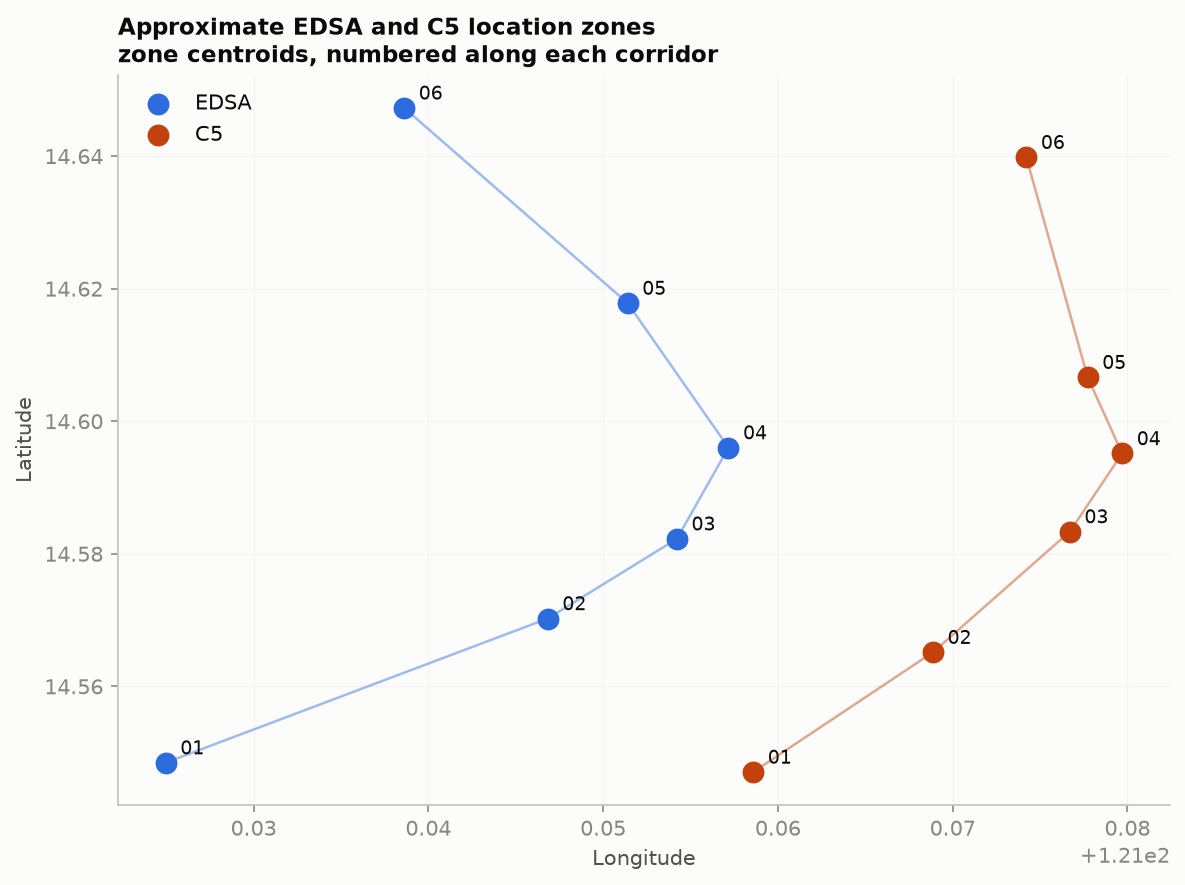

In [25]:
# STEP 8.9A — PLOT APPROXIMATE SPATIAL ZONES

fig, ax = plt.subplots(figsize=(8, 6))

# EDSA blue, C5 orange — the same assignment as every other figure in this
# project and the slide deck. groupby() would otherwise colour them by
# alphabetical order, which puts C5 in EDSA's colour.
CORRIDOR_COLOUR = {"EDSA": "#2d6cdf", "C5": "#c2410c"}

for road in ("EDSA", "C5"):

    group = ZONES[ZONES["road"].eq(road)]

    ax.scatter(
        group["longitude"],
        group["latitude"],
        label=road,
        color=CORRIDOR_COLOUR[road],
        s=90,
        zorder=3
    )

    # Join the zone centroids so the corridor's shape is visible rather than
    # implied by loose dots.
    ax.plot(
        group["longitude"],
        group["latitude"],
        color=CORRIDOR_COLOUR[road],
        lw=1.2,
        alpha=0.45,
        zorder=2
    )

    for _, row in group.iterrows():

        ax.annotate(
            row["zone"].split("_")[-1],
            (
                row["longitude"],
                row["latitude"]
            ),
            xytext=(7, 4),
            textcoords="offset points",
            fontsize=9
        )

ax.set_title(
    "Approximate EDSA and C5 location zones\n"
    "zone centroids, numbered along each corridor",
    loc="left", fontsize=11
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(frameon=False)
ax.grid(alpha=0.25, lw=0.6)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

fig.savefig(
    cfg.FIGURES / "fig11_spatial_zones.png",
    dpi=150
)

plt.show()

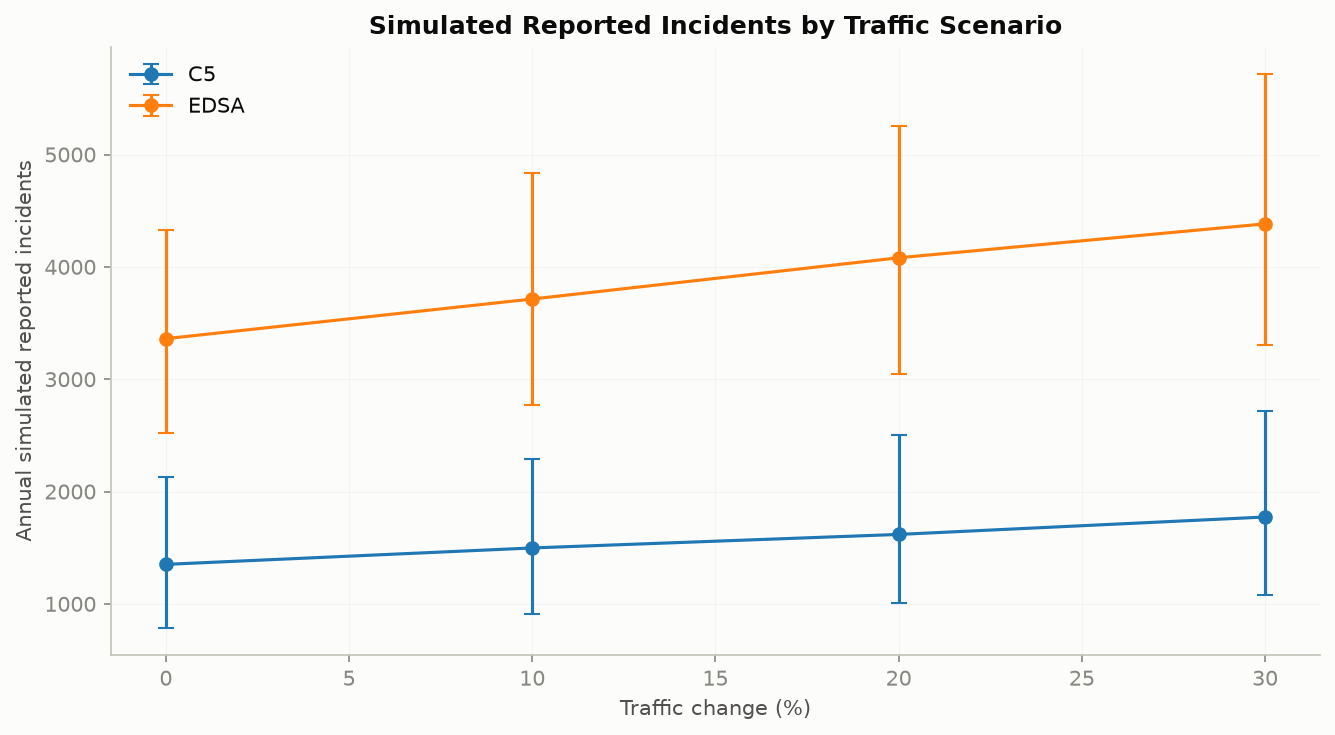

In [26]:
# STEP 8.9B — COMPARE SIMULATED TRAFFIC SCENARIOS

scenario_plot = EVENT_SUMMARY[
    EVENT_SUMMARY["elasticity"].eq(1.0)
].copy()

fig, ax = plt.subplots(figsize=(9, 5))

for road, group in scenario_plot.groupby("corridor"):

    group = group.sort_values(
        "traffic_change"
    )

    ax.errorbar(
        group["traffic_change"] * 100,
        group["mean"],
        yerr=[
            group["mean"] - group["p05"],
            group["p95"] - group["mean"]
        ],
        marker="o",
        capsize=4,
        label=road
    )

ax.set_title(
    "Simulated Reported Incidents by Traffic Scenario"
)

ax.set_xlabel("Traffic change (%)")

ax.set_ylabel(
    "Annual simulated reported incidents"
)

ax.legend(frameon=False)
ax.grid(alpha=0.25, lw=0.6)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

fig.savefig(
    cfg.FIGURES / "fig12_event_scenarios.png",
    dpi=150
)

plt.show()

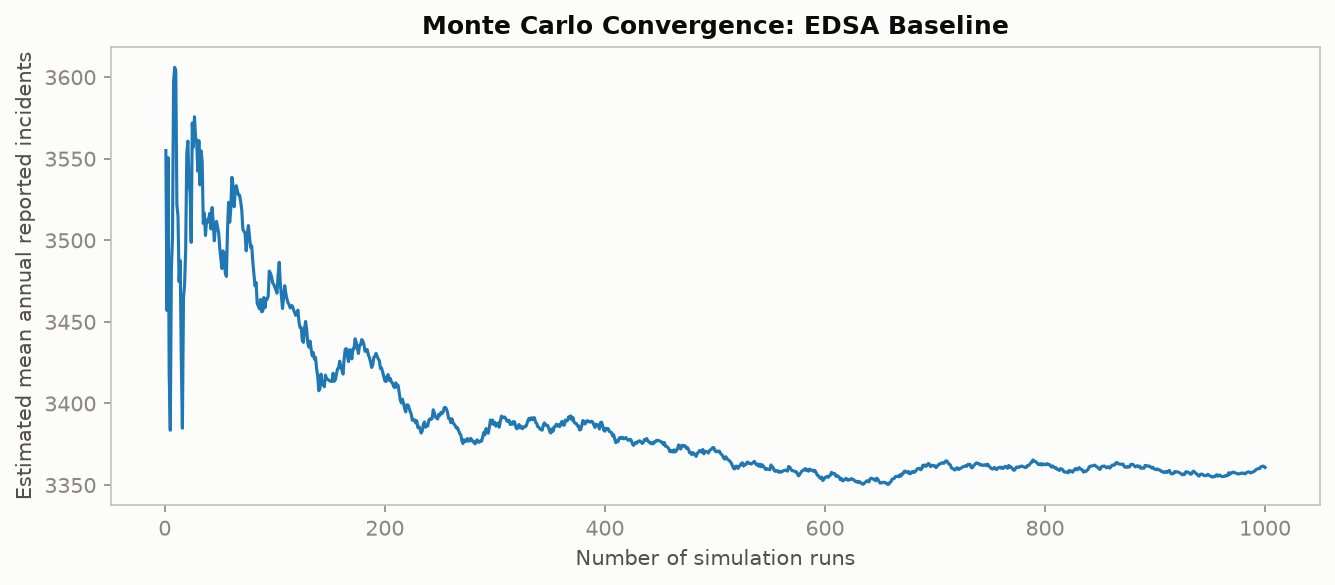

Mean after    10 runs: 3,603.7
Mean after    50 runs: 3,495.0
Mean after   100 runs: 3,471.4
Mean after   250 runs: 3,392.6
Mean after   500 runs: 3,371.1
Mean after 1,000 runs: 3,360.8
Mean after 1,000 runs: 3,360.8   <- final

The estimate moved 0.29% over the second half of the runs, which is
what convergence looks like: more runs would not change the answer materially.


In [27]:
# STEP 8.9C — MONTE CARLO CONVERGENCE

baseline_name = next(
    name
    for name, change in cfg.SCENARIOS.items()
    if change == 0
)

counts = MONTHLY_SIMULATIONS[
    ("EDSA", baseline_name, 1.0)
]

annual_totals = counts.sum(axis=1)

running_mean = (
    np.cumsum(annual_totals)
    / np.arange(1, len(annual_totals) + 1)
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    np.arange(1, EVENT_RUNS + 1),
    running_mean
)

ax.set_title(
    "Monte Carlo Convergence: EDSA Baseline"
)

ax.set_xlabel("Number of simulation runs")

ax.set_ylabel(
    "Estimated mean annual reported incidents"
)

fig.tight_layout()

fig.savefig(
    cfg.FIGURES / "fig13_event_convergence.png",
    dpi=150
)

plt.show()

# Report at whatever checkpoints actually exist. Hardcoding 100/500/1000 makes
# this cell crash the moment anyone lowers EVENT_RUNS to iterate quickly.
for checkpoint in (10, 50, 100, 250, 500, 1000, 2500):
    if checkpoint <= len(running_mean):
        print(f"Mean after {checkpoint:>5,} runs: "
              f"{running_mean[checkpoint - 1]:,.1f}")

print(f"Mean after {len(running_mean):>5,} runs: "
      f"{running_mean[-1]:,.1f}   <- final")

_settled = abs(running_mean[-1] / running_mean[len(running_mean) // 2] - 1) * 100
print()
print(f"The estimate moved {_settled:.2f}% over the second half of the runs, "
      f"which is\nwhat convergence looks like: more runs would not change the "
      f"answer materially.")

### Step 8.10 — Review the results

The final tables show the scenario results and examples of individual simulated incidents.

The simulation now generates incident counts, assigns times and approximate locations, and compares outcomes across traffic-volume scenarios.

The next research tasks are to replace approximate location zones with mapped road segments, test the generated spatial and temporal patterns against historical observations, and obtain additional data if hourly traffic risk or violation effects are to be estimated.

In [28]:
# STEP 8.10 — DISPLAY FINAL RESULTS

print("SCENARIO RESULTS")

display(
    EVENT_SUMMARY[
        [
            "corridor",
            "scenario",
            "elasticity",
            "mean",
            "p05",
            "p95",
            "mean_rate_per_100k"
        ]
    ]
)

print("\nSAMPLE SIMULATED EVENTS")

display(
    SAMPLE_EVENTS.head(20)
)

print("\nSIMULATED EVENTS BY ZONE AND HOUR")

display(
    EVENT_ALLOCATION.head(20)
)

print("\nOutput files:")

for filename in (
    "event_scenario_summary.csv",
    "event_zone_hour_summary.csv",
    "sample_simulated_events.csv"
):
    print(cfg.TABLES / filename)

SCENARIO RESULTS


,corridor,scenario,elasticity,mean,p05,p95,mean_rate_per_100k
0,EDSA,baseline,0.8,3377.300,2554.55,4395.45,2.194039
1,EDSA,plus_10,0.8,3626.105,2715.70,4698.25,2.141521
2,EDSA,plus_20,0.8,3891.786,2930.50,5040.15,2.106893
3,EDSA,plus_30,0.8,4172.748,3131.20,5371.60,2.085228
4,EDSA,baseline,1.0,3360.775,2522.95,4331.60,2.183304
5,EDSA,plus_10,1.0,3713.657,2772.85,4838.05,2.193228
6,EDSA,plus_20,1.0,4080.685,3048.10,5257.65,2.209157
7,EDSA,plus_30,1.0,4382.676,3306.65,5715.10,2.190134
8,EDSA,baseline,1.2,3402.314,2524.50,4350.30,2.210289
9,EDSA,plus_10,1.2,3792.379,2853.80,4931.20,2.239720



SAMPLE SIMULATED EVENTS


,run,scenario,elasticity,road,year,month,day,hour,minute,zone,event_type
0,1,baseline,0.8,EDSA,2025,1,14,00,53,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
1,1,baseline,0.8,EDSA,2025,1,31,04,54,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
2,1,baseline,0.8,EDSA,2025,1,2,04,2,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
3,1,baseline,0.8,EDSA,2025,1,11,04,25,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
4,1,baseline,0.8,EDSA,2025,1,29,05,28,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
5,1,baseline,0.8,EDSA,2025,1,31,06,16,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
6,1,baseline,0.8,EDSA,2025,1,4,07,15,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
7,1,baseline,0.8,EDSA,2025,1,23,07,14,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
8,1,baseline,0.8,EDSA,2025,1,21,07,53,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH
9,1,baseline,0.8,EDSA,2025,1,15,07,54,EDSA_ZONE_01,SIMULATED_REPORTED_CRASH



SIMULATED EVENTS BY ZONE AND HOUR


,corridor,scenario,elasticity,zone,hour,mean_annual_events
0,EDSA,baseline,0.8,EDSA_ZONE_01,00,11.378
1,EDSA,baseline,0.8,EDSA_ZONE_01,01,6.198
2,EDSA,baseline,0.8,EDSA_ZONE_01,02,1.226
3,EDSA,baseline,0.8,EDSA_ZONE_01,03,1.230
4,EDSA,baseline,0.8,EDSA_ZONE_01,04,8.136
5,EDSA,baseline,0.8,EDSA_ZONE_01,05,17.887
6,EDSA,baseline,0.8,EDSA_ZONE_01,06,22.302
7,EDSA,baseline,0.8,EDSA_ZONE_01,07,31.153
8,EDSA,baseline,0.8,EDSA_ZONE_01,08,42.456
9,EDSA,baseline,0.8,EDSA_ZONE_01,09,38.164



Output files:
C:\Users\mearv\Documents\CSS142\results\tables\event_scenario_summary.csv
C:\Users\mearv\Documents\CSS142\results\tables\event_zone_hour_summary.csv
C:\Users\mearv\Documents\CSS142\results\tables\sample_simulated_events.csv


## Step 9 — What was produced

Every figure, table and narrative log is under `results/`. On Colab the folder lives on a temporary runtime, so this cell also offers it as a download; run locally it only reports, and writes nothing extra into the project.

In [29]:
for sub in ('figures', 'tables', 'logs', 'processed'):
    files_ = sorted((cfg.RESULTS / sub).glob('*'))
    print(f'results/{sub}/  ({len(files_)} files)')
    for p in files_:
        print(f'    {p.name:<38} {p.stat().st_size:>9,} bytes')
    print()

# Only on Colab, and written outside the project so no stray archive is left
# sitting in the folder next to the notebook.
if IN_COLAB:
    import shutil
    from google.colab import files
    archive = shutil.make_archive('/tmp/traffic_results', 'zip', str(cfg.RESULTS))
    files.download(archive)


results/figures/  (13 files)
    fig01_exposure_trend.png                  83,351 bytes
    fig02_reclassification.png                99,342 bytes
    fig03_motorcycle_share.png                73,537 bytes
    fig04_coverage_audit.png                  46,939 bytes
    fig05_corridor_monthly.png               105,468 bytes
    fig06_rate_comparison.png                 55,631 bytes
    fig07_hourly_profile.png                  37,818 bytes
    fig08_scenarios.png                       68,686 bytes
    fig09_elasticity_sweep.png               118,026 bytes
    fig10_psa_crosscheck.png                  70,725 bytes
    fig11_spatial_zones.png                   75,746 bytes
    fig12_event_scenarios.png                 47,544 bytes
    fig13_event_convergence.png               64,044 bytes

results/tables/  (9 files)
    event_scenario_summary.csv                 2,462 bytes
    event_vs_count_comparison.csv                463 bytes
    event_zone_hour_summary.csv              134,769 bytes

---

## Appendix — rebuilding `data/` from the original downloads

**Do not run this unless `data/` is missing or you are starting from fresh downloads.** It does nothing harmful if run anyway, but it is not part of the pipeline.

The sources publish these datasets under names the pipeline does not expect, and the PSA figures arrive as a spreadsheet that needs parsing rather than renaming. Doing that by hand is not reproducible, so it is written down here.

Put every original download — zips, spreadsheets, oddly-named CSVs — in a folder and point `SOURCE` at it. Files are matched **by their columns, not their filenames**, so a renamed download still works and a file with the wrong schema is rejected rather than quietly accepted.

In [30]:
import io, zipfile

SOURCE = PROJECT_DIR / 'downloads'   # <- point this at your downloads folder

AADT_COLS      = {'Year','Code','Road','CAR','PUJ','PUB','TRUCK','MC','TOTAL'}
INCIDENT_COLS  = {'Date','Time','Location','Latitude','Longitude','Type'}
VIOLATION_COLS = {'Code','Description'}

def _iter_csvs(folder):
    """Yield (label, DataFrame, bytes) for every CSV, loose or inside a zip."""
    for p in sorted(folder.iterdir()):
        if p.suffix.lower() == '.csv':
            try: yield p.name, pd.read_csv(p), p.read_bytes()
            except Exception: pass
        elif p.suffix.lower() == '.zip':
            try:
                with zipfile.ZipFile(p) as z:
                    for m in sorted(z.namelist()):
                        if not m.lower().endswith('.csv'): continue
                        b = z.read(m)
                        try: yield f'{p.name}:{m}', pd.read_csv(io.BytesIO(b)), b
                        except Exception: pass
            except zipfile.BadZipFile: pass

def _parse_psa(path):
    """Find the crash table by shape: a row of consecutive years, labelled
    numeric rows beneath it. Locating it this way means a workbook with extra
    rows above still parses."""
    import openpyxl
    wb = openpyxl.load_workbook(path, data_only=True)
    for ws in wb.worksheets:
        rows = list(ws.iter_rows(values_only=True))
        for i, row in enumerate(rows):
            years, c0 = [], None
            for j, v in enumerate(row):
                if isinstance(v,(int,float)) and v and 2000 < v < 2030:
                    if c0 is None: c0 = j
                    years.append(int(v))
            if len(years) < 5: continue
            block = {}
            for r in rows[i+1:i+8]:
                label = next((str(c).strip() for c in r[:c0]
                              if isinstance(c,str) and str(c).strip()), None)
                if not label: continue
                vals = [c for c in r[c0:c0+len(years)] if isinstance(c,(int,float))]
                if len(vals) == len(years): block[label] = [int(v) for v in vals]
            if 'Total' in block:
                out = pd.DataFrame({'Year': years})
                rn = {'Total':'Total','Fatal':'Fatal',
                      'Non Fatal Injury':'NonFatalInjury',
                      'Damage to Property':'DamageToProperty'}
                for k,v in block.items(): out[rn.get(k, k.replace(' ',''))] = v
                return out
    return None

def rebuild_data(source=SOURCE, dest=PROJECT_DIR / 'data'):
    source, dest = Path(source), Path(dest)
    assert source.exists(), f'No such folder: {source}'
    dest.mkdir(parents=True, exist_ok=True)
    parts = []
    for label, df, data in _iter_csvs(source):
        cols = set(str(c).strip().lstrip('\ufeff') for c in df.columns)
        yrs  = {c for c in cols if c.isdigit() and 2000 < int(c) < 2030}
        if AADT_COLS.issubset(set(df.columns)):
            if df['Year'].nunique() > 3:
                (dest/'AADT_2014_2025_combined.csv').write_bytes(data)
                print(f'  AADT       <- {label} ({len(df)} rows)')
            else:
                parts.append(df)
        elif INCIDENT_COLS.issubset(set(df.columns)):
            (dest/'mmda_incidents.csv').write_bytes(data)
            print(f'  incidents  <- {label} ({len(df):,} rows)')
        elif VIOLATION_COLS.issubset(cols) and len(yrs) >= 3:
            (dest/'edsa_violations.csv').write_bytes(data)
            print(f'  violations <- {label} ({len(df)} rows)')
    if parts and not (dest/'AADT_2014_2025_combined.csv').exists():
        m = pd.concat(parts, ignore_index=True).sort_values(['Year','Code'])
        m.to_csv(dest/'AADT_2014_2025_combined.csv', index=False)
        print(f'  AADT       <- built from {len(parts)} per-year files')
    for p in sorted(source.iterdir()):
        if p.suffix.lower() in ('.xlsx','.xlsm'):
            psa = _parse_psa(p)
            if psa is not None and len(psa):
                psa.to_csv(dest/'psa_crashes.csv', index=False)
                print(f'  PSA        <- {p.name} ({len(psa)} years)')
                break
    still = [f for f in EXPECTED if not (dest/f).exists()]
    print('\nMissing after rebuild:', still if still else 'nothing')
    return not still

print('rebuild_data() is defined. Call it only if data/ needs rebuilding.')


rebuild_data() is defined. Call it only if data/ needs rebuilding.


---

### What a panel will ask

**"Why only 18 months of a two-and-a-half-year file?"** See the coverage audit in Step 4. Two months hold zero records and four more are lockdown-distorted.

**"Isn't the MMDA feed biased toward EDSA?"** Yes, heavily — which is why every comparison is a rate rather than a count, and why the EDSA:C5 ratio test exists.

**"Where does the elasticity come from?"** It doesn't. It is swept as a scenario parameter rather than estimated, because six exposure levels entangled with a time trend cannot identify it.

**"Why Negative Binomial?"** It is not assumed. Poisson is fitted first, the dispersion statistic is measured, and the family is chosen on that evidence.

**"How do you know the data is reliable?"** Partly we do not, which is why the pipeline audits it. Eleven structural defects are documented across the two primary datasets, each one handled in code.